# [이론] GLM — 직선 밖의 결과를 담는다

_이 노트북은 LMS에서 내보냈습니다. 영상·퀴즈는 학습 참고용으로 마크다운으로 변환되었습니다._

## 오늘 배울 것

<div style="background:#FFFFFF;color:#000000;padding:40px;border-radius:12px;border:1px solid #E6E6E6;border-left:4px solid #051C2C">
<div style="font-size:0.9em;color:#656565">AI 데이터 인텔리전스 전문가 과정 · 모형추정과 심화통계</div>
<h1 style="color:#000000;margin:10px 0">GLM — 분포와 링크함수를 바꾼 회귀, 계수의 해석</h1>
<div style="font-size:1.05em;color:#656565">정규분포와 직선으로는 맞지 않는 결과에, 분포와 링크함수를 바꿔 회귀를 맞추는 법</div>
</div>

## 오늘 배울 것

**여기서 할 일**

1. 어제 구한 사고율 값 하나를 계약마다 다르게 만드는 질문을 꺼냅니다.
2. 데이터 분포 그림 3개에서 최소제곱이 맞지 않는 곳 3군데를 확인합니다.
3. 오늘 만들 모형의 기본 식과 배우는 순서를 봅니다.

어제 우리는 계약 678,013건의 연간 사고율을 **0.1006건/년**이라는 값 하나로 구했습니다. 그런데 같은 **세그먼트**(지역·차량 브랜드 같은 조건의 조합 하나, 그리고 그 조합에 속한 계약 n건) 안에도 20세 초보 운전자와 50세 무사고 운전자가 함께 들어 있어, 요율표를 만들기에는 부족합니다.

> **"계약 한 건 한 건의 특성에 맞춰, 그 계약의 사고율을 따로 매길 수는 없을까?"**

특성에서 결과를 예측하는 방법은 이미 알고 있습니다. 회귀입니다. 그런데 이 데이터에 그대로 쓰면 틀린 값이 나옵니다. 오늘은 어디서 틀리는지 확인하고 회귀의 구성요소(분포·링크함수)를 바꿔 해결합니다. 그렇게 넓힌 회귀가 **일반화선형모형(GLM)** 입니다.

아래 그림 3개는 모두 히스토그램입니다. 가로축을 일정한 간격으로 나눈 한 부분을 **구간(bin)** 이라 부르고, 막대 높이는 그 구간에 든 계약 수입니다.

<img src="https://scikit-learn.org/stable/_images/sphx_glr_plot_poisson_regression_non_normal_loss_001.png" width="960" height="240"/>
<p align="center"><em>▲ 그림 1(왼쪽)·그림 2(가운데)·그림 3(오른쪽) — 같은 데이터(freMTPL2freq)를 변수 3개로 나눠 그린 분포다. 세로축이 3개 모두 로그 눈금인데도 그림 1(사고 건수)과 그림 3(사고 빈도)은 0 쪽 첫 구간에 쏠려 있고, 그림 2(노출 기간)만 0～1년에 고르게 깔린다 (출처: scikit-learn documentation)</em></p>

그림 1·그림 2·그림 3 이 오늘 다룰 문제 3개와 하나씩 짝을 이룹니다.

1. **타깃이 건수 데이터입니다.** 타깃(target)은 모형이 맞히려는 결과값이고, 오늘의 타깃은 0, 1, 2, …로 집계되는 사고 건수(count)입니다. 그림 1은 세로축이 로그 눈금인데도 0건 막대가 643,953건으로 가장 높습니다.
2. **관찰 기간이 계약마다 다릅니다.** 그림 2가 어제 **노출**이라 부른 그 기간입니다. 0～1년이 거의 평평하고, 평균은 0.53년입니다.
3. **값이 흩어진 모양이 정규분포와 다릅니다.** 그림 3은 사고 건수를 노출 $E$ 로 나눈 연 환산 값인데, 여기도 0 쪽 첫 구간에 쏠려 있습니다.

사고가 한 건이라도 난 계약은 678,013건 중 34,060건뿐입니다. 2개월만 관찰한 계약에서 사고가 1회 발생하면 연 6건으로 환산되는데, 나누는 기간이 계약마다 다르다는 이 사실은 「4. 포아송 회귀와 노출 보정」에서 오프셋으로 다룹니다.

위에 적은 막대 높이와 노출 통계는 아래 코드가 직접 집계하는 값입니다.

In [ ]:
# 위 그림 3개의 막대 높이를 데이터에서 직접 집계한다
from sklearn.datasets import fetch_openml

insurance = fetch_openml(data_id=41214, as_frame=True).frame   # 계약 678,013건 — 원자료 그대로
claims = insurance["ClaimNb"].astype(int)      # 그림 1이 집계한 값 — 계약별 사고 건수
exposure = insurance["Exposure"]               # 그림 2가 집계한 값 — 노출(관찰 기간, 년)

print(claims.value_counts().head(4))           # 0건 643953 · 1건 32178 · 2건 1784 · 3건 82
print(int((claims >= 4).sum()))                # 16 — 4건 이상 막대를 모두 합친 계약 수
print(int((exposure == 1).sum()))              # 168125 — 노출이 딱 1년인 계약
print(round(exposure.mean(), 2))               # 0.53 — 노출 평균(년)
print(round((exposure <= 1).mean() * 100, 1))  # 99.8 — 노출이 1년 이하인 계약의 비율(%)
# 뒤에서는 여기에 표준 전처리를 더해 쓴다 — ClaimNb 상한 4 · Exposure 상한 1.0 ·
# Area·VehBrand·VehGas·Region 은 따옴표를 제거해 범주형으로(그래야 3. 로지스틱 회귀 코드의 VehGas[T.Regular] 이름이 맞는다)

오늘 만들 모형이 계약 한 건을 어떻게 계산하는지부터 한 장으로 보겠습니다. 계약의 특성에서 시작해 관측된 사고까지 단계 5개를 차례로 지나는 순서입니다.

그림에 나오는 기호 3개의 이름과 뜻은 그림 아래 표에 정리했습니다.

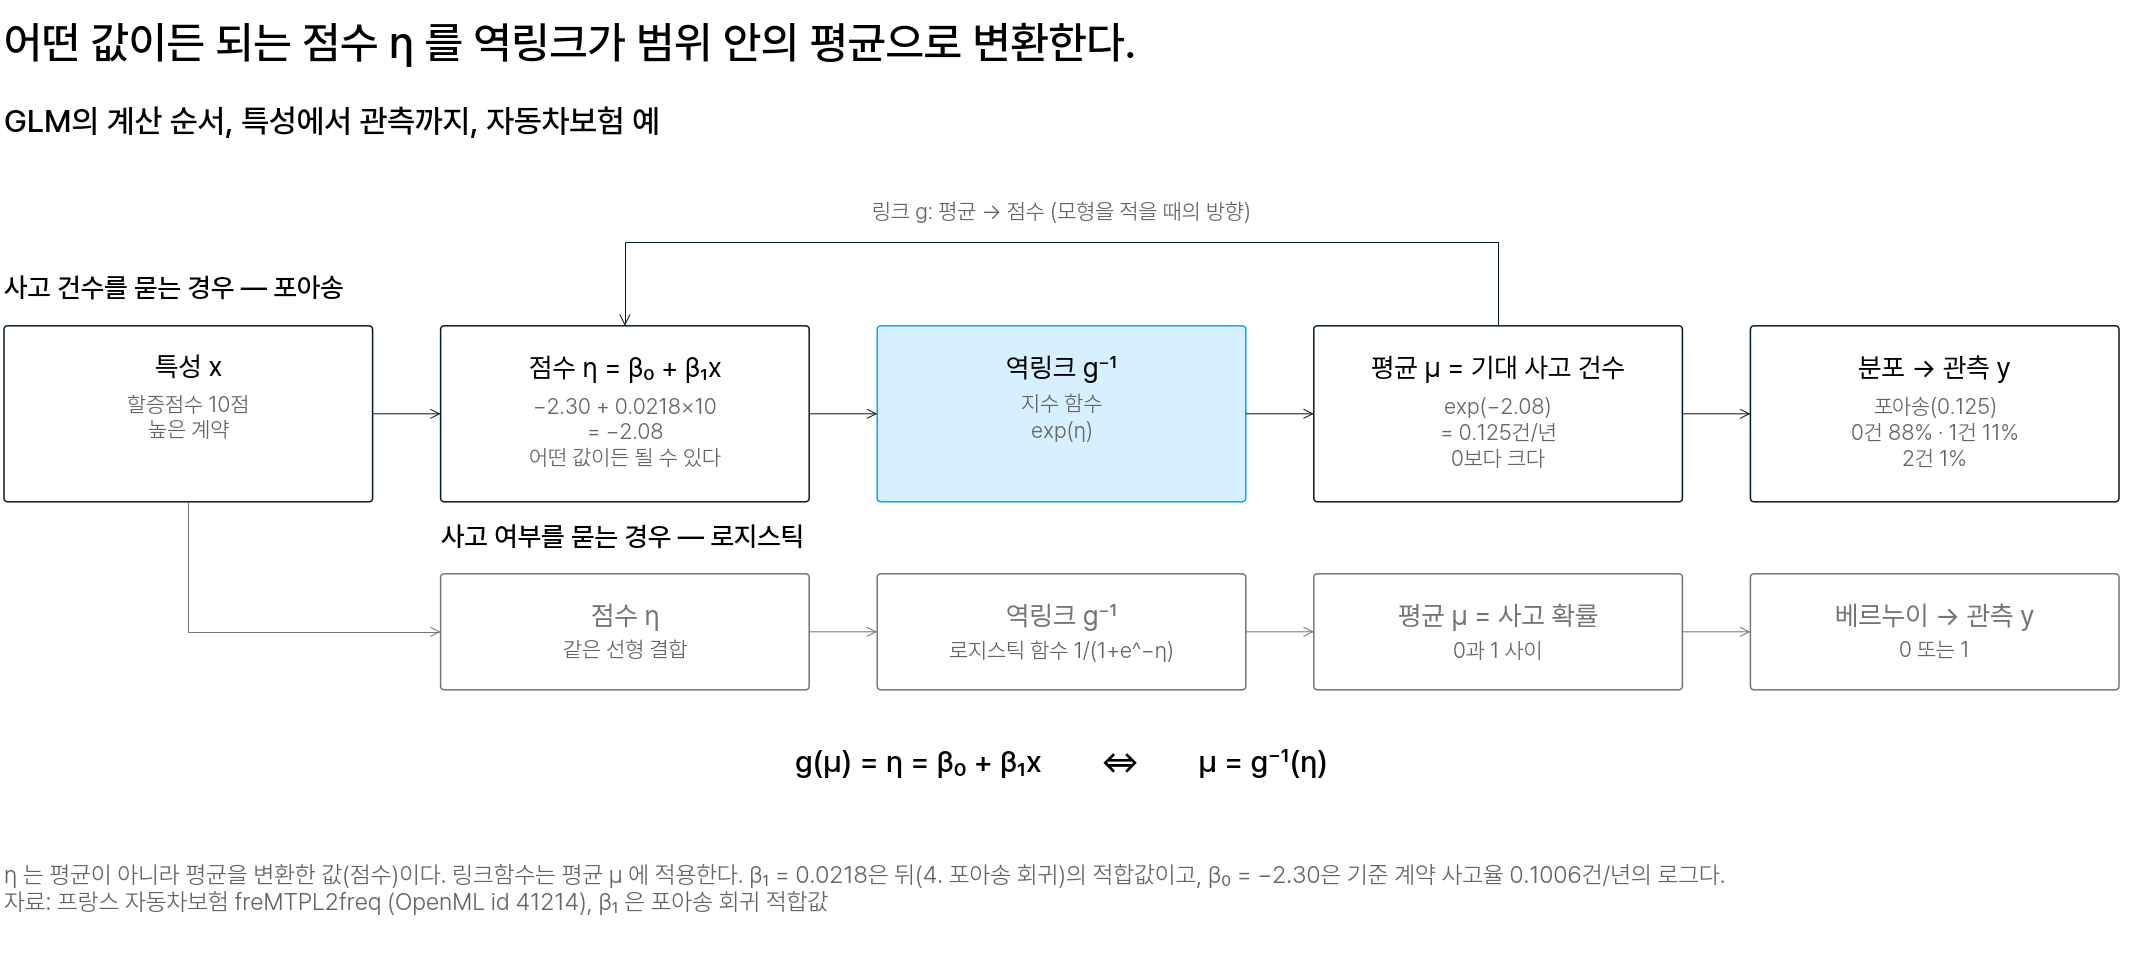

In [ ]:
# 도해 생성 코드는 LMS 에서만 실행됩니다

<p align="center"><em>▲ GLM 의 계산 순서 — 특성 x 에 계수를 곱해 더한 점수 η 를 역링크 g⁻¹ 가 평균 μ 로 변환하고, 그 평균으로 정해진 분포를 관측 y 가 따른다. 남색으로 그린 「사고 건수를 묻는 경우 — 포아송」과 회색으로 그린 「사고 여부를 묻는 경우 — 로지스틱」은 역링크와 분포 2개만 다르다. 위로 돌아가는 화살표는 반대 방향인 링크 g 다</em></p>

그림의 기호 3개를 먼저 정의합니다.

| 기호 | 한 문장 정의 | 값의 범위 |
|---|---|---|
| **평균 $\mu$** (뮤) | 그 계약에서 기대되는 결과 — 사고가 날 확률이거나 한 해 기대 사고 건수 | 확률이면 0 과 1 사이, 건수면 0 아래로 내려가지 않는다 |
| **점수 $\eta$** (에타) | 계약의 특성에 계수를 곱해 모두 더한 값 — 정식 이름은 선형예측자(linear predictor)다 | 어느 쪽으로든 얼마든지 커지고 작아진다 |
| **변환 $g$ · $g^{-1}$** | 링크 $g$ 는 평균을 점수 스케일로 옮기고, 역링크 $g^{-1}$ 는 점수를 평균의 범위로 역변환한다 | 평균의 범위가 다르면 적용하는 변환도 다르다 |

**핵심 주의점 — $\eta$ 는 평균이 아닙니다.** 그림 첫 행에서 점수 −2.08 과 평균 0.125건/년이 다른 상자에 적힌 것이 그 뜻입니다.

그림에 나온 **할증점수**(사고 이력에 따라 계약마다 매겨지는 지수)는 오늘 특성 $x$ 로 쓰는 변수입니다.

그림 아래 한 줄이 오늘 만들 모형의 기본 식입니다.

$$
g(\mu) = \eta = \beta_0 + \beta_1 x_1 + \cdots + \beta_p x_p
$$

- $x_1, \dots, x_p$ : 계약에서 읽어 온 특성 $p$ 개 — 나이·할증점수·차령
- $\beta_1, \dots, \beta_p$ : 그 특성이 1 오를 때 $\eta$ 가 커지는 양이고, $\beta_0$ 는 절편
- $g$ : 평균 $\mu$ 를 점수 $\eta$ 와 같은 스케일로 옮기는 링크함수(link function)

말로 하면 "평균을 변환한 값이 특성에 계수를 곱해 더한 값과 같다" 이고, 예측할 때는 반대 방향으로 $\mu = g^{-1}(\eta)$ 를 계산합니다.

이 식이 정하는 것은 평균 $\mu$ 까지라, GLM 은 이 식과 짝으로 "결과값 $y$ 는 어떤 분포를 따른다"는 문장을 함께 적습니다.

$$
y_i \sim \text{Poisson}(\mu_i), \qquad \log \mu_i = \eta_i
$$

물결표 $\sim$ 는 왼쪽 값이 오른쪽 분포를 따른다고 읽고, 아래 첨자 $i$ 는 계약 한 건 한 건을 뜻합니다. 말로 하면 "사고 건수 $y_i$ 는 평균이 $\mu_i$ 인 포아송 분포를 따른다" 입니다.

**왼쪽에 무엇을 두고 $g$ 에 무엇을 대입하느냐만 바꾸면 이 식 하나에서 로지스틱 회귀도 포아송 회귀도 나옵니다.**

## 오늘 배우는 순서

오늘은 다음 순서로 앞의 질문에 답합니다.

| 순서 | 다루는 질문 |
|---|---|
| 1. 최소제곱 회귀의 한계 | 최소제곱 직선을 이 데이터에 그으면 무엇이 맞지 않는가 |
| 2. GLM 의 구성요소 3개 | 그 회귀에서 무엇을 바꿔야 하는가 |
| 3. 로지스틱 회귀 — 오즈와 오즈비 | 0/1 결과에 이항 분포와 로짓 링크를 넣으면 계수가 무슨 뜻이 되는가 |
| 4. 포아송 회귀와 노출 보정 | 건수 데이터와, 계약마다 다른 관찰 기간은 어디에 넣는가 |
| 5. AIC 와 BIC | 후보 여럿 가운데 어느 모형을 고르는가 |
| 6. 실제 데이터 적용 | 계수 하나를 요율 문장으로 어떻게 옮기는가 |
| 7. 오늘의 정리와 수업에서 다룰 질문 | 오늘 배운 것을 한 장으로 줄이면 무엇이 남는가 |

앞 이틀에서 이어 쓰는 개념은 2개입니다. 첫날의 **우도 · 로그우도 · 최대우도추정**은 GLM 의 계수를 구하는 데 그대로 쓰이고, **표준오차**는 같은 조사를 다시 했을 때 추정값이 표본마다 얼마나 달라지는지를 나타내는 값입니다.

**그래서** 오늘의 결과는 사고율 숫자 하나가 아니라 계약마다 다른 값을 만들어 내는 **계수 표**입니다. 표를 만드는 데까지가 1～5번이고, 표의 숫자를 요율 문장으로 읽는 것이 6번입니다.

## 1. 최소제곱 회귀의 한계 — 0/1 결과와 건수 결과

## 최소제곱 회귀 — 직선 하나와 잔차 제곱합

직선 하나로는 확률을 그릴 수 없습니다. 확률은 0 과 1 사이에만 있는데 직선의 값에는 위아래 한계가 없기 때문입니다 — 할증점수가 아주 높은 계약의 사고 확률이 1.2 로 계산되는 일이 생깁니다.

회귀 모듈에서 쓰던 최소제곱(least squares) 회귀는 잔차 제곱합을 가장 작게 만드는 직선 하나였습니다. 그 직선을 0/1 결과와 건수 데이터에 그대로 쓰면 정확히 어디가 맞지 않습니까?

**여기서 할 일**

1. 0/1 결과에 최소제곱 직선을 대고 예측값이 0～1 밖으로 나가는 것을 봅니다.
2. 건수 데이터에 같은 직선을 대고 분산이 위치마다 달라지는 것을 확인합니다.
3. 최소제곱의 전제와 이 데이터의 실제를 항목 4개로 대조합니다.

그 방법은 **잔차(점과 직선 사이의 세로 거리)를 제곱해 더한 값**이 가장 작아지게 기울기와 절편을 고르는 것이었습니다.

<img src="https://en.wikipedia.org/wiki/Special:FilePath/Linear_regression.svg" width="640" height="422"/>
<p align="center"><em>▲ 일반적인 예시 — 최소제곱이 하는 일 — 가로축 −20～60, 세로축 0～16 에 무작위로 흩뿌린 예시 데이터 점 100개를, 왼쪽 아래에서 오른쪽 위로 오르는 빨간 직선 하나가 가로지른다 (출처: Wikipedia)</em></p>

<img src="https://en.wikipedia.org/wiki/Special:FilePath/Residuals_for_Linear_Regression_Fit.png" width="640" height="427"/>
<p align="center"><em>▲ 일반적인 예시 — 최소제곱이 최소로 만드는 것 — 점마다 빨간 직선까지 내린 검은 세로 선분이 잔차다. x = 1 위치의 선분이 10개 가운데 가장 긴데, 길이를 제곱하면 긴 선분이 훨씬 큰 가중치로 계산에 들어가니 추정값은 멀리 떨어진 점 하나에 크게 영향을 받는다 (출처: Wikipedia)</em></p>

그 직선에는 오차항 $\varepsilon_i \sim N(0, \sigma^2)$ 라는 조건이 함께 적히고, 여기에 가정이 2개 들어 있습니다.

- **범위** — 오차가 정규분포라 $y$ 가 어떤 실수든 될 수 있습니다
- **분산** — $\sigma^2$ 에 아래 첨자 $i$ 가 없어 어디서나 분산이 같습니다

그런데 계약 한 건의 결과는 0/1 이거나 0, 1, 2건입니다. 두 가정이 둘 다 맞지 않습니다.

<details class="lms-extra"><summary>자세히 — 최소제곱 식의 기호별 해석과 가정 2개의 구분</summary>

식을 생략 없이 적으면 이렇습니다.

$$
y_i = \beta_0 + \beta_1 x_{i1} + \cdots + \beta_p x_{ip} + \varepsilon_i, \qquad \varepsilon_i \sim N(0, \sigma^2)
$$

- $y_i$ : $i$ 번째 관측의 결과값 — 매출·키·온도처럼 어떤 실수든 될 수 있는 값
- $x_{i1}, \dots, x_{ip}$ : $i$ 번째 관측의 설명변수 $p$ 개 · $\beta_0, \dots, \beta_p$ : 절편과 기울기
- $\varepsilon_i$ : 오차 — 직선으로 설명되지 않고 남은 부분

맨 오른쪽 $\varepsilon_i \sim N(0, \sigma^2)$ 하나에 가정 2개가 함께 들어 있습니다. 정규분포는 $-\infty$ 에서 $+\infty$ 까지 값이 있으니 $y$ 도 어떤 실수든 될 수 있는 값이 되고(사고 건수 $-3.7$ 건이 계산 안에서는 문제 없는 값이 됩니다), $\sigma^2$ 에 아래 첨자 $i$ 가 붙어 있지 않으니 사고 확률이 0.05 인 계약과 0.5 인 계약에 같은 분산을 적용합니다.

두 가정이 함께 붙어 있는 이유는, 최소제곱이 잔차를 제곱해 더할 때 위치마다 실제 분산 $\sigma_i^2$ 가 다른데도 모든 점에 같은 가중치를 적용하기 때문입니다.

</details>

## 0/1 결과에 맞춘 최소제곱 직선 — 범위 이탈

사고 여부를 $y \in \{0, 1\}$ 로 두고 직선을 맞춥니다.

> **[예측] 0과 1로만 기록된 데이터에 최소제곱 직선을 맞춘 뒤 x를 계속 키우면 예측값은 어떻게 됩니까?**
>
> 1. 1에서 저절로 멈춘다
> 2. 1을 넘어 계속 올라간다
> 3. 0.5 근처에서 진동한다
>
> 답을 정한 뒤 아래를 읽어 보세요(정답 채점은 없습니다).

<img src="https://bookdown.org/roback/bookdown-BeyondMLR/bookdown-BeyondMLR_files/figure-html/OLSlogistic-1.png" width="640" height="457"/>
<p align="center"><em>▲ 일반적인 예시 — 그림 1 — 0/1 데이터에 맞춘 최소제곱 직선(실선)과 로지스틱 곡선(점선) — 실선이 x = −4 근처에서 0 아래로, x = 7 위에서 1 위로 벗어난다 — 직선은 확률로 읽을 수 없는 값까지 낸다 (출처: Roback & Legler, Beyond MLR)</em></p>

예측 질문의 답은 두 번째, 1을 넘어 계속 올라간다입니다 — **확률이 −0.05 나 1.2 로 나온다는 뜻**입니다. 그림 1의 점선이 같은 데이터에 맞춘 로지스틱 곡선이고, 오늘 만들 모형이 그 곡선입니다.

맞지 않는 것은 예측값의 위치만이 아닙니다. 값들이 평균에서 얼마나 떨어져 있는지를 뜻하는 **산포**도 함께 어긋납니다. 산포를 측정하는 용어 2개부터 구분해 둡니다.

- **분산(variance)** $\operatorname{Var}(y)$ — 평균에서 떨어진 거리를 제곱해 평균 낸 값이라 **단위도 제곱입니다**.
- **표준편차(SD)** $\operatorname{SD}(y)$ — 분산에 제곱근을 씌워 **원래 단위로 복원한 값입니다**.

0/1 값의 분산은 확률 $p$ 에 딸려 정해집니다.

$$
\operatorname{Var}(y) = p(1 - p)
$$

- $y$ : 사고가 났으면 1, 안 났으면 0 · $p$ : 사고 확률 — 0/1 결과에서는 이 값이 곧 평균입니다

여기서 나오는 비율 3개의 정의는 다음과 같습니다.

- **0.0502** — 사고를 한 번이라도 겪은 계약 수 ÷ 계약 수 · 단위 없음
- **0.0532** — 사고 건수 합 ÷ 계약 수 · 건/계약
- **0.1006** — 사고 건수 합 ÷ 노출 합 · 건/년(어제 구한 값)

사고 경험률 0.0502 를 넣으면 분산은 $0.0502 \times 0.9498 = 0.0477$, 표준편차는 $\sqrt{0.0477} = 0.218$ 입니다.

<details class="lms-extra"><summary>자세히 — 0/1 결과의 분산이 p(1−p) 인 이유</summary>

결과가 0 아니면 1 뿐이라 정의만 따라가면 몇 단계로 끝납니다.

**⑴ 먼저 평균입니다.** 기댓값은 「값 × 그 값이 나올 확률」을 모두 더한 것이라, 두 항을 더하면 0 을 곱한 항이 사라집니다. **0/1 결과에서는 평균이 곧 확률**이라는 말이 여기서 나옵니다.

$$
E[y] = 1 \times p + 0 \times (1 - p) = p
$$

**⑵ 분산의 정의식을 적고 $E[y^2]$ 을 구합니다.** $y$ 가 0 아니면 1 이라 제곱해도 값이 그대로여서 $E[y^2] = p$ 입니다.

$$
\operatorname{Var}(y) = E[y^2] - \left(E[y]\right)^2 = p - p^2
$$

**⑶ 공통인 $p$ 를 묶어 냅니다.** $p - p^2 = p \times 1 - p \times p$ 이기 때문입니다.

$$
p - p^2 = p(1 - p)
$$

**⑷ 숫자로 검산합니다.** $p = 0.0502$ 면 왼쪽이 $0.0502 - 0.00252 = 0.0477$, 오른쪽이 $0.0502 \times 0.9498 = 0.0477$ 로 같습니다.

**⑸ 그래서 무엇이 달라졌는가.** $p$ 를 정하는 순간 $p(1-p)$ 는 계산으로 따라 나오고, 최소제곱처럼 $\sigma^2$ 을 따로 고를 여지가 없습니다. $p - p^2$ 을 $p$ 로 미분하면 $1 - 2p$ 이고 이것이 0 이 되는 값이 $p = 0.5$ 라, 분산은 0.5 에서 가장 커집니다.

</details>

값 3개를 곡선 하나에 표시해 봅니다.

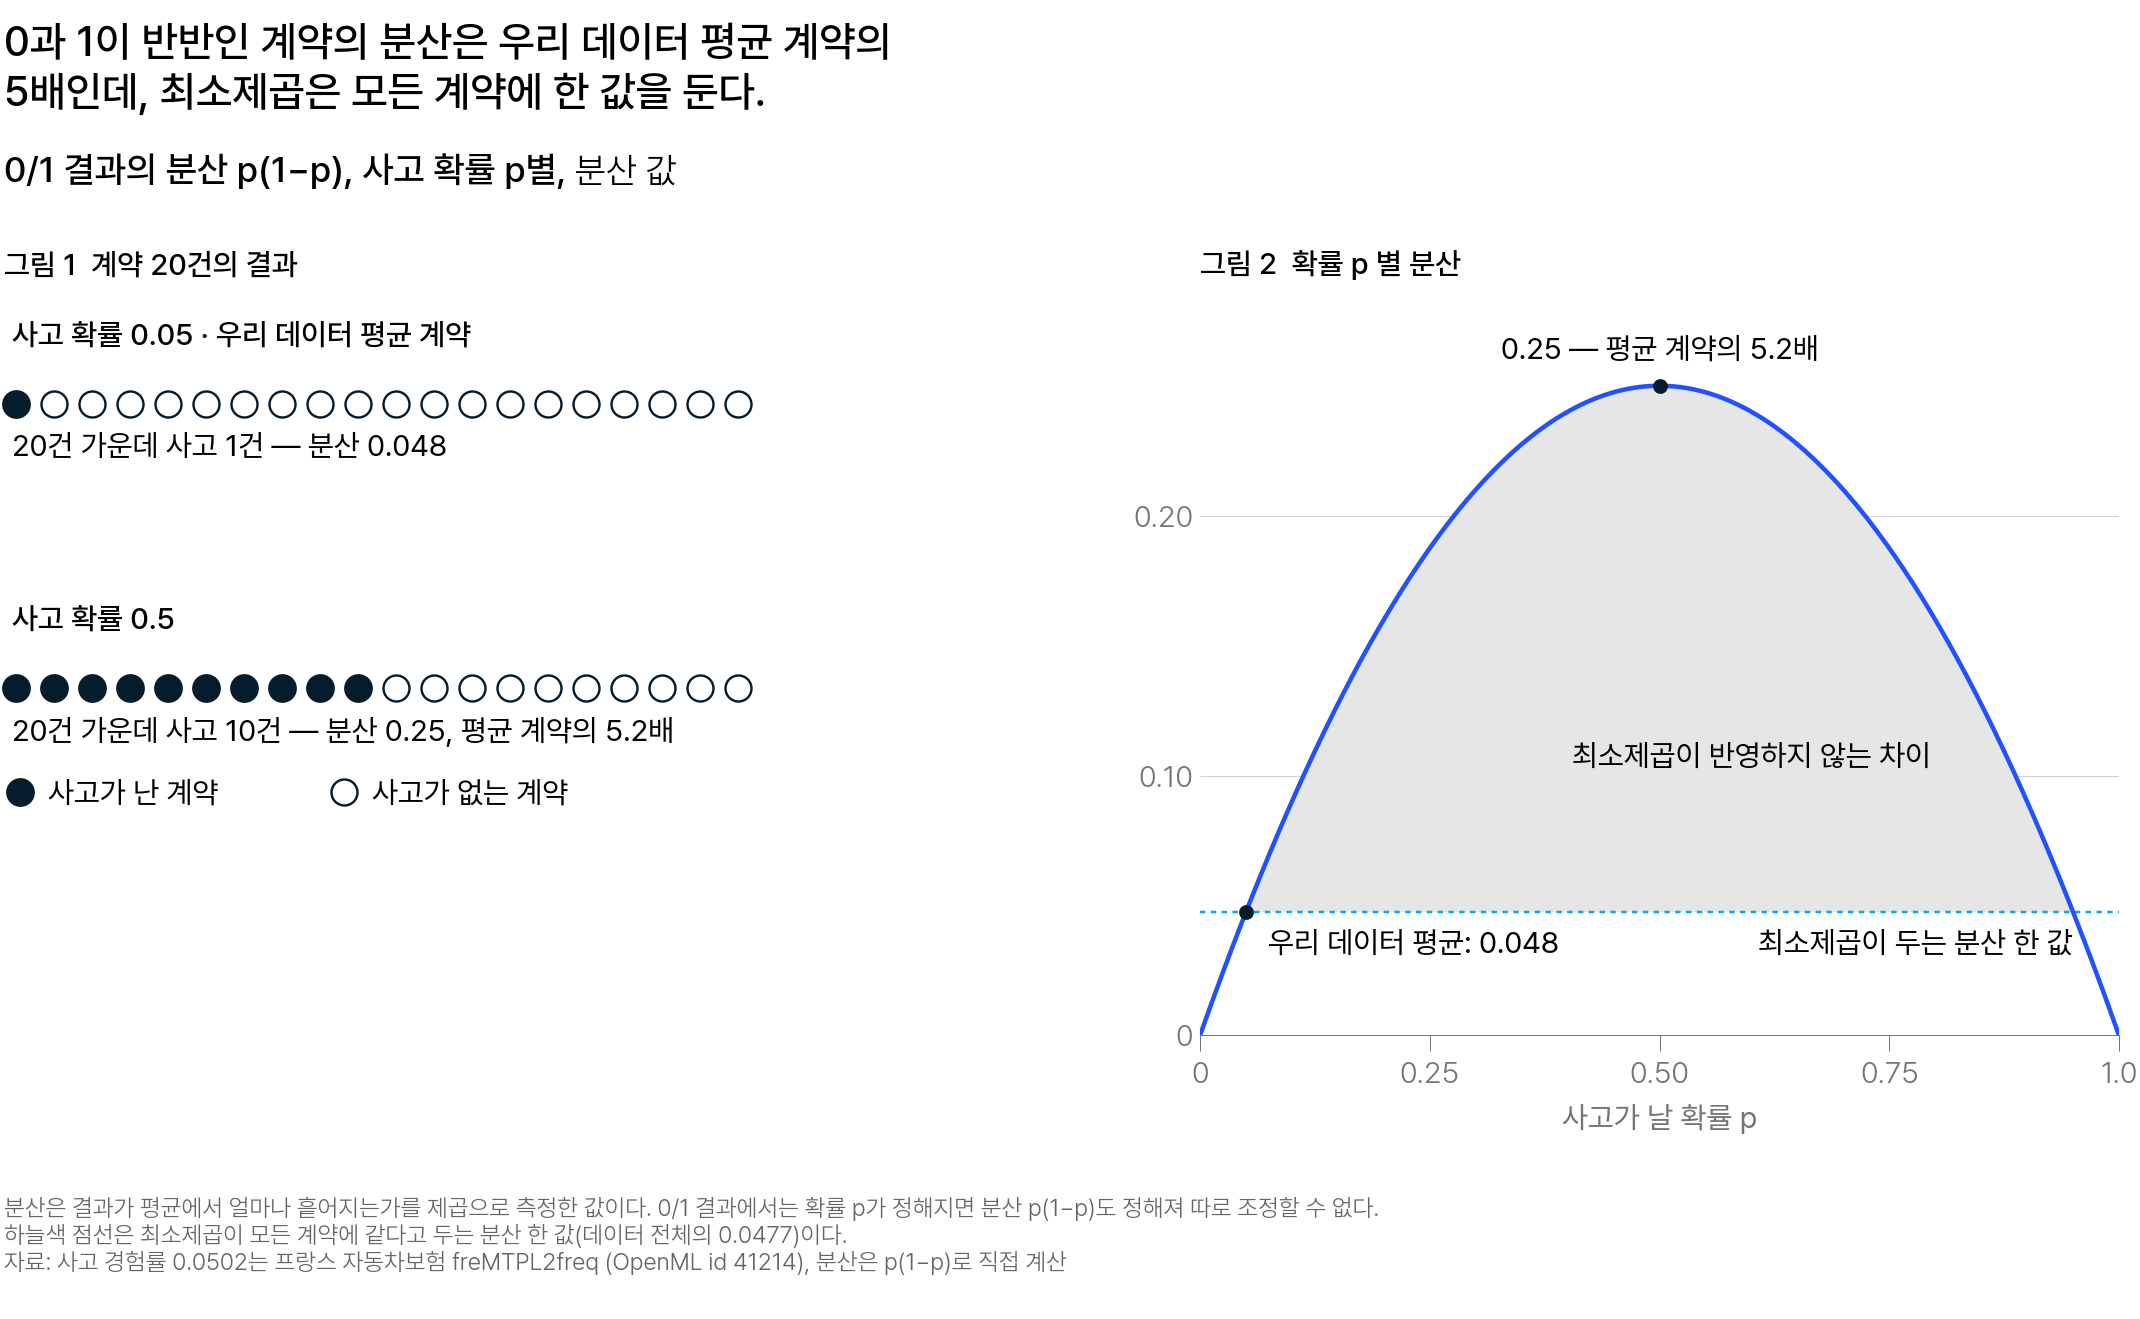

In [ ]:
# 도해 생성 코드는 LMS 에서만 실행됩니다

<p align="center"><em>▲ 0/1 결과의 분산 p(1−p) — 그림 1(왼쪽)은 계약 20건의 결과를 점으로 늘어놓은 두 줄이다. 사고 확률 0.05 인 계약은 20건 가운데 1건, 0.5 인 계약은 10건이 사고가 난 계약이고 분산은 0.048 과 0.25 다. 그림 2(오른쪽)는 확률 p 별 분산 곡선이고, 하늘색 점선이 최소제곱이 모든 계약에 같다고 두는 분산 한 값 0.0477 이다</em></p>

그림 1 의 두 줄을 비교해 보십시오. 사고 확률 0.05 인 계약은 20건 가운데 19건이 같은 결과(0)라 거의 정해져 있고, 0.5 인 계약은 어느 쪽인지 예측하기가 가장 어렵습니다.

그림 2 는 같은 관계를 확률 전체에 대해 그린 것입니다. 가로축에서 $p$ 를 정하면 세로축의 분산이 따라 정해져 조정할 모수가 없는데, 최소제곱은 분산을 어디서나 같은 $\sigma^2$ 하나로 둡니다 — 확률 0.5 인 계약과 0.05 인 계약에 **같은 가중치를** 적용한다는 뜻이고, 그러면 계수의 표준오차도 맞지 않습니다.

눈에 보이는 쪽부터 위젯으로 확인해 봅시다.

### [직접 해보기] 직선이 확률 0과 1을 벗어나는 구간

합격 여부 데이터(60명분)에 직선과 로지스틱 곡선을 번갈아 적용한 위젯입니다.

1. **해 보기.** 차트 위에서 `직선 모형` 과 `로지스틱 모형` 을 번갈아 눌러 보고, 슬라이더를 왼쪽 끝에서 오른쪽 끝까지 이동해 보세요(`로지스틱 모형` 을 고른 상태에서는 슬라이더 이름이 `S자 곡선의 기울기 β₁` 로 바뀝니다).
2. **관찰.** `직선 모형` 에서 기울기를 키우면 예측이 0 아래·1 위로 나간 x 구간이 `회색 면` 으로 칠해집니다. 차트 아래 `확률 범위를 벗어난 x 구간` 은 처음 위치에서 29.0% 인데, `로지스틱 모형` 으로 바꾸면 0.0% 가 됩니다(맨 위 제목은 직선 모형 기준으로 고정입니다).
3. **확인 질문.** `로지스틱 모형` 을 고른 상태에서 기울기를 최대로 키우면 회색 면이 다시 나타납니까, 끝까지 나타나지 않습니까?

In [ ]:
# 인터랙티브 위젯 — 셀을 실행하면 나타납니다 (인터넷 연결 필요)
# 아래가 잘려 보이면 height 값을 키우세요.
from IPython.display import IFrame
IFrame("https://aic-data.aiffel.io/api/widget-file/advanced-statistics/linprob-lab.html", width=980, height=520)

<details class="lms-answer"><summary>답 확인 — 로지스틱 모형에서 기울기를 최대로 키울 때 회색 면의 출현 여부</summary>

`로지스틱 모형` 에서는 기울기를 끝까지 이동해도 `회색 면` 이 나타나지 않습니다. 시그모이드(로지스틱 곡선의 S자 — 이름은 뒤(3. 로지스틱 회귀)에서 정식으로 정의합니다)는 아무리 가파르게 만들어도 출력이 0과 1 사이를 벗어날 수 없기 때문입니다. 하한 0과 상한 1이 함수 정의에 들어 있어서, 기울기를 키우면 곡선이 계단처럼 급해질 뿐 상한과 하한은 그대로입니다.

`직선 모형` 은 반대라, 기울기를 아주 작게 두면 `확률 범위를 벗어난 x 구간` 이 29.0% 에서 0.0% 로 감소하지만 그때는 예측이 모두 0.5 부근에 몰려 설명변수가 결과를 거의 구분하지 못합니다. **범위를 지키려면 설명력을 버려야 하고, 설명력을 얻으려면 범위를 버려야 하는** 상황이고, 이 상충을 없애는 것이 링크함수가 하는 변환입니다.

</details>

## 건수 데이터에 맞춘 최소제곱 직선 — 이분산

이번에는 **건수 데이터**입니다 — 사고 건수처럼 0, 1, 2, …로 집계되는 값입니다. 앞(오늘 배울 것)에서 본 사고 건수 분포가 그 예입니다 — 0 쪽 끝이 가장 높고 오른쪽 꼬리만 긴 모양이었습니다.

여기에 최소제곱을 대면 2가지가 맞지 않습니다. 최소제곱과 포아송이 그 모양을 각각 어떻게 가정하는지 나란히 보겠습니다.

<img src="https://bookdown.org/roback/bookdown-BeyondMLR/bookdown-BeyondMLR_files/figure-html/OLSpois-1.png" width="640" height="457"/>
<p align="center"><em>▲ 그림 1(왼쪽) 최소제곱이 가정하는 분포·그림 2(오른쪽) 포아송이 가정하는 분포 — 둘은 서로 다른 데이터라 세로축 범위부터 왼쪽 −300～700, 오른쪽 0～15 로 다르니 산포는 한 그림 안에서만 비교한다. 최소제곱은 그 산포가 어디서나 같고 음수까지 이어지지만, 포아송은 평균이 커질수록 산포도 함께 커진다 (출처: Roback & Legler, Beyond MLR)</em></p>

여기서 보는 산포는 표준편차로 읽습니다. 그림 1 은 주황 곡선 4개의 **산포가 전부 같고** 아래 꼬리가 −260 까지 이어집니다. 그림 2 는 $x = 6.5$ 에서 0～5 에 모여 있던 계단이 $x = 20$ 에서 0～15 로 넓어집니다.

##### 분산을 정하는 값 — 평균

건수 데이터에서는 **평균이 커지면 분산도 함께 커집니다.** 앞 이틀에서 다룬 포아송이 평균도 $\mu$, 분산도 $\mu$ 인 분포였습니다.

$$
E[y] = \mu, \qquad \operatorname{Var}(y) = \mu, \qquad \operatorname{SD}(y) = \sqrt{\mu}
$$

- $y$ : 집계한 사고 건수 · $\mu$ (뮤) : 기대 건수, 그림 2 파란 곡선의 높이 · $E[y]$ : 기댓값, 곧 평균
- 가운데 식에 분산을 따로 정하는 모수가 없습니다

용어 2개의 정의는 다음과 같습니다.

- **등분산(homoscedasticity)** — 분산이 모든 위치에서 같은 $\sigma^2$ 하나인 상태입니다(위 그림 1).
- **이분산(heteroscedasticity)** — 위치마다 분산이 다른 상태입니다(위 그림 2).

눈으로 본 것을 숫자로 바꿔 보겠습니다. 앞의 그림 2(포아송)에서 파란 곡선이 $x = 6.5$ 에서 2, $x = 20$ 에서 약 7 이니 두 위치의 $\mu$ 는 2 와 7 입니다. **분산**으로 계산하면 $7 \div 2 = 3.5$ 배인데, 제곱근을 씌운 **표준편차**로 계산하면 $\sqrt{7} \div \sqrt{2} = 1.87$ 배로 완만해집니다. **그래서** 값을 말할 때는 분산인지 표준편차인지 이름을 함께 적습니다.

아래 코드가 이진 3개 행과 건수 2개 행을 한 표로 출력합니다.

In [ ]:
# 평균이 분산을 정한다 - 이진과 건수 데이터를 같은 표로 출력한다
import numpy as np

for p in [0.0502, 0.5, 0.9]:                      # 0/1 결과: 분산은 p(1-p)
    print(f"이진   평균 {p:.4f} -> 분산 {p * (1 - p):.4f} · 표준편차 {np.sqrt(p * (1 - p)):.3f}")
for lam in [2, 7]:                                # 건수 데이터: 분산도 평균 그대로
    print(f"건수   평균 {lam:.4f} -> 분산 {lam:.4f} · 표준편차 {np.sqrt(lam):.3f}")
print(f"건수   두 위치의 비 - 표준편차 {np.sqrt(7) / np.sqrt(2):.2f} 배 · 분산 {7 / 2:.2f} 배")

#### 결과 해석

이진 3개 행은 분산이 0.0477 → 0.2500 → 0.0900 으로 커졌다가 작아지고, 건수 2개 행은 2.0000 → 7.0000 으로 커지기만 합니다. 방향은 달라도 분산 열에 직접 지정한 값은 한 행도 없습니다 — **분산을 정하는 것은 둘 다 평균**입니다.

## 바꿔야 할 항목 — 분포와 곡선

사례 2개에서 맞지 않았던 것을 한 장에 모읍니다. 왼쪽이 최소제곱의 가정, 오른쪽이 이 계약 데이터의 실제입니다.

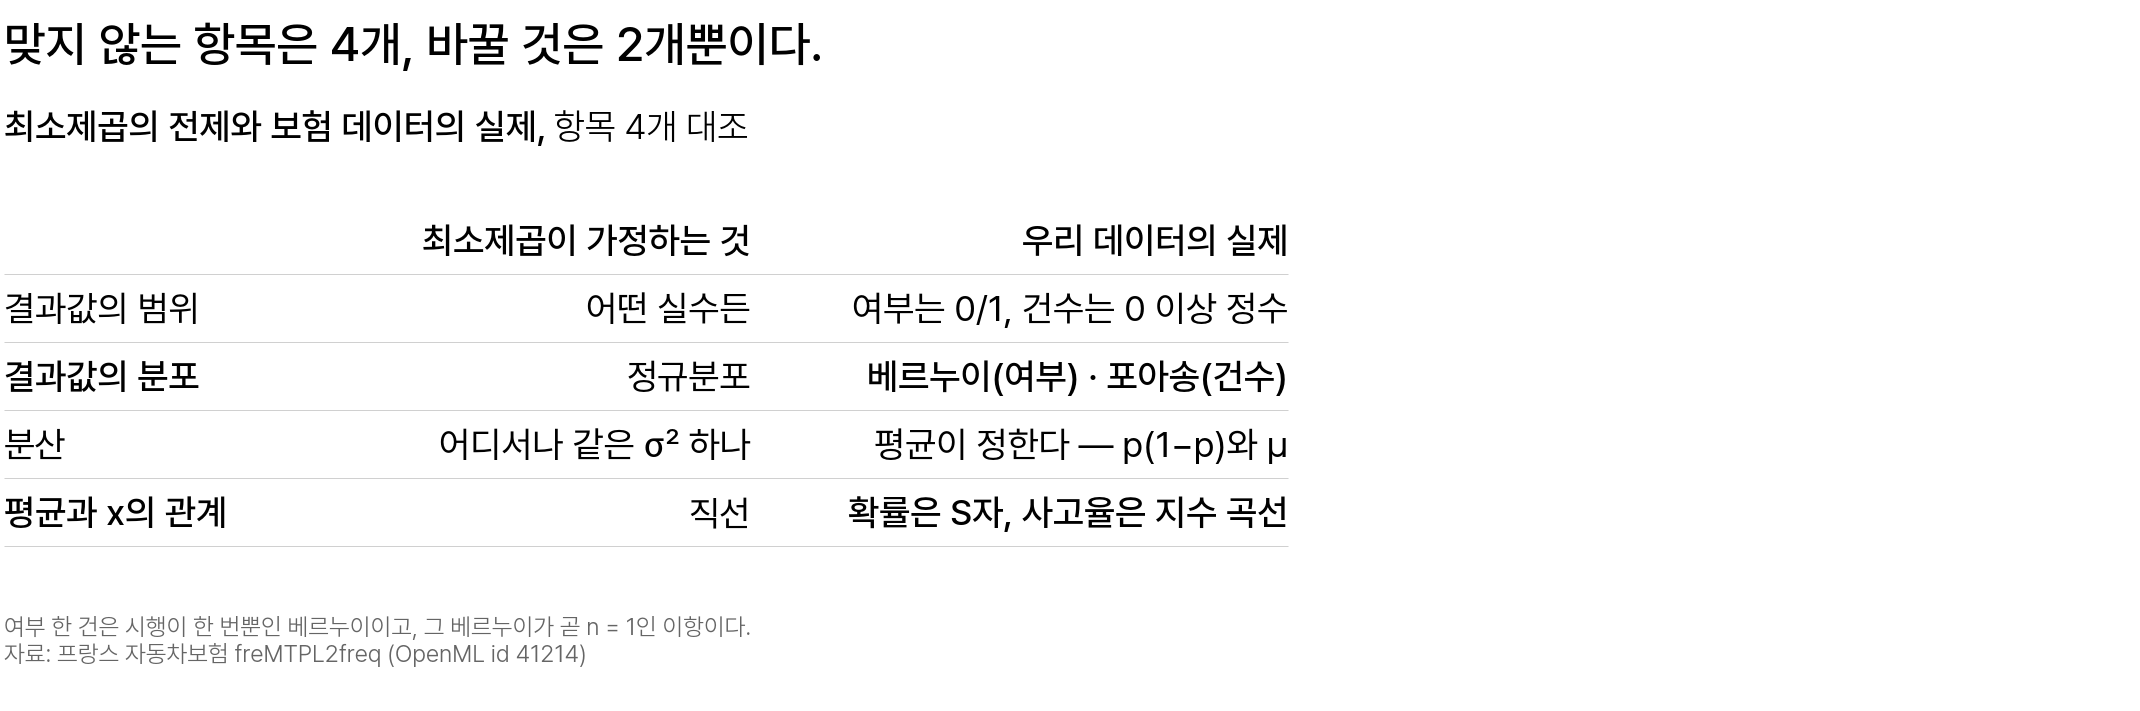

In [ ]:
# 도해 생성 코드는 LMS 에서만 실행됩니다

<p align="center"><em>▲ 최소제곱의 전제와 보험 데이터의 실제, 항목 4개 대조 — 굵게 적은 행 2개가 바꿀 항목이다. 결과값의 분포는 정규분포에서 베르누이·포아송으로, 평균과 x의 관계는 직선에서 S자·지수 곡선으로 바뀐다. 굵지 않은 행 2개(범위·분산)는 따로 고칠 항목이 아니라 그 둘을 바꾸면 함께 달라지는 결과다 — 값이 어디까지 갈 수 있는지도, 분산이 σ² 하나가 아니라 평균을 따라 움직인다는 것도 결국 분포가 정한다</em></p>

맞지 않는 항목 4개 가운데 바꿀 것은 2개입니다 — **결과값의 분포**를 정규분포에서 베르누이·포아송으로, **평균과 $x$ 의 관계**를 직선에서 S자·지수 곡선으로 바꾸면 범위와 분산 2개 행은 함께 달라집니다.

**그래서** 회귀를 전부 버릴 일이 아닙니다. **선형예측자 부분은 그대로 써도 됩니다** — 문제는 그 값을 결과값에 그대로 대응시키고 분포를 정규분포로 고정한 것뿐입니다.

<details class="lms-extra"><summary>자세히 — 대조표 4개 행의 항목별 해설</summary>

그림의 4개 행에 설명을 한 문장씩 더하면 이렇습니다.

| | 최소제곱이 가정하는 것 | 이 데이터의 실제 |
|---|---|---|
| 결과값의 범위 | 어떤 실수든 | 여부는 0/1, 건수는 0 이상의 정수 |
| 결과값이 따르는 분포 | 정규분포(오차가 정규라는 말과 같다) | **베르누이(여부) · 포아송(건수)** — 오차를 따로 더하는 것이 아니라 결과값 자체가 그 분포를 따른다 |
| 분산 | 어디서나 같은 $\sigma^2$ — 평균과 따로 정한다 | 평균이 정한다 — 여부는 $p(1-p)$, 건수는 $\mu$ |
| 평균과 설명변수의 관계 | 직선 | **확률은 S자, 사고율은 지수 곡선** |

둘째 행의 괄호가 가장 자주 혼동되는 부분입니다. 최소제곱에서 정규분포를 따르는 것은 **오차 $\varepsilon_i$** 이고, 결과값 $y_i$ 는 「직선 + 오차」라서 정규분포를 따릅니다. GLM 에는 오차를 따로 더하는 항이 아예 없고 **결과값 자체가 베르누이나 포아송을 따른다**고 두므로, 이 뒤부터는 「오차항」이라는 말이 사라집니다.

</details>

GLM 은 분포를 하나씩 부르지 않고 **분포족(family)** 으로 묶어 부릅니다. 사고 여부 한 건은 시행이 1회뿐인 베르누이이고 이것은 $n = 1$ 인 이항과 같아서, 다음 표부터는 이 항목을 **이항 분포족**이라 적습니다.

#### 핵심 주의점

직선이 낸 예측을 0 과 1 사이로 잘라 내면 최소제곱을 그대로 써도 된다 — 이렇게 읽으면 안 됩니다.

$$
\operatorname{Var}(y) = p(1 - p)
$$

잘라내기로는 「분산이 어디서나 같은 $\sigma^2$」 라는 전제가 돌아오지 않습니다. 따라서 "음수 예측만 0 으로 올리면 직선으로 확률을 재도 된다" 는 틀린 문장입니다.

> **0/1 결과의 분산은 상수가 아니라 평균이 정하는 $p(1-p)$ 이므로, 바꿀 것은 예측값의 범위가 아니라 분포와 곡선 2개다.**

> **[문제] 같은 두 위치의 배수 — 표준편차 기준과 분산 기준의 차이**
>
> 최소제곱이 가정하는 분포와 포아송이 가정하는 분포를 나란히 놓은 그림으로 돌아가 보세요. 이번에는 본문에서 읽지 않은 위치를 하나 더 읽어 봅니다 — 오른쪽 포아송 그림의 파란 곡선은 $x = 11$ 위치에서 약 3 이고, $x = 20$ 위치에서는 앞에서 읽은 대로 7 가까이입니다. 주황 계단은 검은 점선 왼쪽에 세로로 놓여 있어서, 넓어지는 방향은 위아래 곧 세로축 $y$(사고 건수) 쪽입니다. 그 두 위치의 계단이 **위아래로** 넓어진 정도를 **표준편차**로 비교하면 몇 배 차이이고, 같은 두 위치를 **분산**으로 비교하면 몇 배입니까?
>
> 1. 표준편차 약 2.3 배 · 분산 약 1.5 배 — 제곱근을 씌운 쪽이 배수를 키운다
> 2. 둘 다 약 2.3 배 — 분산으로 재든 표준편차로 재든 배수는 하나다
> 3. 표준편차 약 1.5 배 · 분산 약 2.3 배 — $\sqrt{7} / \sqrt{3} = 1.53$ 과 $7 / 3 = 2.33$
> 4. 둘 다 약 1.5 배 — 분산도 제곱근을 씌운 값으로 잰다

## 2. GLM 의 구성요소 3개 — 분포·선형예측자·링크함수

## 회귀가 설명하는 것은 평균이다

18세 운전자 계약을 1,000건 모으면 어떤 계약은 사고가 0건이고 어떤 계약은 2건입니다. 회귀가 맞히려는 값은 계약 하나하나의 결과가 아니라 **그 1,000건의 평균**입니다 — 뒤(6. 실제 데이터 적용)에서 계산하면 18세 구간의 관측 사고율이 0.31건/년입니다.

그럼 그 평균을 계약마다 다르게 만드는 식은 어떻게 적습니까?

**여기서 할 일**

1. 회귀가 설명하는 값이 평균이고, 평균이 정해지면 분포도 정해진다는 것을 확인합니다.
2. 특성을 점수 $\eta$ 로 합치고, $\eta$ 와 평균을 구분합니다.
3. 점수를 평균으로 역변환하는 단계를 정의하고 모형 3개를 대조합니다.

기호로 적으면 이렇습니다.

$$
E[y \mid x] = \mu
$$

- $y$ : 그 계약에서 관측된 결과 — 사고 여부(0/1)이거나 사고 건수(0, 1, 2, …)
- $x$ : 그 계약의 특성 — 나이·할증점수
- $E[y \mid x]$ : 특성이 $x$ 인 계약들의 결과를 평균 낸 값이고, 그 값을 평균 $\mu$ 라 적습니다

말로 하면 "특성이 같은 계약을 모아 결과를 평균 내면 그 값이 $\mu$ 다" 입니다. 관측은 그 $\mu$ 주변에서 흩어지고, 회귀가 그리는 선은 관측이 아니라 $\mu$ 를 이은 선입니다.

여기서 첫 구성요소가 나옵니다. **평균이 정해지면 분포가 정해집니다** — 베르누이는 확률 하나로, 포아송은 평균 건수 하나로 정해지고, 앞에서 분산까지 평균이 정한다고 확인한 것이 같은 이야기입니다.

- **구성요소 ① 분포** — 결과값 $y$ 가 나오는 분포. 사고 여부면 베르누이(이항), 사고 건수면 포아송입니다.

## 특성을 점수로 합친다 — 선형예측자 η

계약 한 건에는 나이·할증점수·지역이 함께 적혀 있습니다. 이 값들을 숫자 하나로 합쳐야 계약마다 다른 평균을 계산할 수 있는데, GLM 은 합치는 방법으로 **직선**을 그대로 씁니다.

$$
\eta = \beta_0 + \beta_1 x_1 + \cdots + \beta_p x_p
$$

- $\eta$ (에타) : **선형예측자** — 특성에 계수를 곱해 모두 더한 점수
- $\beta_1, \dots, \beta_p$ : 각 특성이 1 오를 때 $\eta$ 에 더해지는 양이고, $\beta_0$ 는 절편

말로 하면 "특성마다 계수를 곱해 모두 더한 값이 점수 $\eta$ 다" 입니다. 확률도 건수도 아닌 내부 점수라, 값이 음수가 되어도 상관없습니다.

이 형태를 유지하는 이유는 2가지입니다.

- **효과가 덧셈으로 합쳐집니다** — 나이 항과 할증점수 항이 서로 얽히지 않아 항 하나씩 읽을 수 있고, $x_1$ 이 1 증가하면 어느 위치에서나 $\eta$ 에 $\beta_1$ 이 더해집니다.
- **결과의 종류가 달라도 같은 틀입니다** — 확률이든 건수든 오른쪽은 이 식 하나입니다.

숫자로 확인해 보겠습니다. 절편에 할증점수 하나만 넣은 포아송 모형에서 $\beta_0 = -2.30$, $\beta_1 = 0.0218$ 이라 하면, 할증점수가 기준 계약보다 10점 높은 계약의 점수는 $-2.30 + 0.0218 \times 10 = -2.08$ 입니다. 여기서 $x_1$ 에 넣는 값은 할증점수 자체가 아니라 기준 계약과의 점수 차이고, 그래서 절편 $-2.30$ 은 기준 계약의 연간 사고율 0.1006건/년에 로그를 씌운 값입니다.

**할증점수(BonusMalus, 보너스-말러스 점수)** — 사고 이력에 따라 계약마다 매겨지는 50점부터 230점까지의 지수입니다. 오늘 $x_1$ 로 쓰는 변수이고, "1점이 사고율을 몇 배로 만드는가" 가 오늘의 주된 질문입니다.

**핵심 주의점 — $\eta$ 는 평균이 아닙니다.** 사고 건수의 평균은 0 아래로 내려갈 수 없으니 −2.08 은 건수일 수 없습니다. $\eta$ 는 평균에 링크를 적용한 값, 곧 평균을 변환한 값입니다. 선형회귀에서만 링크가 항등이라 두 값이 같아집니다.

- **구성요소 ② 선형예측자** — 특성에 계수를 곱해 더한 점수 $\eta$. GLM 에서 바꾸지 않는 부분입니다.

## 점수를 평균으로 바꾸는 변환 — 역링크, 그리고 링크

점수 $\eta$ 는 −2.08 처럼 음수도 됩니다. 그런데 답으로 필요한 값은 0 과 1 사이의 확률이거나 0 이상의 사고 건수입니다. 그 사이를 잇는 변환이 **역링크**입니다.

$$
\mu = g^{-1}(\eta) \qquad\Longleftrightarrow\qquad g(\mu) = \eta
$$

- $g^{-1}$ : **역링크(inverse link)** — 점수를 평균의 범위 안으로 역변환하는 함수. 예측할 때 계산하는 방향입니다
- $g$ : **링크함수** — 평균을 점수 $\eta$ 와 같은 스케일로 옮기는 함수. 모형을 적을 때 쓰는 방향입니다

말로 하면 "왼쪽이 예측 방향이고 오른쪽이 모형을 적는 방향이라, 둘은 같은 관계를 반대로 적은 것" 입니다. 사고 확률이면 역링크가 0～1 안으로, 사고 건수면 0 이상으로 역변환합니다. 도입 그림에서 위로 돌아가던 화살표가 그 링크 $g$ 였습니다.

- **구성요소 ③ 링크함수** — 평균과 점수를 잇는 함수 $g$. 결과의 종류에 맞춰 바꾸는 부분입니다.

#### 로짓 — 가장 널리 쓰이는 링크

확률은 0 과 1 사이에 갇혀 있고 점수는 어느 쪽으로든 커집니다. 사고 확률 0.8 인 계약을 점수 스케일로 옮기려면 확률을 「일어날 쪽 ÷ 일어나지 않을 쪽」으로 고쳐 쓴 뒤 로그를 씌우면 되는데, 그 변환의 이름이 **로짓(logit)** 입니다 — $g(\mu) = \log \frac{\mu}{1-\mu}$ 이고 0 과 1 사이의 확률을 $-\infty$ 부터 $+\infty$ 까지 변환합니다. $\mu = 0.8$ 이면 나눈 값이 4 이고 로짓은 $\log 4 = 1.386$ 입니다.

확률 0 과 1 은 대입할 수 없습니다. $\mu = 0$ 이면 로그가 정의되지 않고, $\mu = 1$ 이면 분모가 0 입니다.

<img src="https://en.wikipedia.org/wiki/Special:FilePath/Logit.svg" width="640" height="417"/>
<p align="center"><em>▲ 로짓 함수 — 범례의 f(x) = ln(x / (1 − x)) 에서 x 는 확률 μ 고(설명변수 x 와 글자만 같다) f(x) 가 로짓 η 인데, 가로축 확률 0.5 가 세로축 0 에 대응하고 확률이 0이나 1 에 접근할수록 세로축이 ±6 을 넘어 급격히 증가하니 가운데는 완만하고 급한 것은 양 끝뿐이다 (출처: Wikipedia)</em></p>

우리가 계산하는 것은 이것의 역방향이고, 나눈 값에 이름을 부여하는 것은 뒤(3. 로지스틱 회귀)에서 합니다. 역링크가 직선을 어떻게 역변환하는지는 그림 3개를 나란히 놓으면 바로 보입니다.

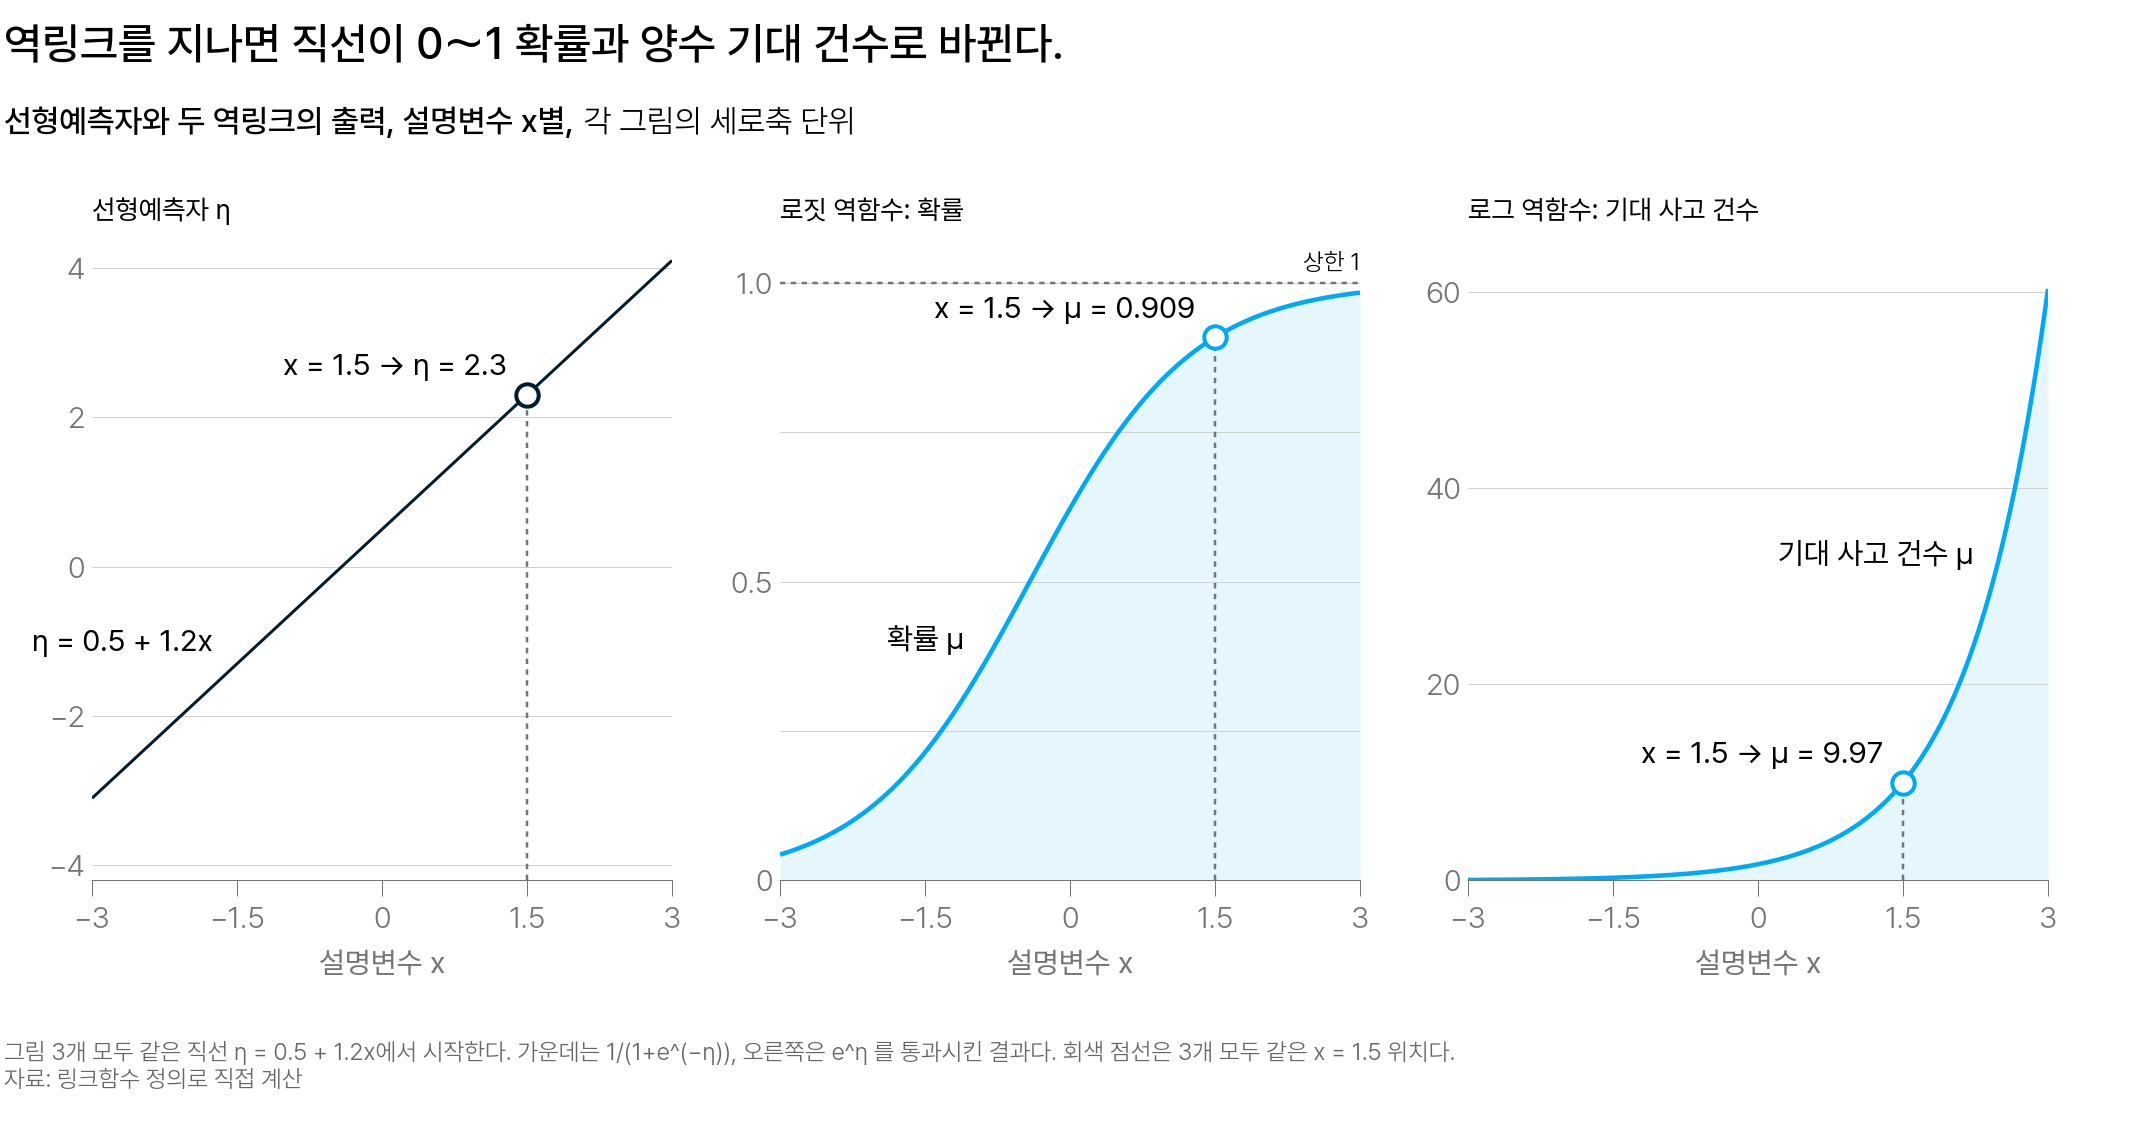

In [ ]:
# 도해 생성 코드는 LMS 에서만 실행됩니다

<p align="center"><em>▲ 그림 1(왼쪽 선형예측자 η)·그림 2(가운데 로짓 역함수)·그림 3(오른쪽 로그 역함수) — 회색 점선이 3개 모두 같은 x = 1.5 위치인데 속 빈 원의 값만 달라지니, 시작한 직선은 하나이고 링크함수가 세로축의 범위만 바꾼 것이다</em></p>

#### 결과 해석

세 그림의 **가로축은 전부 같은 $x$** 이고, 시작한 직선도 $\eta = 0.5 + 1.2x$ 하나뿐입니다. 달라지는 것은 세로축뿐이라, 회색 점선 위 속 빈 원의 값 3개가 서로 다릅니다. 0 과 1 사이의 S자가 된 것은 로짓 역함수인 그림 2 이고, 그림 3 은 0 아래로 내려가지 않은 채 위로 급하게 증가합니다.

**그래서** 앞에서 위젯으로 보았던 상충이 사라졌습니다. **역링크가 값의 범위를 지키고, 직선은 설명변수의 효과를 담는** 구조가 된 것입니다. 여기 $x$ 는 실제 할증점수가 아니라 곡선 모양만 보려고 고른 예시입니다.

##### 그림에 적힌 값 3개의 출처

속 빈 원의 값 3개는 링크 정의만 있으면 계산됩니다. 아래 코드가 같은 $x = 1.5$ 를 링크 3개에 통과시키고, 본문에서 읽던 $x = 3$ 도 한 행 더 출력합니다.

In [ ]:
# 그림 3개의 x = 1.5 위치와 본문이 읽은 x = 3 위치 - 같은 직선이 값 3개로 달라진다
import numpy as np

for x in (1.5, 3.0):                         # 1.5 는 그림 3개 공통 회색 점선 위치
    eta = 0.5 + 1.2 * x                      # 그림 1 - 손대지 않은 직선의 출력
    print(f"x = {x} · η = {eta:.1f} · 확률 μ = {1 / (1 + np.exp(-eta)):.3f} · 기대 사고 건수 μ = {np.exp(eta):.2f}")

#### 결과 해석

첫 행 `x = 1.5 · η = 2.3 · 확률 μ = 0.909 · 기대 사고 건수 μ = 9.97` 이 그림의 속 빈 원 3개와 같은 값입니다. 둘째 행 `x = 3.0` 에서는 확률이 0.984 로 상한 1 에 막혀 더 커지지 못하는데, 기대 사고 건수는 상한이 없어 60.34 까지 커집니다.

## 모형 3개를 한 표로

지금까지 정의한 구성요소 3개를 모형 3개에 대입하면 오늘 다룰 표가 완성됩니다. 자동차보험으로 말하면, 사고 여부를 묻느냐 사고 건수를 묻느냐에 따라 열 하나가 정해집니다.

| | 선형회귀 | 로지스틱 회귀 | 포아송 회귀 |
|---|---|---|---|
| 결과값 $y$ | 어떤 실수든 | 0 또는 1 | 0, 1, 2, … |
| ① 분포 | 정규 | 이항 | 포아송 |
| 평균 $\mu$ 의 범위 | 제한 없음 | 0 과 1 사이 | 0 보다 크다 |
| ③ 링크 $g(\mu)$ | 항등 $\mu$ | 로짓 $\log\frac{\mu}{1-\mu}$ | 로그 $\log \mu$ |
| ③ 역링크 $g^{-1}(\eta)$ | $\eta$ | $\frac{1}{1+e^{-\eta}}$ | $e^{\eta}$ |
| 최종 예측 | 값 자체 | 사고를 겪을 확률 | 기대 사고 건수 |
| $e^{\beta}$ 의 뜻 | 쓰지 않는다 — 계수는 더해지는 양 $\beta$ 다 | 오즈비 | 사고율비 |

② 선형예측자 행이 표에 없는 이유는 세 열이 모두 같기 때문입니다 — 바꾸는 것은 ①과 ③ 2개뿐입니다. 첫 열이 앞에서 본 그 최소제곱 회귀라, **선형회귀는 GLM 의 한 사례**입니다($g(\mu) = \mu$ 라 링크가 변환을 하지 않습니다).

표의 링크 행에 적은 3개는 각 분포족에 수학적으로 가장 자연스럽게 대응하는 링크라 **정준 링크(canonical link)** 라 부릅니다. 구성요소를 학술 문헌은 다른 이름으로 적어서, ① 분포를 **무작위 구성요소(random component)**, ② 선형예측자를 **체계적 구성요소(systematic component)** 라 부릅니다. 뒤에 나오는 코드 주석도 이 이름을 씁니다. 정준 링크가 의무는 아니어서, 감마 분포족처럼 정준 링크가 음수를 내는 경우에는 실무에서 로그 링크를 적용합니다.

#### 핵심 주의점

링크함수를 「결과값 $y$ 에 로그를 씌우고 최소제곱을 실행하는 것」처럼 해석하면 안 됩니다.

$$
\log E[y] = \eta
$$

로그가 씌워지는 대상은 결과값이 아니라 평균입니다. $\log y$ 쪽에 최소제곱을 맞추면 얻는 값은 $E[\log y]$ 라, 값 1 · 10 · 100 이면 $\log y$ 를 평균 낸 2.303 을 지수로 되돌린 10.0 이라 산술평균 37.0 과 다릅니다.

> **로그 링크는 결과값을 원래 단위에 둔 채 평균에만 로그를 씌우므로, 역변환한 $e^{\eta}$ 는 1 · 10 · 100 의 평균인 37.0 과 일치한다.**

> 분포와 링크만 바꾸면 직선은 그대로 쓸 수 있습니다. 표의 둘째 열을 실제 계약에 적합하는 것이 「3. 로지스틱 회귀 — 오즈와 오즈비」, 셋째 열이 「4. 포아송 회귀와 노출 보정」입니다.

> **[문제] 점수 η 와 평균 μ 의 구분**
>
> 할증점수가 기준보다 10점 높은 계약의 점수가 $\eta = -2.30 + 0.0218 \times 10 = -2.08$ 로 계산되었습니다. 이 계약을 포아송 회귀(로그 링크)로 다루고 있다면 −2.08 과 기대 사고 건수의 관계를 옳게 적은 것은 어느 쪽입니까?
>
> 1. −2.08 이 곧 기대 사고 건수다 — 점수가 음수이니 이 계약은 사고 건수가 음수로 예측된다
> 2. −2.08 은 평균을 로그로 변환한 값이고, 기대 사고 건수는 역링크를 적용한 $e^{-2.08} = 0.125$ 건/년이다
> 3. −2.08 의 부호만 떼어 낸 2.08 건/년이 기대 사고 건수다
> 4. −2.08 은 사고를 겪을 확률이라 0 과 1 사이로 잘라 0 으로 읽는다

## 3. 로지스틱 회귀 — 오즈와 오즈비

## 이항 + 로짓 = 로지스틱 회귀

"사고가 날까, 안 날까" 만 묻는 경우에는 답이 0 아니면 1 입니다. 그 0/1 에 회귀를 맞추려고 분포와 링크를 바꾼 것이 로지스틱 회귀(logistic regression)입니다. 자동차보험으로 말하면, 계약 한 건이 1년 안에 사고를 한 번이라도 겪을 확률을 매기는 모형입니다.

그럼 이렇게 만든 모형의 계수는 무슨 뜻이 됩니까?

**여기서 할 일**

1. 0/1 결과에 **이항 분포와 로짓 링크**를 적용해 로지스틱 회귀를 만듭니다.
2. 계수 $\beta$ 가 무엇에 곱해지는 배수인지, 곧 **오즈비**를 정의합니다.
3. 계약 67만 8천 건에 적합한 뒤 그 확률을 순서·크기로 검사합니다.

결과값이 0 아니면 1 이니 분포는 **이항**, 링크는 **로짓** 입니다. 앞에서 한 쌍으로 적은 두 식에서 첫 식만 바꾼 모양입니다.

**시그모이드(sigmoid)** — 로짓의 역함수 $\mu = 1/(1 + e^{-\eta})$ 입니다. 직선이 낸 값 $\eta$ 를 0 과 1 사이로 역변환해 확률로 읽을 수 있게 합니다.

<img src="https://en.wikipedia.org/wiki/Special:FilePath/Logistic-curve.svg" width="640" height="427"/>
<p align="center"><em>▲ 시그모이드 곡선 — η 가 0일 때 0.5, −6 쪽에서는 0 에, +6 쪽에서는 1 에 가까워지며 기울기가 0 에 접근한다 — 입력이 아무리 커져도 출력은 0과 1 사이에 남는다 (출처: Wikipedia)</em></p>

식으로 적으면 이렇습니다. 앞이 분포, 뒤가 링크와 선형예측자입니다.

$$
y_i \sim \text{Bernoulli}(\mu_i), \qquad \log \frac{\mu_i}{1 - \mu_i} = \eta_i = \beta_0 + \beta_1 x_{i1} + \cdots + \beta_p x_{ip}
$$

- $y_i$ · $\mu_i$ : 계약 $i$ 의 사고 여부(겪었으면 1)와 그 계약이 사고를 겪을 확률
- $\log \frac{\mu_i}{1-\mu_i}$ : 그 확률의 **로그오즈** — 오즈는 곧 정의합니다 · $\eta_i$ : 앞에서 정의한 선형예측자 그대로

이 식의 왼쪽과 오른쪽은 한 쌍입니다.

$$\log \frac{\mu_i}{1 - \mu_i} = \eta_i \qquad\Longleftrightarrow\qquad \mu_i = \frac{1}{1 + e^{-\eta_i}}$$

숫자 한 걸음으로 확인해 보겠습니다. 뒤에서 적합할 모형의 계수를 미리 쓰면, 45세·도시화 등급 C·휘발유 계약의 나머지 항이 $-3.9986$ 이고 할증점수 계수가 $0.01746$ 입니다.

**⑴ 점수를 계산합니다.** 할증점수가 50점인 계약이면 $\eta = -3.9986 + 0.01746 \times 50 = -3.1256$ 입니다.

**⑵ 역링크를 적용합니다.** $\mu = 1/(1 + e^{3.1256}) = 0.0421$ 이라, 음수였던 점수가 4.21% 라는 확률로 복원됩니다.

**그래서** 직선은 그대로 두고 링크만 바꾼 것이 로지스틱 회귀입니다. 이 식에서 $\beta_1$ 이 더해지는 대상은 확률이 아니라 좌변의 로그오즈라, 오즈부터 정의합니다.

<details class="lms-extra"><summary>자세히 — 로짓 식에서 μ = 1/(1+e^(−η)) 로의 변형</summary>

아래 첨자 $i$ 는 잠시 생략하고 씁니다. 출발은 왼쪽 식입니다. $\mu$ 는 사고를 겪을 확률이고 $\eta$ 는 직선이 낸 값입니다.

$$\log \frac{\mu}{1 - \mu} = \eta$$

**⑴ 양변에 지수를 씌우고 분모를 오른쪽으로 이항합니다.** 로그와 지수는 서로를 지우고, 양변에 $(1 - \mu)$ 를 곱해 오른쪽을 전개합니다.

$$\frac{\mu}{1 - \mu} = e^{\eta} \qquad\Longrightarrow\qquad \mu = e^{\eta} - e^{\eta}\mu$$

**⑵ $\mu$ 가 포함된 항을 한쪽에 모아 묶고, 양변을 $(1 + e^{\eta})$ 로 나눕니다.**

$$\mu(1 + e^{\eta}) = e^{\eta} \qquad\Longrightarrow\qquad \mu = \frac{e^{\eta}}{1 + e^{\eta}}$$

**⑶ 분자와 분모를 다시 $e^{\eta}$ 로 나눕니다.** 위아래를 같은 값으로 함께 나누는 것이라 분수의 값은 그대로이고, 분모에 남는 $1/e^{\eta}$ 를 $e^{-\eta}$ 로 고쳐 쓰면 마지막 형태가 나옵니다.

$$
\mu = \frac{1}{e^{-\eta} + 1}
$$

**⑷ 수치로 검산합니다.** $\eta = 3$ 이면 $e^{-3} = 0.0498$ 이라 $\mu = 0.9526$ 이고, $\eta = -3$ 이면 $\mu = 0.0474$ 입니다. $0.9526 + 0.0474 = 1$ 이라 0.5 를 가운데 두고 대칭입니다.

이것이 시그모이드입니다. $\eta$ 가 아무리 커져도 $e^{-\eta}$ 는 0 에 접근할 뿐이라 분모가 1 보다 작아지지 않으니 출력이 1 을 넘지 못하고, 아무리 작아져도 $e^{-\eta}$ 가 커지기만 하니 0 아래로 내려가지도 못합니다.

</details>

앞에서 직선을 크게 기울였던 극단값은 S곡선에서는 영향이 작습니다. 곡선의 양 끝이 이미 0 과 1 에 가까워 기울기가 0 에 접근해서, 극단값 한 건을 더 잘 맞혀도 얻는 것이 거의 없기 때문입니다.

<details class="lms-extra"><summary>더 깊이 — 극단값이 S곡선의 판정 경계를 크게 이동시키지 못하는 이유</summary>

같은 문제를 종양 데이터로 봅니다. 왼쪽이 사례 8건, 오른쪽은 거기에 크기 19·20 인 2건과 중간 사례를 추가한 것입니다.

<img src="https://christophm.github.io/interpretable-ml-book/logistic_files/figure-html/fig-logistic-class-threshold-1.png" width="640" height="320"/>
<p align="center"><em>▲ 같은 종양 데이터에 사례를 추가한 경우 2개 — 사례가 추가되면 곡선이 판정 기준 0.5 를 지나는 위치가 7.6 에서 4.4 로 이동하지만, 경계는 여전히 두 무리 사이에 남는다 (출처: C. Molnar, Interpretable ML Book)</em></p>

그림 라벨이 영어라 가로축 Tumor size 는 종양 크기, 세로축 Tumor class 의 benign tumor 는 양성·malignant tumor 는 악성이고, 가로 점선이 판정 기준 0.5 입니다.

요점은 크기 19·20 같은 극단값이 포함되어도 경계가 **두 무리 사이**에 남는다는 것입니다. 곡선의 오른쪽 끝이 상한 1 을 넘지 못해, 크기 19 의 사례에 모형이 이미 0.99 를 부여하고 있다면 그 한 건을 더 잘 맞히려고 곡선 전체를 기울여도 얻는 것이 0.001 뿐이기 때문입니다. 경계를 7.6 에서 4.4 로 이동시킨 것도 극단값이 아니라 두 무리 사이에 새로 추가된 중간 사례 쪽입니다.

</details>

### [직접 해보기] 두 계수가 S곡선을 움직이는 방식

화면의 점은 모의 관측 60개입니다 — 위쪽 줄이 `사고 있음 y = 1`, 아래쪽 줄이 `사고 없음 y = 0` 인 계약이고 가로 위치는 그 계약의 위험 점수입니다.

1. **해 보기.** 위젯은 `절편 β₀` 가 −1.5, `기울기 β₁` 이 0.30 인 채로 열리고 `로그우도 ℓ(β₀, β₁)` 에는 −29.1 이 찍혀 있습니다. 하늘색 `예측 확률 곡선` 이 그 조합의 사고 확률 $\mu(x)$ 입니다. 두 슬라이더를 각각 움직여 보세요.
2. **관찰.** `절편 β₀` 를 키우면 S곡선이 형태 그대로 왼쪽으로 이동하고, `기울기 β₁` 을 키우면 S자가 가팔라집니다. 확률 0.5 를 지나는 위치는 $\eta = 0$ 인 곳, 곧 $x = -\beta_0/\beta_1$ 입니다. 아래 문구는 `오르막 방향 β₀` 로 어느 쪽으로 이동할지 알려 주다가, 로그우도가 최대인 조합에서 `여기가 최댓값이다 — ℓ이 가장 크다` 로 바뀝니다.
3. **확인 질문.** 로그우도를 가장 크게 만드는 조합이 하나로 정해집니까, 여러 조합이 같은 최댓값을 냅니까?

In [ ]:
# 인터랙티브 위젯 — 셀을 실행하면 나타납니다 (인터넷 연결 필요)
# 아래가 잘려 보이면 height 값을 키우세요.
from IPython.display import IFrame
IFrame("https://aic-data.aiffel.io/api/widget-file/advanced-statistics/logistic-lab.html", width=980, height=520)

<details class="lms-answer"><summary>답 확인 — 로그우도를 최대로 만드는 계수 조합의 개수</summary>

조합 하나로 정해집니다. 로그우도가 가장 커지는 곳이 1곳이고 거기서 벗어나면 값이 감소하는데, 그 조합이 곧 **로지스틱 회귀의 최대우도추정값**입니다.

슬라이더로는 `절편 β₀` 를 −3.5, `기울기 β₁` 을 0.80 에 두었을 때 `여기가 최댓값이다 — ℓ이 가장 크다` 가 뜨고, 그때 `로그우도 ℓ(β₀, β₁)` 는 위젯을 열었을 때의 −29.1 에서 −23.1 까지 증가합니다. 거기서 `절편 β₀` 만 −3.0 으로 이동하면 −23.8, `기울기 β₁` 만 1.00 으로 이동하면 −25.6 으로 감소합니다. 슬라이더 눈금이 넓어 바로 옆 조합인 (−3.6, 0.82) 에서도 같은 문구가 뜨지만, 눈금 사이까지 모두 탐색하면 로그우도가 최대인 조합은 (−3.46, 0.80) 한 곳입니다.

첫날 우도가 최대인 값(MLE)을 찾던 일과 같습니다. 찾을 것이 1개($p$)에서 2개($\beta_0, \beta_1$)로 늘어 탐색 공간이 2차원이 되었을 뿐입니다. 최댓값이 하나뿐이라는 것이 보장되어 있어(로그우도가 오목함수입니다) 어디서 출발해도 같은 답에 도달합니다.

</details>

## 오즈 — 확률의 나눗셈 표현

계수를 해석하려면 **오즈**부터 확실히 해야 합니다.

**오즈(odds)** — 일어날 확률을 일어나지 않을 확률로 나눈 값입니다. 확률 0.75 면 $0.75 / 0.25 = 3$ 이라 "일어날 쪽이 일어나지 않을 쪽보다 3배 가능성이 크다"는 뜻입니다.

$$\text{오즈} = \frac{\mu}{1 - \mu}$$

확률은 0～1 로 범위가 제한되고, 오즈는 0～무한대, 로짓은 −무한대～+무한대까지 넓어집니다. 확률 5개 값을 스케일 3개에 그대로 표시해 보겠습니다.

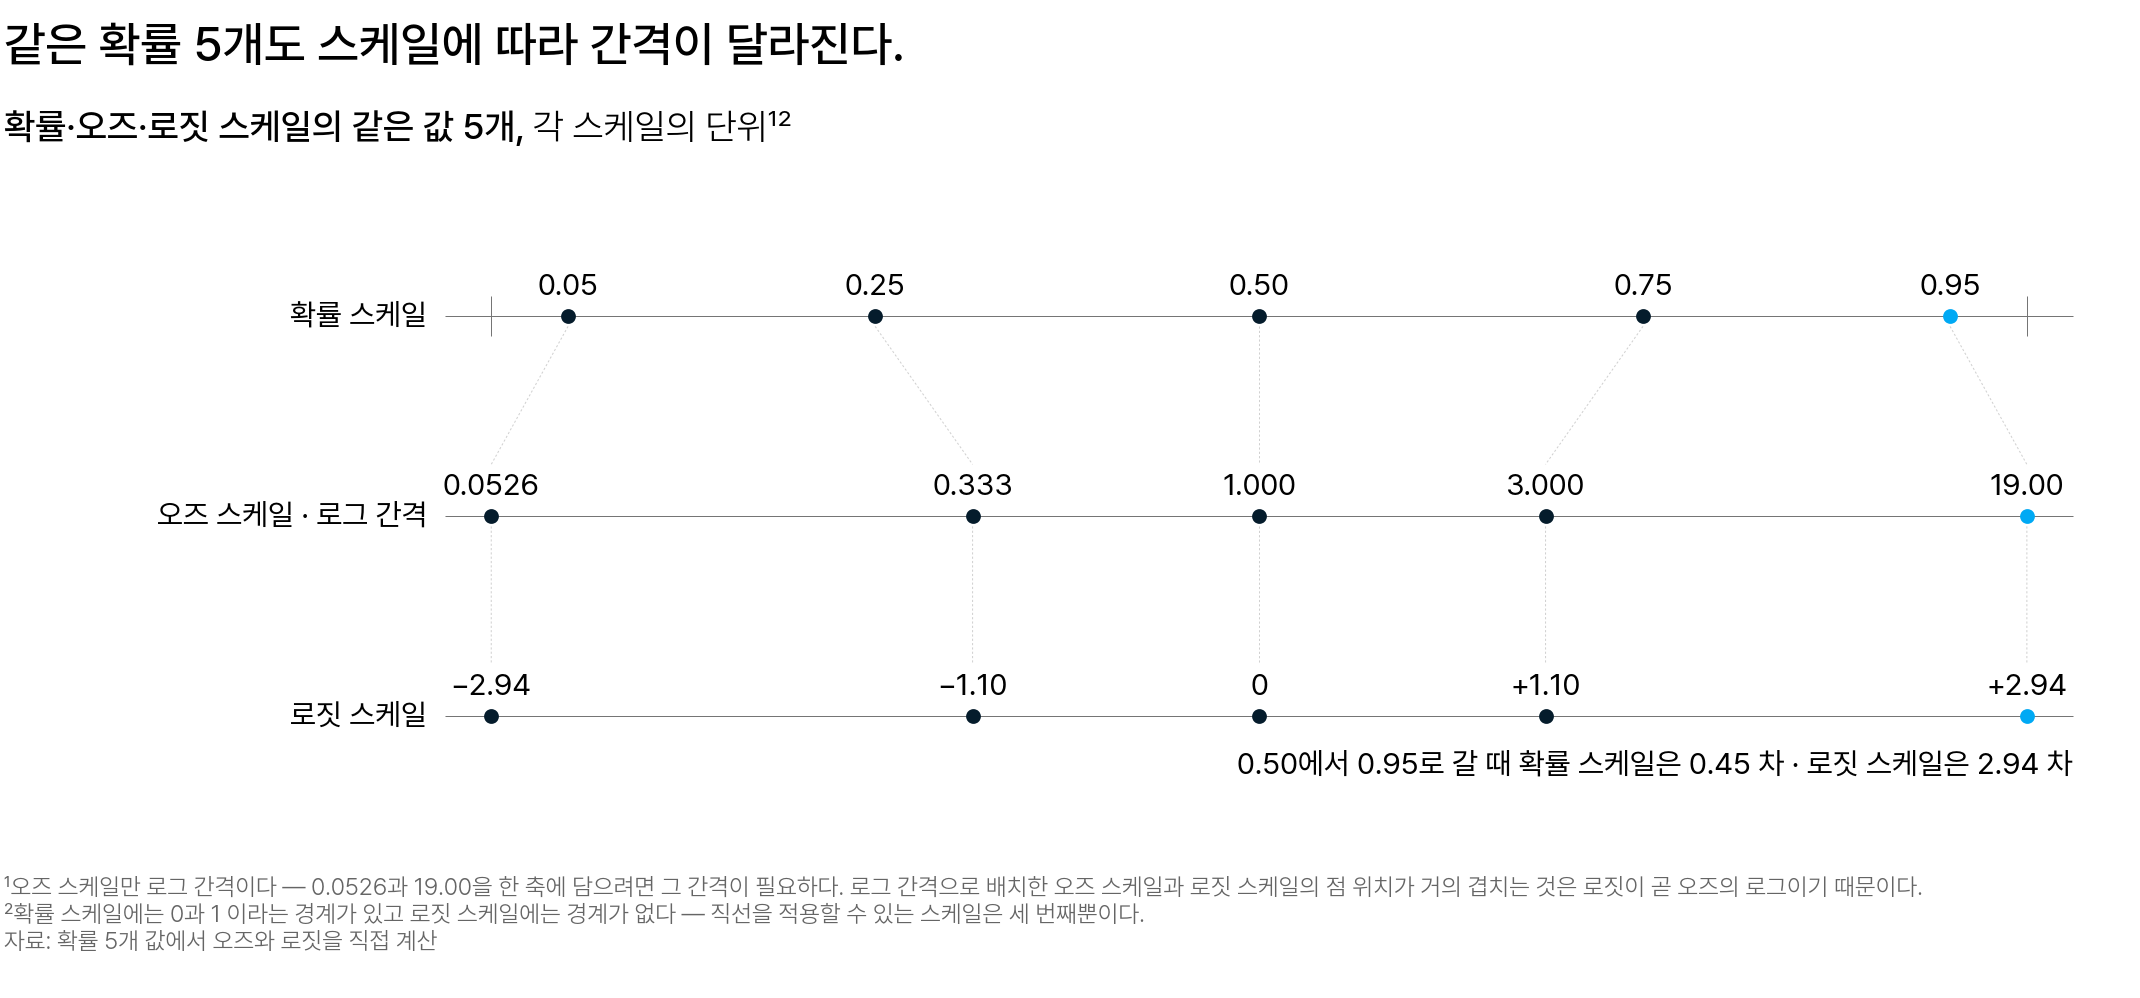

In [ ]:
# 도해 생성 코드는 LMS 에서만 실행됩니다

<p align="center"><em>▲ 확률·오즈·로짓 스케일 3개 — 같은 값 5개가 스케일마다 다른 간격으로 표시된다. 확률 스케일에서 0.50 과 0.95 는 0.45 차이지만 로짓 스케일에서는 2.94 차로 넓어지고, 확률 스케일의 양 끝에 그은 짧은 세로선이 0 과 1 의 경계다</em></p>

셋째 행 로짓 스케일에는 그 경계가 없습니다. **그래서** 어떤 값이든 내는 직선을 적용할 수 있는 스케일은 로짓 스케일뿐입니다.

로지스틱 회귀의 좌변이 바로 그 로짓이니, $x_1$ 이 1 오르면 **로짓이 $\beta_1$ 만큼 더해집니다.** 나머지 변수를 그대로 두고 두 계약의 로짓을 빼면 로그가 제거되며 이 식 하나가 남습니다.

$$\frac{\text{오즈}(x_1 + 1)}{\text{오즈}(x_1)} = e^{\beta_1}$$

작은 예로 한 쌍만 보겠습니다. 확률 0.05 인 계약의 오즈는 $0.05 / 0.95 = 0.0526$ 이고, 오즈가 1.018배가 되면 0.0536 입니다. 이 오즈를 확률로 역산하면 0.0508 이라, 확률은 0.0008(0.08%포인트)만 증가합니다 — 곱해진 것은 확률이 아니라 오즈입니다.

**오즈비(odds ratio)** — 설명변수가 1 오를 때 오즈에 **곱해지는** 배수입니다. 로그 스케일에서 계산한 차 $\beta_1$ 이 원래 단위에서는 비 $e^{\beta_1}$ 로 나타난 것이고, 1 이 "변화 없음"에 해당합니다. $\beta_1$ 이 양수면 $e^{\beta_1} > 1$ 이라 오즈가 커지고, 음수면 1 보다 작아 줄어듭니다.

<details class="lms-extra"><summary>자세히 — 확률 5개 값의 오즈·로짓과 두 로짓의 뺄셈</summary>

오즈는 $\mu / (1-\mu)$, 로짓은 그 오즈에 로그를 씌운 값입니다.

| 확률 $\mu$ | 오즈 $\mu/(1-\mu)$ | 로짓 $\log[\mu/(1-\mu)]$ |
|---|---|---|
| 0.05 | 0.0526 | −2.94 |
| 0.25 | 0.333 | −1.10 |
| 0.50 | 1.000 | 0 |
| 0.75 | 3.000 | +1.10 |
| 0.95 | 19.00 | +2.94 |

**⑴ 한 행만 직접 계산해 보겠습니다.** $\mu = 0.95$ 면 오즈는 $0.95 / 0.05 = 19.00$, 로짓은 $\log 19.00 = 2.94$ 입니다. 0.05 쪽 로짓이 −2.94 로 부호만 다른 것은 $\mu$ 와 $1-\mu$ 를 맞바꾸면 오즈가 역수가 되기 때문입니다.

**⑵ 이제 오즈비 식을 유도합니다.** 할증점수만 1점 올린 계약과 원래 계약의 두 로짓을 뺍니다. 우변에서 $\beta_0$ 끼리, $\beta_1 x_1$ 끼리 상쇄되고 $\beta_1 (x_1 + 1)$ 을 전개한 $\beta_1$ 하나만 남습니다.

$$
\log\frac{\mu(x_1 + 1)}{1 - \mu(x_1 + 1)} - \log\frac{\mu(x_1)}{1 - \mu(x_1)} = \beta_1
$$

- $\mu(x_1)$ · $\mu(x_1 + 1)$ : 할증점수가 $x_1$ 점인 계약과, 나머지 조건은 그대로 두고 1점 올린 계약의 사고 확률

**⑶ 각 항 안의 $\mu/(1-\mu)$ 가 오즈이니 이름만 바꿔 적고, 로그의 뺄셈 법칙 $\log a - \log b = \log \frac{a}{b}$ 로 두 로그를 합칩니다.**

$$
\log\frac{\text{오즈}(x_1 + 1)}{\text{오즈}(x_1)} = \beta_1
$$

**⑷ 양변에 지수를 씌웁니다.** 로그가 제거되고 비 하나만 남습니다.

$$
\frac{\text{오즈}(x_1 + 1)}{\text{오즈}(x_1)} = e^{\beta_1}
$$

**⑸ 음수 계수도 수치로 확인해 두겠습니다.** $\beta_1 = -0.05$ 라면 $e^{-0.05} = 0.951$ 이라 오즈에 0.951 이 곱해지니, 남는 차이 $1 - 0.951 = 0.049$ 를 **4.9% 낮아진다**로 읽습니다.

**확률로 보고할 때 기준 계약을 밝히는 이유.** 오즈비는 조건 없이 한 값으로 말할 수 있지만, 확률로 옮기려면 "할증점수 50점 계약(45세 · 도시화 등급 C · 휘발유 기준)의 사고 확률 4.21%는 60점에서 4.97%가 됩니다" 처럼 기준을 함께 적어야 합니다. 90점 계약이라면 같은 10점이 8.11% → 9.51% 이기 때문입니다.

</details>

그럼 이 계약 데이터의 $\beta_1$ 은 얼마입니까. 구성요소 2개(이항 분포·로짓 링크)를 함수에 적어 넣으면 됩니다.

In [ ]:
# 이항 + 로짓 = 로지스틱 회귀 — statsmodels 로는 이 코드 4개 행이 전부다
import statsmodels.api as sm
import statsmodels.formula.api as smf

insurance["사고여부"] = (insurance["ClaimNb"] > 0).astype(int)   # 건수를 겪음(1)/아님(0)으로 변환한 열

res_bin = smf.glm("사고여부 ~ BonusMalus + DrivAge + Area + VehGas",   # 체계적 구성요소 η
                  data=insurance,                                      # 계약 678,013건
                  family=sm.families.Binomial()).fit()                 # 무작위 구성요소 = 이항

print(round(res_bin.params["BonusMalus"], 5))    # 0.01746 — 본문이 이어서 쓰는 β

eta0 = (res_bin.params["Intercept"] + res_bin.params["DrivAge"] * 45
        + res_bin.params["Area[T.C]"] + res_bin.params["VehGas[T.Regular]"])
print(round(eta0, 4))                            # -3.9986 — 45세 · 도시화 등급 C · 휘발유 계약의 나머지 항

방금 실행한 코드가 출력한 대로 할증점수 계수는 $\beta_1 = 0.01746$, 오즈비는 $e^{0.01746} = 1.018$ 입니다. **점수 1점당 사고를 겪을 오즈가 1.8% 높아진다** 는 뜻이고, 두 번째로 출력한 $\eta_0 = -3.9986$ 이 앞에서 미리 쓴 그 나머지 항입니다.

**도시화 등급(Area)** — 사는 곳의 인구 밀집도를 6단계로 매긴 값이라 밀집도가 가장 낮은 A 부터 가장 높은 F 까지 있고, 코드가 읽은 `Area[T.C]` 가 그 가운데 C 등급입니다. **연료(VehGas)** — 경유(Diesel)인지 휘발유(Regular)인지 적은 열이라 값이 2개뿐이고, 코드가 읽은 `VehGas[T.Regular]` 가 휘발유입니다. 둘 다 기준으로 정한 값(등급 A · 경유)이 있어 계수는 전부 그 기준 대비입니다.

$e^{\beta}$ 가 무엇에 곱해지는지를 표로 구분해 둡니다.

| 계수 | 분포 · 링크 | $e^{\beta}$ 가 곱해지는 대상 | 나오는 곳 |
|---|---|---|---|
| 0.01746 | 이항 · 로짓 | 사고를 겪을 **오즈** | 여기 |
| 0.02182 | 포아송 · 로그 | 연간 **사고율** | 4. 포아송 회귀 (아직 적합 전 — 그때 실행할 코드가 출력합니다) |

코드 첫 행의 `(insurance["ClaimNb"] > 0)` 이 사고 건수를 0 인가 아닌가로 바꾼 부분입니다.

#### 오즈비는 어디서나 같은 곱셈, 확률 변화는 위치마다 다름

직접 실행해 봅시다. 계수 $\beta = 0.01746$ 에 나머지 변수를 고정하고 할증점수만 50에서 100까지 올려 보는 코드입니다.

> **[예측] 오즈비가 일정할 때, 할증점수 10점 상승이 사고 확률에 더하는 양은 어디에서 더 큽니까?**
>
> 1. 확률이 낮은 구간(4% 근처)
> 2. 확률이 높은 구간(9% 근처)
> 3. 어디서나 같다
>
> 답을 정한 뒤 아래를 읽어 보세요(정답 채점은 없습니다).

In [ ]:
# 오즈는 일정한 배수로 곱해지는데, 확률은 얼마나 증가하는가
import numpy as np

BETA = 0.01746          # 할증점수 계수 (위 코드의 res_bin.params["BonusMalus"])
ETA0 = -3.9986          # 45세 · 도시화 등급 C · 휘발유 계약으로 고정한 나머지 부분 (위 코드의 eta0)

bm = np.array([50, 60, 70, 80, 90, 100])        # 할증점수 점수
eta = ETA0 + BETA * bm                          # 선형예측자
prob = 1 / (1 + np.exp(-eta))                   # 역링크 -> 확률
odds = prob / (1 - prob)                        # 오즈

print("할증점수   확률      오즈     10점 전 대비 오즈비   10점 전 대비 확률차")
for i, b in enumerate(bm):
    if i == 0:
        print(f"{b:>10}   {prob[i]:.4f}   {odds[i]:.4f}          -                 -")
    else:
        print(f"{b:>10}   {prob[i]:.4f}   {odds[i]:.4f}       {odds[i]/odds[i-1]:.4f}          "
              f"{prob[i]-prob[i-1]:+.4f}")

print()
print(f"이론값 exp(10 * beta) = {np.exp(10 * BETA):.4f}")

#### 결과 해석

예측 질문의 답은 두 번째, 확률이 높은 구간(9% 근처)입니다. 방금 실행한 표를 3가지로 읽으면 다음과 같습니다.

- **오즈비 열에는 1.1908 이 5회 반복됩니다** — 기준이 50점이든 90점이든 곱해지는 배수가 같습니다. 표 아래에는 이론값 $e^{10\beta} = 1.1908$ 이 한 행 더 출력됩니다.
- **배수는 구간을 이으면 곱해집니다** — 20점을 한 번에 보려면 1.1908 을 **2회 곱해** $e^{20\beta} = 1.4179$ 이지, 2배로 늘린 2.3816 이 아닙니다.
- **확률 차이는 일정하지 않습니다** — 50 → 60 은 $+0.0076$ 인데 90 → 100 은 $+0.0140$ 으로 거의 2배입니다.

확률만 달라지는 이유는 시그모이드의 모양입니다. 곡선이 확률 0.5 근처에서 가장 가파르고 양 끝에서는 기울기가 0 에 접근하니, 같은 $\eta$ 변화라도 확률이 오르는 양은 위치마다 달라집니다 — 이 계약의 확률 4～10% 는 곡선의 **왼쪽 아래 꼬리**라, 90점 쪽이 50점 쪽보다 0.5 에 가까워 더 가파릅니다.

아래 그림은 세로축 0～0.12, 곧 그 왼쪽 아래 꼬리만 확대한 것입니다.

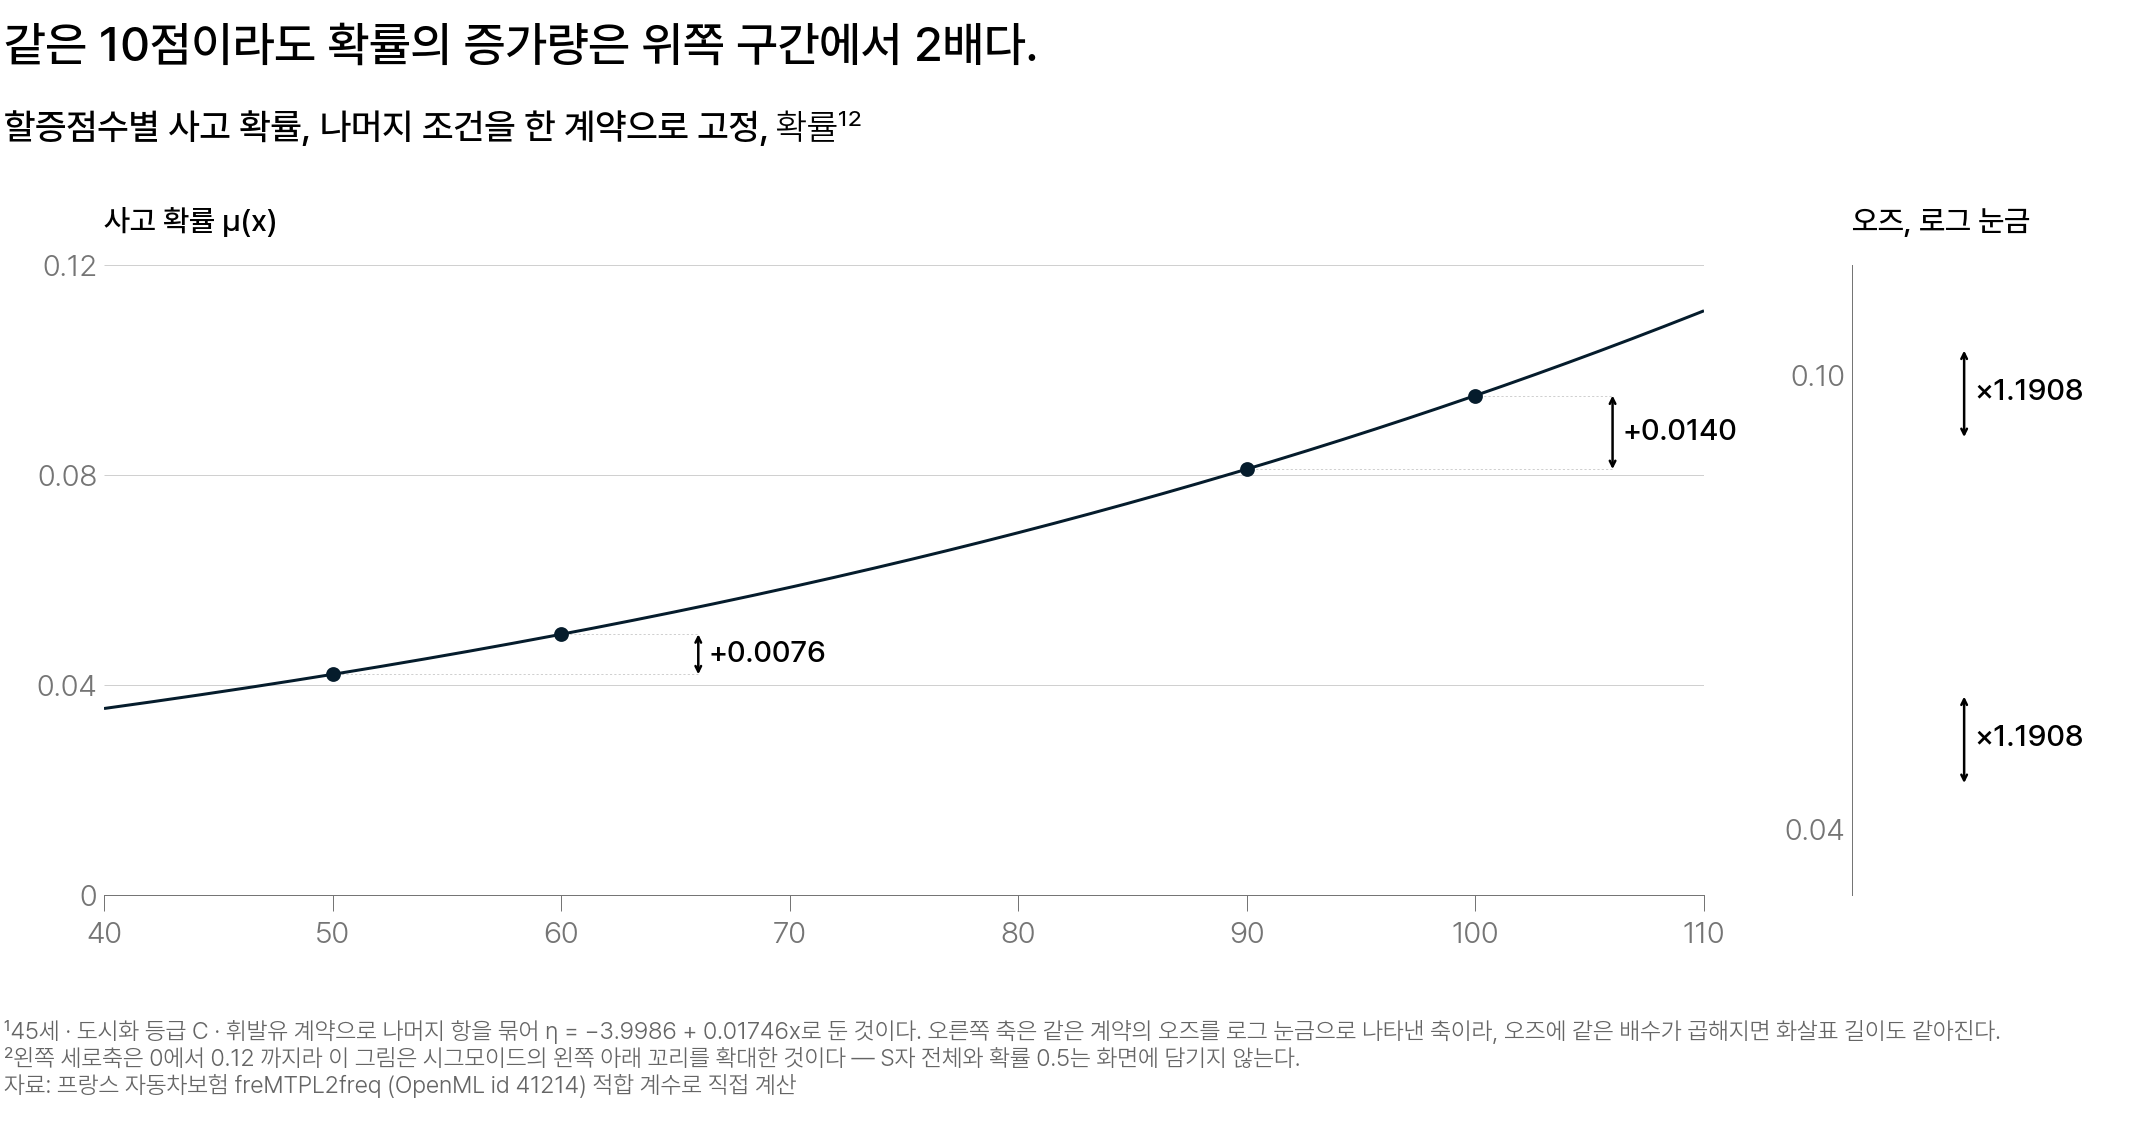

In [ ]:
# 도해 생성 코드는 LMS 에서만 실행됩니다

<p align="center"><em>▲ 오즈는 같은 배수, 확률은 다른 증가량 — 왼쪽 50 → 60 구간은 확률이 +0.0076 오르고 90 → 100 구간은 +0.0140 오르는데, 오른쪽 오즈 세로축은 로그 눈금이라 구간 2개의 화살표 길이가 ×1.1908 로 같다</em></p>

**확률의 비**로 계산해도 1.1908 이 아닙니다 — 50 → 60 은 $4.97 / 4.21 = 1.181$ 배, 90 → 100 은 $9.51 / 8.11 = 1.173$ 배로 위치마다 다릅니다.

**그래서** 보고서에서는 **"오즈가 1.19배가 된다"** 는 맞고 **"사고 확률이 19% 높아진다"** 는 틀립니다.

## 모형이 산출한 확률의 확인 2가지

모형이 산출한 확률이 쓸 만한지는 2가지로 봅니다.

- **순서** — 사고를 겪은 계약에 더 높은 확률을 매겼는가
- **크기** — 모형이 7% 로 산출한 계약들 중에서 실제로 7% 정도가 사고를 겪었는가

**보정(calibration)** — 뒤쪽, 곧 산출한 확률의 크기가 실제 비율과 맞는지 확인하는 일입니다. 오늘 「보정」이라 부르는 일은 이것 말고도 2개(노출로 나눠 연 단위로 고치는 일 · 함께 넣은 변수를 고정한 효과) 더 있습니다. 두 지표를 실제로 계산하는 일은 내일 잔차와 함께 합니다.

#### 핵심 주의점

오즈비 1.018 을 「사고 확률이 1.8% 높아진다」로 해석하면 안 됩니다.

$$
\frac{\text{오즈}(x_1 + 1)}{\text{오즈}(x_1)} = e^{\beta_1}
$$

지수를 씌운 값이 곱해지는 대상은 확률이 아니라 오즈라, 같은 배수라도 확률이 증가하는 양은 기준 확률마다 다릅니다.

> **할증점수가 1점 오르면 사고를 겪을 오즈에 1.018 이 곱해지고, 그 배수를 확률로 옮기려면 어느 계약을 기준으로 삼았는지를 함께 말해야 한다.**

> **[문제] 표에 없는 계약 2건의 확률 차이와 오즈비**
>
> 방금 실행한 표에는 없는 계약 2건 — 할증점수 55점과 75점 — 을 $\beta = 0.01746$, $\eta_0 = -3.9986$ 으로 직접 계산해 보세요. 20점 차이라 표의 10점 행을 그대로 옮겨 적을 수는 없습니다. 두 계약의 사고 확률 차이와 오즈비를 함께 옳게 적은 것은 어느 쪽입니까?
>
> 1. 확률 차이 $+0.0152$ · 오즈비 1.4179 — 10점 행의 $+0.0076$ 을 두 번 더하면 20점 증가량이다
> 2. 확률 차이 $+0.0179$ · 오즈비 1.4179 — 확률은 기준마다 다시 계산하고, 오즈는 1.1908 을 두 번 곱한다
> 3. 확률 차이 $+0.0179$ · 오즈비 2.3816 — 10점당 1.1908 이니 20점이면 그 두 배다
> 4. 확률 차이 $+0.0179$ · 오즈비 1.3913 — 확률이 오른 배수가 곧 오즈비다

## 4. 포아송 회귀와 노출 보정

## 여부가 아니라 건수를 집계해야 할 때

우리의 실제 타깃은 사고 여부가 아니라 사고 **건수** 였습니다. 그런데 앞의 모형은 2회 겪은 계약과 1회 겪은 계약을 똑같이 "겪음" 으로 처리했고, 3개월만 관찰한 계약과 1년을 관찰한 계약의 사고 1건에 같은 가중치를 적용했습니다. 여기서 둘 다 고칩니다.

**여기서 할 일**

1. 타깃을 사고 **건수**로 바꾸고 포아송 분포에 로그 링크를 적용합니다.
2. 계약마다 다른 관찰 기간을 계수가 1인 항, 곧 **오프셋**으로 더합니다.
3. 할증점수의 배수를 노출을 무시했을 때와 비교합니다.

결함 2개를 숫자로 적으면 이렇습니다 — 2회 겪은 사고를 하나로 처리해 사고 36,056건 중 1,996건이 반영되지 않았고, 관찰 기간(노출 중앙값 0.49년)을 넣을 항이 없었습니다.

**포아송 회귀(Poisson regression)** — 건수 데이터의 평균 $\mu$ 를 설명변수로 만드는 GLM 입니다. 분포는 포아송, 링크는 로그입니다.

<img src="https://en.wikipedia.org/wiki/Special:FilePath/Poisson_pmf.svg" width="640" height="495"/>
<p align="center"><em>▲ 포아송 분포의 확률질량함수 — λ 는 그림의 표기이고, 우리 표기로는 평균 건수 μ 다. 그 값이 1(주황)·4(자주)·10(하늘)로 커지면 최빈값이 0·1 에서 9·10 으로 이동하고 최댓값은 0.37에서 0.13으로 낮아진다 — 평균이 커지는 만큼 산포도 함께 커진다 (출처: Wikipedia)</em></p>

어제는 계약 전체에 사고율 하나를 매겼습니다. 오늘은 **계약마다 다른 $\mu_i$** 를 설명변수로 만들어 내고, 그 $\mu_i$ 안에 할증점수·나이·지역이 각각의 항으로 들어갑니다.

## 왜 로그 링크인가 — 역할 2개

기대 사고 건수 $\mu_i$ 에 직선을 그대로 대응시키지 않고, **로그를 씌운 뒤** 직선과 연결합니다.

$$
\log \mu_i = \eta_i = \beta_0 + \beta_1 x_{i1} + \cdots
$$

이 한 줄이 하는 일은 2가지입니다.

**역할 1 — 평균이 음수가 되지 않습니다.** 직선을 그대로 두면 값이 0 아래로 내려갑니다. $\beta_0 = 0.5$, $\beta_1 = -0.02$ 라면 $x_i = 25$ 에서 $0.5 - 0.02 \times 25 = 0$ 이고, 25 를 넘는 순간 평균 사고 건수가 음수가 됩니다. 위 식을 역변환하면 $\mu_i = e^{\eta_i}$ 인데 지수는 어떤 값을 넣어도 양수라 이 문제가 사라집니다.

**역할 2 — 곱셈이 덧셈이 됩니다.** 지수의 덧셈은 곱셈으로 분해되므로($e^{a+b} = e^a \cdot e^b$) 역변환한 오른쪽은 배율의 곱이 됩니다.

$$
\mu_i = e^{\beta_0} \cdot e^{\beta_1 x_{i1}} \cdots
$$

말로 하면 "각 변수가 기본 기대 건수 $e^{\beta_0}$ 에 자기 배율을 곱한다" 입니다. "기본 요율 × 지역 × 연령 × 할증 계수" 로 적는 요율표가 바로 이 모양입니다.

<img src="https://bookdown.org/roback/bookdown-BeyondMLR/bookdown-BeyondMLR_files/figure-html/ageXnhouse-1.png" width="640" height="457"/>
<p align="center"><em>▲ 필리핀 가계조사 — 가로축은 가구주 나이, 세로축은 가구원 수 평균에 로그를 씌운 값이다. 세로축이 이미 로그인데도 곡선은 47세 부근의 1.45(가구원 약 4.3명)를 최댓값으로 양쪽이 감소한다 — 위로 볼록한 곡선이라 직선 하나로는 표현할 수 없다 (출처: Roback & Legler, Beyond MLR)</em></p>

로그를 씌워도 관계가 저절로 직선이 되지는 않는다는 사례입니다. 이 데이터의 나이도 조건이 비슷해 뒤(6. 실제 데이터 적용)에서 구간으로 나눠 다시 다룹니다.

#### 계수는 더해지는 양이 아니라 곱해지는 배수

그래서 $x$ 가 1 오를 때 평균에 일어나는 일은 덧셈이 아니라 곱셈입니다.

$$\frac{\mu(x+1)}{\mu(x)} = e^{\beta_1}$$

- $\mu(x)$ : 설명변수가 $x$ 인 계약의 평균 · $\mu(x+1)$ : 나머지 조건은 그대로 두고 $x$ 만 1 올린 계약의 평균

말로 하면 "로그 스케일에서의 덧셈이 원래 단위에서는 곱셈이 된다" 입니다. 일정한 것은 **차이가 아니라 비**입니다. 값 2쌍을 표로 놓으면 그대로 보입니다.

| 평균 $\mu$ | 로그 $\log \mu$ | 올린 평균 | 그 로그 | 로그의 차 | 원래 단위의 비 |
|---|---|---|---|---|---|
| 1 | 0 | 2 | 0.693 | 0.693 | 2배 |
| 10 | 2.303 | 20 | 2.996 | 0.693 | 2배 |

더해지는 양은 1 과 10 으로 다른데 로그 스케일에서는 둘 다 0.693 으로 같고, 그 지수 $e^{0.693} = 2.00$ 이 원래 단위의 배수입니다.

**사고율비(rate ratio)** — 설명변수가 1 오를 때 곱해지는 배수 $e^{\beta}$ 입니다. '율'이라는 이름이 정확해지는 것은 노출을 넣은 뒤입니다.

> **[문제] 링크함수가 하는 일**
>
> 2. GLM 의 구성요소에서 본 그림 3(로그 역함수: 기대 사고 건수)의 곡선은 $\mu = e^{0.5 + 1.2x}$ 였고, 그 그림의 속 빈 원이 $x = 1.5$ 위치의 $\mu = 9.97$ 을 이미 적어 두었습니다. (1) 거기에 이어 $x = 2.5$ 에서 $\mu$ 를 계산하고 두 값의 비를 구하세요. (2) 시작 위치를 옮겨 $x = 0.5$ 에서 $x = 1.5$ 로 갈 때의 비도 구해 (1)의 값과 비교하세요. (3) 로그 링크에서 "로그 스케일에서의 덧셈이 원래 단위에서는 곱셈이 된다"고 말하는 이유를 (1)(2)의 값과 연결해 한 문장으로 정리해 보세요 — 어디에 $\beta_1$ 이 더해지고 어디에 $e^{\beta_1}$ 이 곱해지는지를 밝혀 적으십시오.

## 오프셋 — 관찰 기간을 넣는 항

요율에 쓸 것은 기대 건수가 아니라 **연 단위 사고율**이라, 기대 건수를 관찰 기간과 사고율의 곱으로 분해합니다.

$$
\mu_i = E_i \cdot \lambda_i \qquad\Longrightarrow\qquad \log \mu_i = \log E_i + \beta_0 + \beta_1 x_{i1} + \cdots
$$

- $\mu_i$ : 기대되는 사고 **건수** — 앞에서 정의한 평균 $\mu$ 그대로입니다
- $E_i$ : **노출(exposure)** — 그 계약을 관찰한 기간, 단위는 년
- $\lambda_i$ : **연간 사고율** $\exp(\beta_0 + \beta_1 x_{i1} + \cdots)$ — 알고 싶은 값이고, 어제 0.1006건/년을 계산했던 그 기호입니다

기호 하나를 구분해 둡니다. 여기 쓴 $E_i$ 는 노출 기간이고, 앞에서부터 쓰던 $E[\ \cdot\ ]$ 는 곱하는 값이 아니라 괄호 안을 평균 낸다는 연산 표기입니다. 대괄호의 유무로 구분해 읽으면 됩니다.

작은 예 하나면 바로 보입니다. 계약 A 는 1년을 관찰해 사고 1건, 계약 B 는 3개월(0.25년)만 관찰해 사고 1건입니다. 건수만 보면 둘 다 1건으로 같지만, 연 단위로 고치면 A 는 1건/년이고 B 는 $1 \div 0.25 = 4$건/년입니다. 이 나눗셈을 모형 안에서 대신하는 항이 오프셋입니다.

**오프셋(offset)** — 계수를 1로 고정해 우변에 더하는 항입니다. $\log E_i$ 는 형태가 설명변수와 같은데 계수가 없어서, **추정하는 계수의 개수** $k$ 에도 포함하지 않습니다 — 뒤(5. AIC 와 BIC)에서 패널티 항을 계산하는 그 $k$ 입니다.

**그래서** $e^{\beta_0}$ 가 설명변수 모두 0인 계약의 연간 사고율, $e^{\beta_1}$ 이 거기 곱해지는 배수가 되어 **사고율비**라는 이름이 맞아떨어집니다.

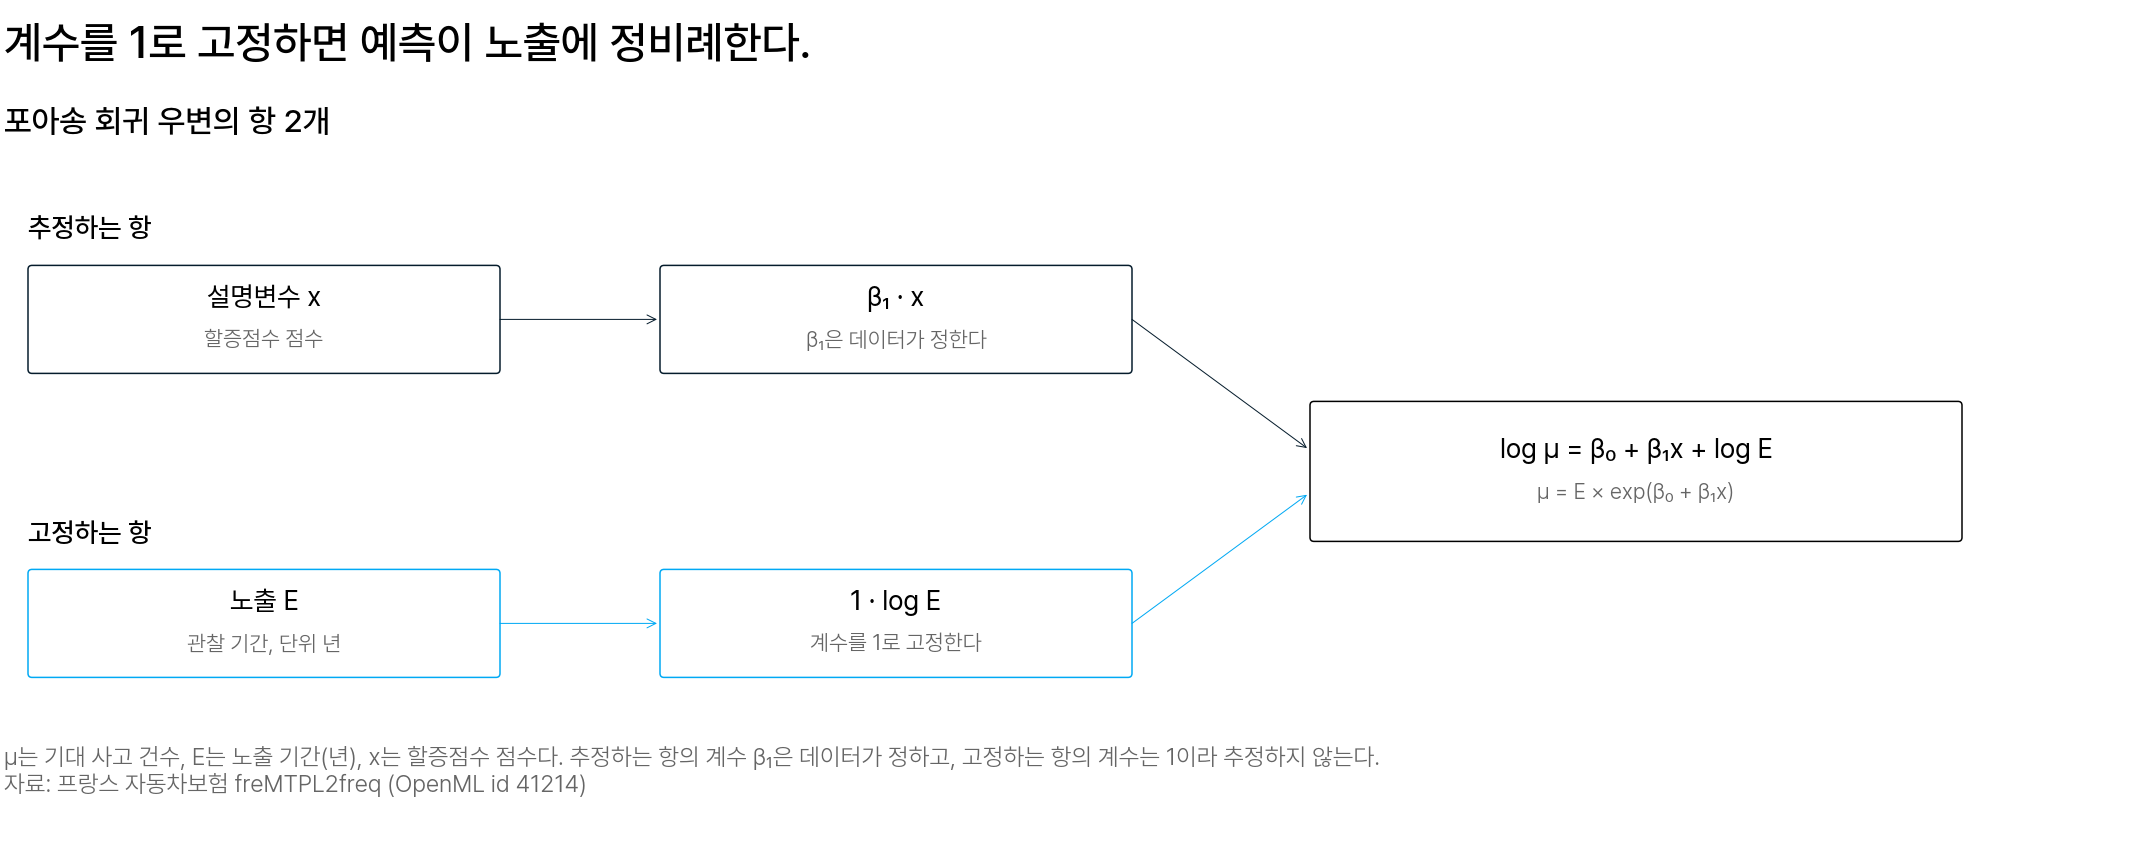

In [ ]:
# 도해 생성 코드는 LMS 에서만 실행됩니다

<p align="center"><em>▲ 포아송 회귀 우변이 나뉘는 항 2개 — 위 남색 쪽은 계수 β₁을 데이터가 정하고, 아래 하늘색 쪽은 계수를 1로 고정한다. 둘은 오른쪽 log μ = β₀ + β₁x + log E 상자에서 합류한다</em></p>

#### 결과 해석

역변환한 `μ = E × exp(β₀ + β₁x)` 에서 **노출이 2배면 기대 건수도 정확히 2배** 입니다. 계수 1 이 이 비례를 지켜 줍니다. 고정하는 항의 `1 · log E` 는 계수가 이미 1 이라 추정 대상이 아니어서, 계수표에도 나오지 않고 계수 개수 $k$ 에도 넣지 않습니다.

계수를 데이터가 정하게 두면 이 데이터는 $\hat{\gamma} = 0.360$ 을 산출하고, 그 순간 비례가 성립하지 않습니다. 노출은 위험의 크기가 아니라 **관찰 구간의 길이**라 데이터로 확인할 값이 아니라 **정의상 1 입니다**.

아래 코드의 `smf.glm(...)` 4개 행이 모형 전부이고, 오프셋은 `offset=` 인자 하나를 차지합니다.

In [ ]:
# 오프셋을 넣은 포아송 GLM — 모형을 만드는 데 필요한 것은 아래 코드 4개 행이 전부고, 뒤 4개 행은 값을 출력하는 것뿐이다
import statsmodels.api as sm
import statsmodels.formula.api as smf

res = smf.glm("ClaimNb ~ BonusMalus + DrivAge + Area + VehGas",   # 체계적 구성요소 η
              data=insurance,                                      # 계약 678,013건
              family=sm.families.Poisson(),                        # 무작위 구성요소 = 포아송
              offset=np.log(insurance["Exposure"])).fit()          # 로그 노출 = 오프셋

print(round(res.params["BonusMalus"], 5))            # 0.02182 — 할증점수 계수
print(round(np.exp(res.params["BonusMalus"]), 4))    # 1.0221 — 사고율비 exp(β)
print(round(res.bse["BonusMalus"], 6))               # 0.000306 — 할증점수 계수의 표준오차
print(round(res.params["BonusMalus"] / res.bse["BonusMalus"], 2))   # 71.29 — z = 추정값 ÷ 표준오차

#### 결과 해석

할증점수 계수는 $\beta = 0.02182$, 사고율비는 $e^{0.02182} = 1.0221$ 입니다. **할증점수가 1점 오르면 그 계약의 연간 사고율에 1.0221 이 곱해진다** — 요율표로는 "1점당 2.21% 할증"입니다.

노출을 넣지 않고 같은 모형을 적합하면 배수가 1.017 로 작아집니다. 할증점수가 높은 계약일수록 관찰 기간이 짧아서(50～55점 0.58년, 80～100점 0.40년), 계약당 건수로 보면 두 구간의 차이가 1.4배인데 노출로 나눈 연간 사고율로 보면 2.1배가 되기 때문입니다. 이 나눗셈만 노출 보정이라 부르겠습니다 — 앞의 확률 크기 확인과는 다른 일입니다.

**z** — 추정값을 그 표준오차로 나눈 값입니다. 크기가 2 를 넘으면 그 계수를 0 이 아니라고 봅니다. 방금 실행한 코드의 뒤 2개 행이 그 값입니다 — 표준오차가 0.000306, $z$ 가 71.29 로 기준 2 를 크게 넘으니 "이 계수는 0이 아니다"는 판정이 성립합니다.

방금 실행한 4개 행이 구성요소 3개의 어디에 대응하는지는 아래의 「자세히」에 정리했습니다.

<details class="lms-extra"><summary>자세히 — smf.glm 4개 행과 구성요소 3개의 대응</summary>

물결표 오른쪽에 나열한 변수 4개가 선형예측자 $\eta$ 이고, `family=sm.families.Poisson()` 인자 하나가 무작위 구성요소입니다. 링크는 그 괄호 안 `link=` 인자인데, 로그가 정준 링크라 기본값이어서 비워 두었습니다. 마지막 `offset=` 이 계수가 1인 항이고, 노출 그대로가 아니라 **로그를 씌운 값**을 전달한다는 점만 주의하면 됩니다.

</details>

본문이 인용한 1.017 과 0.360 은 인자 하나만 바꿔 다시 적합한 값입니다. 아래 코드가 인자 하나씩만 바꿔 그 두 값을 출력합니다.

In [ ]:
# 첫째: 오프셋을 뺀다 — offset= 인자가 없는 포아송 + 로그
res_noff = smf.glm("ClaimNb ~ BonusMalus + DrivAge + Area + VehGas",
                   data=insurance, family=sm.families.Poisson()).fit()
print(round(res_noff.params["BonusMalus"], 5))
print(round(np.exp(res_noff.params["BonusMalus"]), 4))

# 둘째: log E 를 오프셋이 아니라 설명변수로 넣는다 — 계수를 데이터가 정하게 둔다
insurance["logE"] = np.log(insurance["Exposure"])
res_free = smf.glm("ClaimNb ~ BonusMalus + DrivAge + Area + VehGas + logE",
                   data=insurance, family=sm.families.Poisson()).fit()
print(round(res_free.params["logE"], 4))
print(res_free.conf_int().loc["logE"].round(4).tolist())

#### 결과 해석

첫 행 0.01704 가 노출을 넣기 전의 할증점수 계수, 둘째 행 1.0172 가 그 배수입니다. 셋째 행 0.3601 은 $\log E$ 의 계수를 추정하게 했을 때의 $\hat{\gamma}$, 넷째 행은 그 95% 신뢰구간입니다.

#### 노출을 제외했을 때의 오차 크기

계약 8건인 예제로 계산하면 답이 나옵니다.

> **[예측] 노출이 계약마다 다른 계약 8건에서, 노출을 무시하고 계약 수로 나눈 사고율은 노출로 보정한 값과 비교하면 어떻게 됩니까?**
>
> 1. 노출 보정값보다 작게 나온다
> 2. 노출 보정값보다 크게 나온다
> 3. 거의 같다
>
> 답을 정한 뒤 아래를 읽어 보세요(정답 채점은 없습니다).

In [ ]:
# 노출을 무시한 사고율 vs 노출로 보정한 사고율 - 그리고 격자로 확인
import numpy as np

E = np.array([1.00, 1.00, 0.50, 0.25, 0.75, 1.00, 0.10, 0.40])   # 노출(년)
y = np.array([0,    1,    0,    1,    0,    1,    0,    0])       # 사고 건수

naive = y.sum() / len(y)          # 계약 수로 나눈 값 - 노출을 무시한 계산
adj = y.sum() / E.sum()           # 노출 합으로 나눈 값 - 연간 사고율
print(f"사고 {y.sum()}건 · 계약 {len(y)}건 · 노출 합 {E.sum():.2f}년")
print(f"계약 수로 나눈 값 : {naive:.4f} 건/계약")
print(f"노출로 보정한 값  : {adj:.4f} 건/년")
print(f"두 값의 비        : {adj / naive:.3f} 배")
print(f"평균 노출         : {E.mean():.4f} 년  (= 노출 합 {E.sum():.2f}년 / 계약 {len(y)}건)")
print()

# 오프셋을 넣은 포아송 로그우도를 격자로 최대화해 본다 (상수항 -log y! 는 생략)
grid = np.linspace(0.05, 1.50, 1451)
loglik = np.array([np.sum(y * np.log(g * E) - g * E) for g in grid])
print(f"격자 최댓값 위치  : {grid[loglik.argmax()]:.4f}")
print(f"공식 sum(y)/sum(E): {adj:.4f}")

#### 결과 해석

예측 질문의 답은 첫 번째입니다 — 계약 수로 나누면 **0.3750 건/계약**, 노출 합으로 나누면 **0.6000 건/년**, 두 값의 비는 **1.600배**입니다.

$$
\frac{\left(\sum_i y_i\right) / n}{\left(\sum_i y_i\right) / \sum_i E_i} = \frac{\sum_i E_i}{n} = \bar{E}
$$

- $y_i$ · $E_i$ : $i$번째 계약의 사고 건수와 노출(년) · $n$ : 계약 수 · $\bar{E}$ : 평균 노출

사고 합이 약분되니 **두 값의 비는 사고 건수와 무관하게 평균 노출 하나로 정해집니다** — 여기서는 $\bar{E} = 5.00 / 8 = 0.625$ 년이라 역수가 1.600 입니다.

후보값을 0.05 부터 1.50 까지 일정한 간격으로 늘어놓고 하나씩 로그우도를 계산하는 방법을 **격자 탐색**이라 하는데, 그렇게 찾은 최댓값의 위치 **0.6000** 도 같은 값입니다. 설명변수를 하나도 넣지 않고 로그 노출을 오프셋으로 둔 모형에서는 다음 등식이 성립합니다.

$$
\hat{\lambda} = e^{\hat{\beta}_0} = \frac{\sum_i y_i}{\sum_i E_i}
$$

계약 8건인 이 예제에서는 그 값이 0.6000건/년이고, 계약 678,013건 전체에서는 어제 계산한 **0.1006건/년**입니다. 첫날 포아송의 최대우도추정값이 표본평균이었던 것이 오프셋을 넣으면서 이렇게 확장된 것입니다.

<details class="lms-extra"><summary>자세히 — 계수가 1일 때만 약분되는 계산</summary>

**⑴ 두 값을 나눕니다.** 계약당 건수를 연간 사고율로 나누는 것이라 뒤쪽 분수의 역수를 곱하고, 분자와 분모에 함께 있는 $\sum_i y_i$ 를 약분하면 평균 노출 $\bar{E}$ 만 남습니다.

$$
\frac{\sum_i y_i}{n} \times \frac{\sum_i E_i}{\sum_i y_i} = \frac{\sum_i E_i}{n} = \bar{E}
$$

**⑵ 숫자로 검산합니다.** $0.3750 \div 0.6000 = 0.625$ 이고 $5.00 / 8 = 0.625$ 년이라 같은 값입니다. 계약 678,013건에서도 계약당 평균 0.0532건, 노출 보정 0.1006건/년이라 $0.1006 / 0.0532 = 1.89$ 배이고, 평균 노출 0.53년에서 $1 / 0.53 = 1.89$ 로 역수끼리 맞습니다.

**⑶ 이 약분은 계수가 1일 때만 성립합니다.** $\log E$ 를 오프셋에서 빼내 설명변수로 넣고 계수 $\gamma$ 를 데이터가 정하게 두면, 이 데이터는 $\hat{\gamma} = 0.360$ 을 산출합니다(95% 신뢰구간 0.348～0.372). 처음 식 $\log \mu = \gamma \log E + \beta_0 + \beta_1 x$ 의 양변에 지수를 씌우고 덧셈을 곱셈으로 분해하면($e^{a+b} = e^a \cdot e^b$), 로그 앞의 계수 $\gamma$ 가 밑의 지수로 이동해 $e^{\gamma \log E} = E^{\gamma}$ 가 됩니다.

$$
\mu = E^{\gamma} \cdot e^{\beta_0 + \beta_1 x}
$$

$\gamma = 0.360$ 이면 노출이 2배가 되어도 기대 건수는 $2^{0.360} = 1.28$ 배뿐이고, $\gamma = 1$ 이어야 "2배면 2배"가 지켜집니다.

**⑷ 1 보다 훨씬 작게 추정되는 이유.** 이 데이터에서는 짧게 관찰된 계약이 더 위험합니다(노출 0.25년 이하 0.285건/년, 1년 0.070건/년). 계수를 추정하게 하면 $\gamma$ 가 그 '짧을수록 위험하다'까지 함께 설명하게 되므로 1 아래로 내려갑니다.

**그래서** 신뢰구간이 전부 1 아래에 있는데도 그 값을 그대로 사용하지 않습니다 — $\gamma$ 가 측정하는 것이 관측 구간의 길이가 아니라 거기에 섞인 위험이기 때문입니다.

</details>

### [직접 해보기] 절편과 기울기가 만드는 지수 평균곡선

데이터는 할인율에 따른 클릭 수입니다(관측 80건).

1. **해 보기.** `절편 β₀` 와 `기울기 β₁` 슬라이더를 움직여 보세요.
2. **관찰.** 평균 곡선 $\exp(\beta_0 + \beta_1 x)$ 는 앞의 S곡선과 달리 위로 한계 없이 증가합니다. 점구름 한가운데를 지나면 값 표시란 맨 아래 행에 `데이터와 가장 잘 맞는 조합! (= MLE)` 이 표시됩니다.
3. **확인 질문.** 기울기 $\beta_1$ 을 0으로 두면 곡선은 어떤 형태가 됩니까?

In [ ]:
# 인터랙티브 위젯 — 셀을 실행하면 나타납니다 (인터넷 연결 필요)
# 아래가 잘려 보이면 height 값을 키우세요.
from IPython.display import IFrame
IFrame("https://aic-data.aiffel.io/api/widget-file/advanced-statistics/poisreg-lab.html", width=980, height=520)

<details class="lms-answer"><summary>답 확인 — 기울기 β₁ = 0 일 때 평균 곡선의 형태</summary>

가로로 눕는 **가로선**이 됩니다. $\beta_1 = 0$ 이면 $\exp(\beta_0 + 0 \cdot x) = e^{\beta_0}$ 이라 $x$ 와 무관한 상수가 되기 때문입니다.

이 가로선이 곧 절편만 둔 모형, "모든 계약에 같은 사고율을 매기는" 어제의 답이고, 「5. AIC 와 BIC — 적합 부족과 패널티 항」에서 다룰 null 모형이 정확히 이것입니다. 이 위젯의 `기울기 β₁` 슬라이더는 `β₁ 0.000~0.060` 구간이라 음수로 내려가지 않지만, $\exp$ 는 어떤 값을 대입해도 양수라 $\beta_1$ 이 음수여도 곡선은 0 아래로 내려가지 않습니다.

</details>

## 포아송 회귀로 바꿀 때 달라지는 것

앞의 로지스틱과 여기 포아송이 계약마다 산출한 예측값이 어디부터 어디까지 퍼져 있는지 한 장으로 봅니다.

<img src="https://scikit-learn.org/stable/_images/sphx_glr_plot_poisson_regression_non_normal_loss_002.png" width="640" height="240"/>
<p align="center"><em>▲ 같은 freMTPL2freq 데이터에 여러 모형을 맞춘 뒤 비교한 예측 분포 — Ridge 의 예측은 0.6 까지에 그치고 포아송은 1.6 까지 분포하니, 분포와 링크를 바꾸면 예측의 범위부터 넓어진다. 맨 왼쪽 막대가 0 왼쪽까지 나온 것은 히스토그램 구간의 왼쪽 끝이 −0.2 여서이지 예측이 음수라는 표시가 아니다 (출처: scikit-learn documentation)</em></p>

가로 4개 열은 왼쪽부터 실제 관측 · Ridge · 포아송 · 부스팅이고, 세로 2개 행은 위가 훈련 표본, 아래가 시험 표본입니다. 넷째 열의 부스팅은 GLM 이 아니라 참고로만 둡니다.

요율은 예측값을 금액으로 옮기는 일이라 이 범위가 곧 금액 차이입니다. **그래서** 위험한 계약에 더 높은 값을 매길 여지가 남는 쪽은 포아송입니다.

#### 핵심 주의점

계약당 평균 사고 건수 0.3750 을 연간 사고율처럼 해석하면 안 됩니다.

$$
\hat{\lambda} = \frac{\sum_i y_i}{\sum_i E_i}
$$

분모에 들어갈 것은 계약 수 $n$ 이 아니라 노출 합 $\sum_i E_i$ 라, 계약 수로 나눈 값은 평균 노출 $\bar{E}$ 배만큼 낮게 나옵니다.

> **노출 합 5.00년 동안 사고가 3건이므로 연간 사고율은 0.3750 건/계약이 아니라 0.6000 건/년이다.**

> 사고율은 건수 ÷ 시간인데, 그 나눗셈을 모형 안에서 대신해 주는 항이 계수를 1로 고정한 오프셋입니다.

설명변수가 4개뿐인 이 모형에 차량 브랜드나 지역까지 넣으면 어떻게 됩니까. 적합도만 보면 변수를 더 넣은 모형이 나빠지는 일이 없어서 '더 잘 맞는다' 만으로는 고를 수 없습니다.

> **[문제] 오프셋의 계수를 1로 고정하는 이유**
>
> 앞에서 실행한 계약 8건 예제에서 사고 건수 3건은 그대로 두고 노출만 모두 0.25년으로 바뀌었다고 합시다. (1) 계약 수로 나눈 값과 노출 합으로 나눈 값의 비는 얼마입니까. (2) 그 비가 사고 건수와 무관하게 정해지는 이유를, 오프셋의 계수가 1이라는 사실과 연결해 적어 보세요.

## 5. AIC 와 BIC — 적합 부족과 패널티 항

## 후보가 3개면 어느 것을 요율표에 올리나

앞에서 만든 포아송 회귀에 차량 브랜드와 지역까지 넣으면 모형이 정말 좋아집니까? 요율표에 지역 22개 항목을 더 올릴지 말지를 정하는 일입니다.

**여기서 할 일**

1. 적합만으로 고르면 왜 늘 복잡한 모형이 선택되는지 봅니다.
2. 적합 부족에 패널티 항을 더한 점수 2개 **AIC** 와 **BIC** 를 정의합니다.
3. 모형 3개를 계약 2,000건과 678,013건에 적용해 순위 반전을 확인합니다.

후보 3개를 계약 2,000건으로 적합해 두었습니다. 이 이름을 그대로 씁니다.

- **null** : 절편만 ($k = 1$)
- **핵심(core)** : 나이·할증점수·도시화 등급·연료 4개 ($k = 9$) — 앞에서 적합한 그 모형입니다
- **확장(full)** : 거기에 차량 브랜드·인구밀도·지역까지 ($k = 41$)

$k$ 는 추정한 계수의 개수입니다 — 변수가 4개인 핵심 모형이 왜 9 인지는 뒤에서 따로 계산합니다.

## 「더 잘 맞는 것을 고르면 되지 않나」

가장 먼저 떠오르는 기준은 적합입니다. 그런데 **변수를 넣으면 로그우도는 항상 커집니다** — 새 변수에 설명력이 없어도 그 계수를 0 에 가깝게 두면 되니 적합이 나빠질 일이 없습니다.

<img src="https://scikit-learn.org/stable/_images/sphx_glr_plot_underfitting_overfitting_001.png" width="640" height="229"/>
<p align="center"><em>▲ 그림 1(왼쪽 1차)·그림 2(가운데 4차)·그림 3(오른쪽 15차) — 코사인 참 함수에 잡음을 더해 만든 인공 표본에 차수를 올려 가며 맞춘 곡선이다. 제목의 MSE 가 그림 2 에서 4.32e−02 로 가장 낮고 그림 3 에서는 1.83e+08 로 급증하니, 점들을 더 잘 지난다고 더 나은 모형이 아니다 (출처: scikit-learn documentation)</em></p>

범례의 Model 이 맞춘 곡선인 파랑, True function 이 참 함수인 주황입니다. 그림 3 의 파란 선은 점들의 작은 흔들림까지 따라가다 양 끝에서 참 함수를 크게 벗어납니다.

**과적합(overfitting)** — 모형이 신호가 아니라 잡음까지 배운 상태입니다. 배운 잡음은 새 데이터에서 다시 나오지 않으니, 그림 3 은 지금 데이터에서 가장 잘 맞고 새 계약에서 가장 많이 틀립니다.

**그래서** 「더 잘 맞는다」 만으로는 고를 수 없습니다. 적합에서 얻은 이득을 복잡해진 만큼 상쇄하는 잣대가 필요합니다.

## 점수 = 적합 부족 + 패널티 항

그 잣대는 점수를 둘로 나눠 더하는 것입니다 — 얼마나 안 맞는가에, 계수를 몇 개 썼는가를 더합니다. 그렇게 만든 첫 점수가 **AIC**(Akaike information criterion) 입니다.

$$
\text{AIC} = -2\ell + 2k
$$

- $\ell$ : 최대 로그우도 — 클수록 데이터를 잘 설명합니다
- $-2\ell$ : 부호를 바꿔 **작을수록 좋게** 만든 값, 곧 **적합 부족**입니다
- $k$ : 추정한 계수의 개수 — 절편은 포함하고 오프셋은 포함하지 않습니다

말로 하면 "안 맞는 양에 계수 1개마다 2 를 더한 값" 이고, AIC 도 작을수록 좋습니다.

**패널티 항(penalty term)** — 계수가 늘어난 만큼 점수에 더하는 항입니다. 적합만 보면 계수를 늘릴수록 좋아 보이므로 그 이득을 상쇄합니다.

작은 예로 한 번 계산해 보겠습니다. 후보가 2개인데 로그우도가 −10 과 −8 이고 계수는 1개와 3개라고 합시다. 앞은 $-2 \times (-10) + 2 \times 1 = 22$, 뒤는 $-2 \times (-8) + 2 \times 3 = 22$ 입니다. 적합은 뒤가 4 만큼 좋은데 계수 2개를 더 쓴 값 4 가 그것을 그대로 상쇄했습니다.

계수 1개마다 2 라는 값의 유래도 한 줄로 적어 둡니다. 적합에 쓴 바로 그 데이터로 계산한 로그우도는 계수를 그 데이터에 맞춰 골랐으니 실제보다 높게 나오는데, 아카이케가 계산한 그 부풀림의 크기가 평균 약 $k$ 였습니다. $-2$ 를 곱한 스케일로 옮기면 $2k$ 라, AIC 는 「새 데이터였다면 로그우도가 얼마였을까」 를 지금 표본 하나에서 추정한 점수입니다.

이제 같은 계산을 후보 3개에 그대로 합니다.

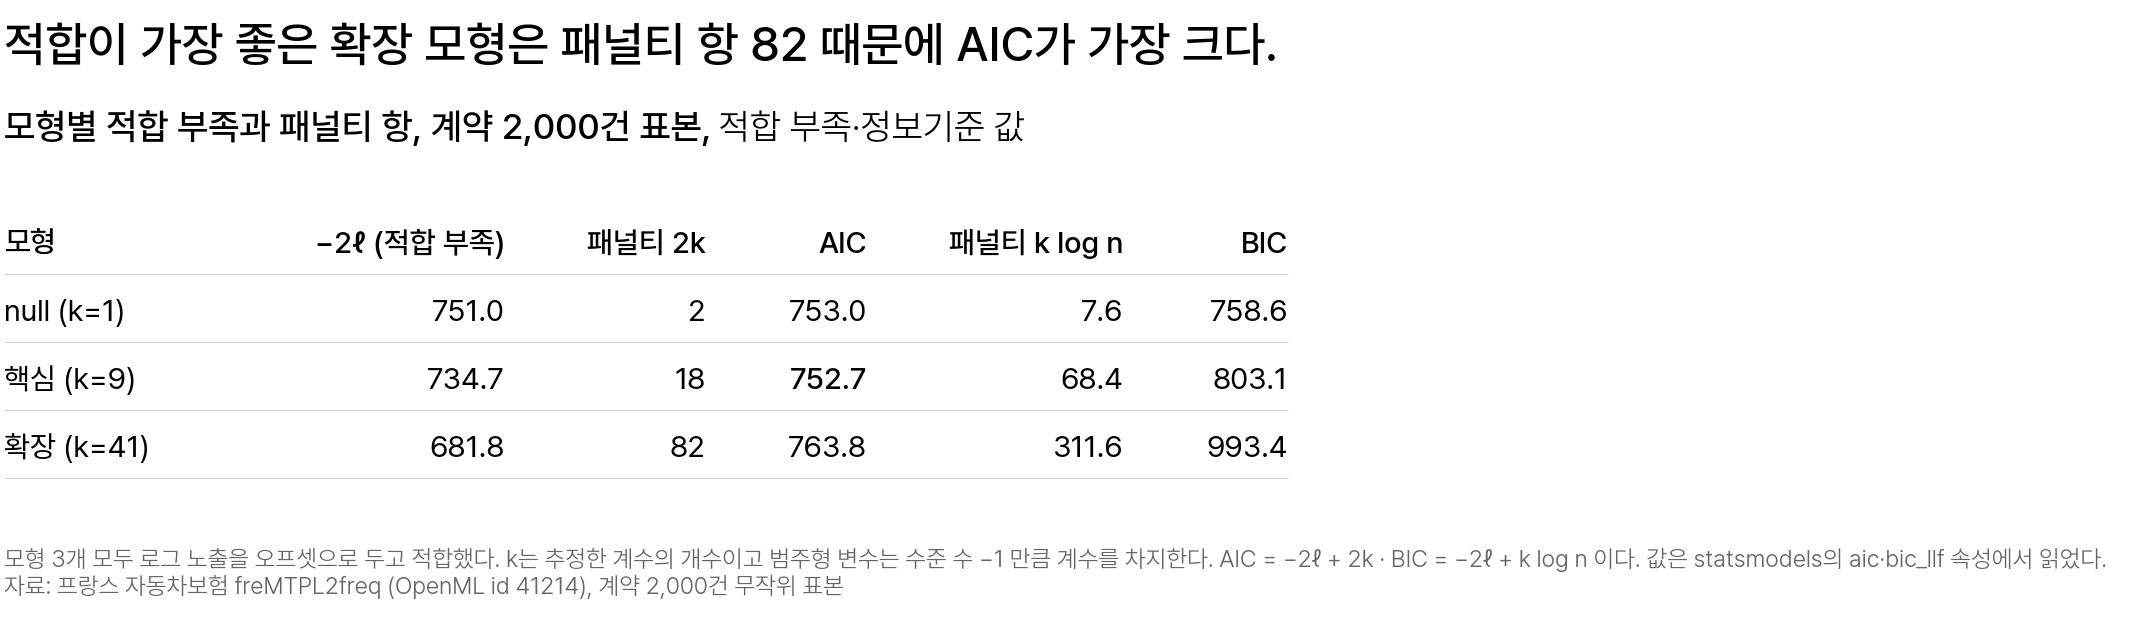

In [ ]:
# 도해 생성 코드는 LMS 에서만 실행됩니다

<p align="center"><em>▲ 모형 3개의 적합 부족과 패널티 항, 계약 2,000건 — −2ℓ 열은 751.0 → 734.7 → 681.8 로 계속 감소하고 패널티 항 2k 열은 2 · 18 · 82 로 증가한다. 둘을 더한 AIC 열이 753.0 · 752.7 · 763.8 이라, −2ℓ 이 가장 작은 것은 확장 모형인데 AIC 가 가장 작은 것은 핵심 모형 752.7 이다</em></p>

#### 결과 해석

확장 모형은 적합에서 52.9 를 얻는 동안 패널티 항이 64 커져, AIC 가 가장 작은 것은 확장이 아니라 핵심 모형 752.7 입니다.

**ΔAIC** — 그 모형의 AIC 에서 가장 작은 AIC 를 뺀 값입니다. 2 미만이면 사실상 동률, 4～7이면 큰 쪽의 근거가 뚜렷이 약함, 10 초과면 후보에서 제외로 읽습니다. 여기서는 null 0.3 · 핵심 0 · 확장 11.1 이라 판정은 「null 과 핵심은 구분되지 않고, 확장은 제외한다」 입니다.

## BIC — 패널티 항만 바꾼 같은 구조

BIC(Bayesian information criterion) 는 구조가 같고 패널티 항만 다릅니다.

$$
\text{BIC} = -2\ell + k \log n
$$

- $n$ : 적합에 쓴 계약 건수 · $\log$ : 밑이 $e$ 인 자연로그
- 계수 1개마다 더하는 값이 2 가 아니라 $\log n$ 입니다 — 계약 2,000건이면 7.6, 678,013건이면 13.4 입니다

같은 표의 오른쪽 2개 열이 그 결과입니다. 패널티 항이 AIC 의 3.8배가 되어 BIC 열은 **758.6** · 803.1 · 993.4 이고, 이번에는 BIC 가 가장 작은 것이 null 입니다.

**점수 2개가 다른 답을 낼 수 있습니다.** AIC 는 새 데이터의 예측 오차가 작은 모형을, BIC 는 **참 모형**(후보 가운데 이 데이터를 실제로 만들어 낸 구조)일 확률이 높은 모형을 고릅니다. 요율표처럼 예측값을 그대로 쓰는 일이면 AIC 쪽을 기준으로 삼습니다.

<details class="lms-extra"><summary>자세히 — 점수 2개의 근거와 ΔBIC 경계값</summary>

AIC 는 표본이 커져도 계수 1개마다 더하는 값이 2 로 고정이라 설명력이 작은 변수도 함께 남고, BIC 는 표본이 커질수록 그 값이 커지니 남은 변수의 근거가 뚜렷해지는 대신 예측에 도움이 되는 변수까지 제거할 수 있습니다.

확장 모형이 null 대비 적합에서 얻은 값은 $751.0 - 681.8 = 69.2$ 인데 늘어난 패널티 항이 $311.6 - 7.6 = 304.0$ 이라, BIC 점수에서는 234.8 을 손해 봤습니다($993.4 - 758.6$). ΔBIC 는 null 0 · 핵심 44.5 · 확장 234.8 이고, 경계값은 2 · 6 · 10 이라 AIC 쪽 2 · 4～7 · 10 보다 한 단계씩 엄격합니다.

</details>

## 표본을 340배로 키우면 순위가 뒤집힌다

열은 그대로 두고 **표본만 340배로** 키워 보겠습니다. AIC 의 패널티 항 $2k$ 는 표본 크기와 무관하게 그대로이고, 계약 678,013건이면 BIC 쪽 $\log n$ 만 7.6 에서 13.4 로 커집니다.

> **[예측] 계약 678,013건 전체로 같은 모형 3개를 적합하면, AIC 가 가장 작은 모형은 어느 쪽입니까?**
>
> 1. 계약 2,000건 때와 같은 핵심 모형
> 2. 적합이 가장 좋은 확장 모형
> 3. 패널티 항이 가장 작은 null 모형
>
> 답을 정한 뒤 아래를 읽어 보세요(정답 채점은 없습니다).

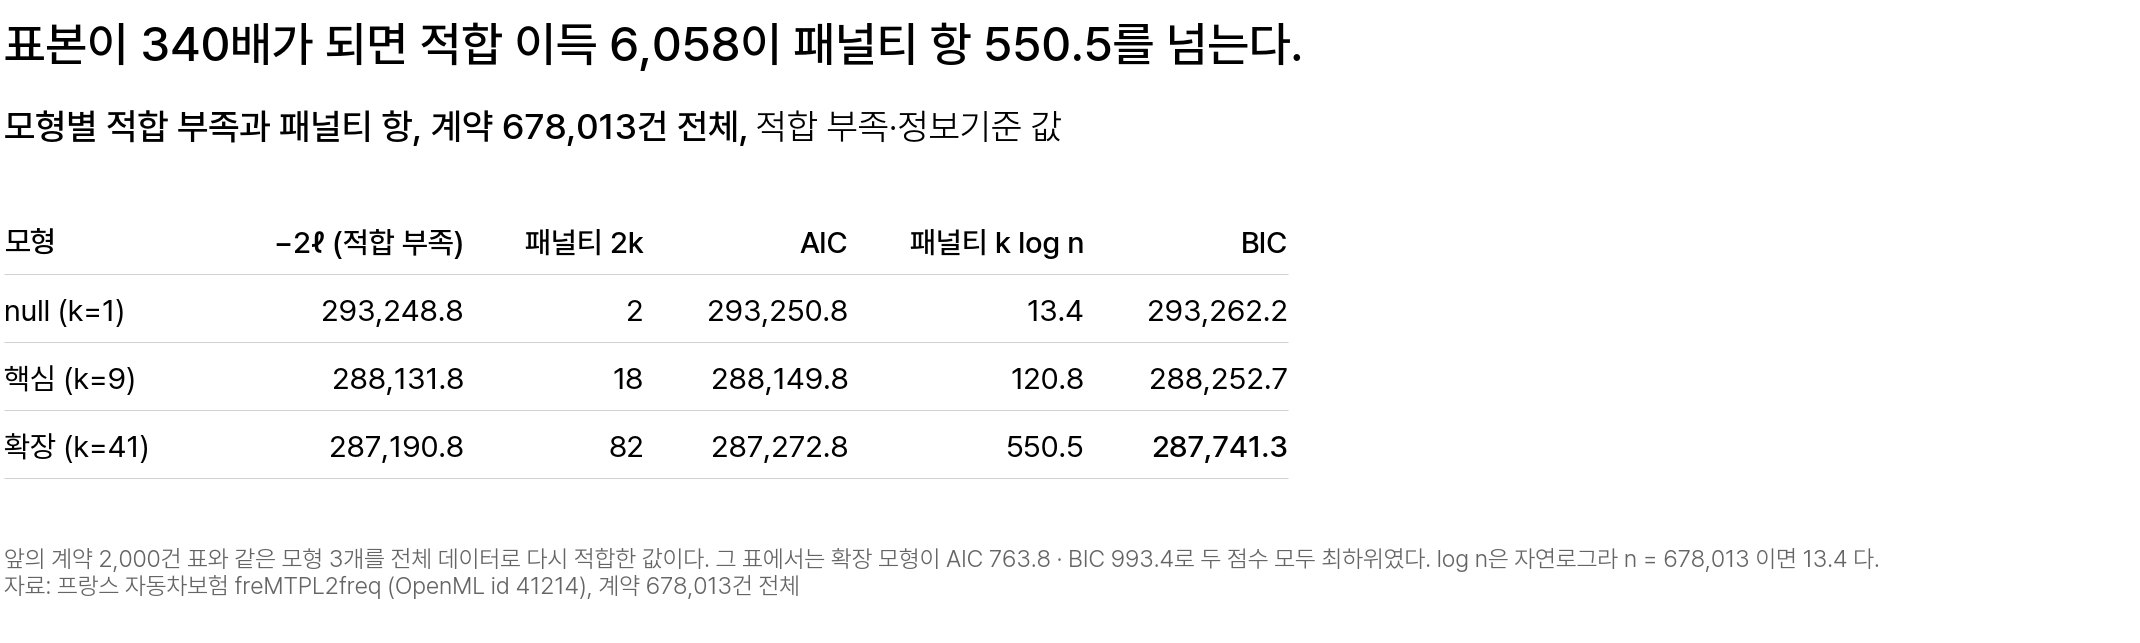

In [ ]:
# 도해 생성 코드는 LMS 에서만 실행됩니다

<p align="center"><em>▲ 같은 모형 3개를 계약 678,013건 전체로 적합한 결과 — AIC 열이 293,250.8 · 288,149.8 · 287,272.8 이고 BIC 열이 293,262.2 · 288,252.7 · 287,741.3 이라, 계약 2,000건에서 두 점수 모두 최하위였던 확장 모형이 이번에는 둘 다 가장 작다</em></p>

#### 결과 해석

예측 질문의 답은 두 번째, 적합이 가장 좋은 확장 모형입니다. AIC 의 패널티 항 $2k$ 는 확장 모형이 계약 2,000건에서나 678,013건에서나 82 로 같은데, **적합에서 얻는 값만 커졌습니다** — null 대비 이득이 69.2 에서 6,058.0 으로 늘었습니다.

**그래서** 「표본이 크면 단순한 쪽이 선택된다」 는 뜻이 아닙니다. 확장 모형이 더한 계수 32개가 이 표본에서는 실제로 적합 이득을 냈습니다.

표본이 340배가 되는 동안 적합 이득은 87배로 커졌는데 $\log n$ 은 1.8배로 커졌을 뿐이라, 순위가 반대가 될 수밖에 없습니다.

## 코드에서 k 를 계산하려면

$k$ 를 계산하려면 용어 3개가 필요합니다.

- **수준(level)** — 범주형 변수가 가질 수 있는 값 하나입니다. 도시화 등급이면 A 부터 F 까지 6개가 그 수준입니다.
- **더미 변수(dummy variable)** — 범주형 변수의 수준 하나를 골라 「그 수준이면 1, 아니면 0」 으로 적은 열입니다. 도시화 등급이 B 인 계약이면 「등급 B」 열에 1, 나머지 등급 열에는 0 이 들어갑니다. 수준이 6개면 이런 열이 기준 범주를 뺀 5개 생기고, 앞의 포아송 회귀 코드에서 `Area` 가 그렇게 처리되었습니다.
- **기준 범주(reference level)** — 더미 열을 따로 만들지 않는 수준 하나입니다. 그 수준의 계약은 모든 더미 열이 0 이라 절편만으로 예측되고, 다른 수준의 계수는 이 수준과의 차이를 뜻합니다. 도시화 등급이면 A, 연료면 경유입니다. 그래서 더미 열은 수준 수보다 1개 적습니다.

그래서 변수가 4개인 핵심 모형의 $k$ 가 9 입니다 — 절편 1 + 나이 1 + 할증점수 1 + 등급 5 + 연료 1 = **9**. 확장 모형은 여기에 브랜드 10 · 인구밀도 로그 1 · 지역 21 을 더해 **41** 입니다.

코드에서 주의할 것은 하나뿐입니다 — **BIC 는 `bic` 가 아니라 `bic_llf` 로 읽습니다.** `bic` 는 **이탈도(deviance)**, 곧 관측값을 하나하나 그대로 맞힌 모형의 로그우도에서 이 모형의 로그우도를 뺀 뒤 2 를 곱한 값으로 계산한 다른 값입니다.

In [ ]:
# 앞 표의 6개 열을 그대로 다시 만든다 — 모형 객체에서 읽는 속성은 llf · aic · bic_llf 3개뿐이다
sub = insurance.sample(n=2000, random_state=0)          # 표를 낸 그 계약 2,000건 표본
off = np.log(sub["Exposure"])                           # 로그 노출 = 오프셋

FORMULAS = {"null": "ClaimNb ~ 1",
            "핵심": "ClaimNb ~ DrivAge + BonusMalus + Area + VehGas",
            "확장": "ClaimNb ~ DrivAge + BonusMalus + Area + VehGas"
                    " + VehBrand + np.log(Density) + Region"}
fits = {name: smf.glm(f, data=sub, family=sm.families.Poisson(), offset=off).fit()
        for name, f in FORMULAS.items()}

for name, m in fits.items():
    k = int(m.df_model + 1)                             # 절편까지 포함한 계수 개수
    print(f"{name} k={k:2d}  -2l={-2 * m.llf:6.1f}  2k={2 * k:3d}"
          f"  AIC={m.aic:6.1f}  klogn={k * np.log(len(sub)):5.1f}"
          f"  BIC={m.bic_llf:6.1f}")
# null k= 1  -2l= 751.0  2k=  2  AIC= 753.0  klogn=  7.6  BIC= 758.6
# 핵심 k= 9  -2l= 734.7  2k= 18  AIC= 752.7  klogn= 68.4  BIC= 803.1
# 확장 k=41  -2l= 681.8  2k= 82  AIC= 763.8  klogn=311.6  BIC= 993.4

best = float(min(m.aic for m in fits.values()))         # 가장 작은 AIC 를 골라 빼면 그것이 ΔAIC 다
print("dAIC:", [round(float(m.aic) - best, 1) for m in fits.values()])   # [0.3, 0.0, 11.0]
print("핵심 모형의 bic 속성:", round(float(fits["핵심"].bic), 1))          # -14571.7 — 이탈도로 계산한 값이라 부호까지 다르다
print("포아송 회귀 res 의 bic 속성:", f"{res.bic:,.1f}")            # -8,884,691.3 — 계약 678,013건, 이것도 이탈도로 계산한 값

#### 결과 해석

출력된 3개 행이 앞 표의 열들을 그대로 담고 있습니다. 모형에서 읽는 속성은 `m.llf`($\ell$) · `m.aic` · `m.bic_llf` 3개뿐이고, 계수 개수는 `m.df_model + 1` 로 계산합니다 — `df_model` 이 절편을 뺀 개수라 1 을 더하는 것이고, 3개 행의 $k$ 가 1 · 9 · 41 이라 본문에서 직접 계산한 값과 같습니다.

마지막 2개 행이 그 주의점입니다 — 핵심 모형에서 `bic_llf` 대신 `bic` 를 읽으면 803.1 이 아니라 $-14{,}571.7$ 이 나옵니다. 이탈도로 계산한 값이라 부호까지 다릅니다. 실습에서 후보 여럿의 AIC·BIC 를 뽑을 때도 이 3개 속성을 그대로 씁니다.

<details class="lms-extra"><summary>자세히 — 「같은 데이터」 가 뜻하는 것과 결측 처리 순서</summary>

'같은 데이터' 는 같은 데이터프레임이 아니라 **적합에 실제로 쓰인 같은 행들**이라는 뜻입니다. 어떤 열에 결측이 있으면 `smf.glm` 은 그 행을 빼고 적합하므로, 모형마다 $n$ 이 달라져 AIC 를 나란히 비교할 수 없게 됩니다.

그래서 순서가 있습니다. 후보를 적합하기 전에 필요한 열의 결측을 먼저 처리해 행을 맞추고, 적합한 뒤 `m.nobs` 를 출력해 모형 3개의 $n$ 이 같은지 확인합니다. 값이 다르면 그 표는 비교표가 아닙니다. 표본을 새로 추출한 값도 마찬가지라, 계약 2,000건을 다른 난수로 뽑으면 모형 3개를 모두 그 표본으로 다시 적합합니다.

</details>

#### 핵심 주의점

AIC 가 조금이라도 낮다는 것만으로 그 모형이 더 낫다고 해석하면 안 됩니다.

$$
\mathrm{AIC} = -2\ell + 2k
$$

AIC 값 자체에는 뜻이 없습니다 — 같은 확장 모형의 AIC 가 2,000건에서 763.8, 678,013건에서 287,272.8 이고, 표본을 다시 뽑으면 또 달라집니다.

> **계약 2,000건에서 ΔAIC 가 null 0.3 · 핵심 0 · 확장 11.1 이므로, 판정은 "null 과 핵심은 구분되지 않고 확장은 제외한다" 이다.**

> AIC·BIC 는 후보들의 **순위**를 매기는 상대 점수이지, 한 모형이 좋은지를 말해 주는 절대 점수가 아닙니다. 고른 모형을 잔차로 확인하는 일은 내일 다룹니다.

> **[문제] 네 번째 모형의 패널티 항 계산과 순위**
>
> 계약 2,000건 표본으로 낸 「모형 3개의 적합 부족과 패널티 항」 표에서, 확장 모형에서 지역 22수준만 빼고 나머지(나이·할증점수·도시화 등급·연료·차량 브랜드·인구밀도 로그)는 그대로 둔 네 번째 모형을 적합했더니 $-2\ell = 716.2$ 가 나왔습니다. (1) 이 모형의 $k$ 를 계산하고, (2) AIC 와 BIC 를 각각 계산한 뒤, (3) 표의 모형 3개와 나란히 놓았을 때 AIC 기준 몇 순위인지·ΔAIC 로 보면 AIC 가 가장 작은 모형과 구분되는지·BIC 로 옮기면 어떻게 되는지를 적어 보세요.

## 6. 실제 데이터 적용 — 계수를 요율 문장으로

## 계수표 한 행을 요율 문장으로

모형을 적합하면 계수표가 한 장 나옵니다. 거기 적힌 숫자 하나를 요율표 문장으로 어떻게 옮깁니까?

**여기서 할 일**

1. 계수 하나에 지수를 씌워 **사고율 배율**로 읽습니다.
2. 범주형 계수가 무엇과 비교한 값인지 확인하고 배율 2개를 곱합니다.
3. 나이 계수가 상식과 반대로 나온 부분을 분석합니다.

여기서 쓰는 모형은 앞의 **핵심 모형**(나이·할증점수·도시화 등급·연료에 로그 노출을 오프셋으로 둔 포아송 회귀)이고, 계약 678,013건에 적용했습니다.

**사고율 배율** — 계수 $\beta$ 에 지수를 씌운 $e^{\beta}$ 입니다. 그 변수만 한 단위 움직였을 때 사고율이 몇 배가 되는지를 말하고, 1.00 이면 차이가 없다는 뜻입니다.

작은 예로 한 행만 직접 옮겨 보겠습니다. 계수표의 할증점수 행 $\beta = 0.02182$ 에 지수를 씌우면 $e^{0.02182} = 1.022$ 이니 요율표 문장은 「할증점수 1점당 2.2% 할증」 이 됩니다. 여기에 95% 신뢰구간을 함께 적는데, 그 구간이 1.00 을 걸치면 「효과 없음」 으로 읽습니다. 계수표의 나머지 행도 같은 방식으로 옮깁니다.

> **[예측] 나이·할증점수·도시화 등급·연료를 함께 넣은 포아송 회귀에서 "운전자 나이 +10년"의 사고율 배율은 어느 쪽으로 나옵니까?**
>
> 1. 1보다 작다 — 나이가 많을수록 사고율이 낮다
> 2. 1에 거의 붙는다 — 나이는 사고율과 무관하다
> 3. 1보다 크다 — 나이가 많을수록 사고율이 높다
>
> 답을 정한 뒤 아래를 읽어 보세요(정답 채점은 없습니다).

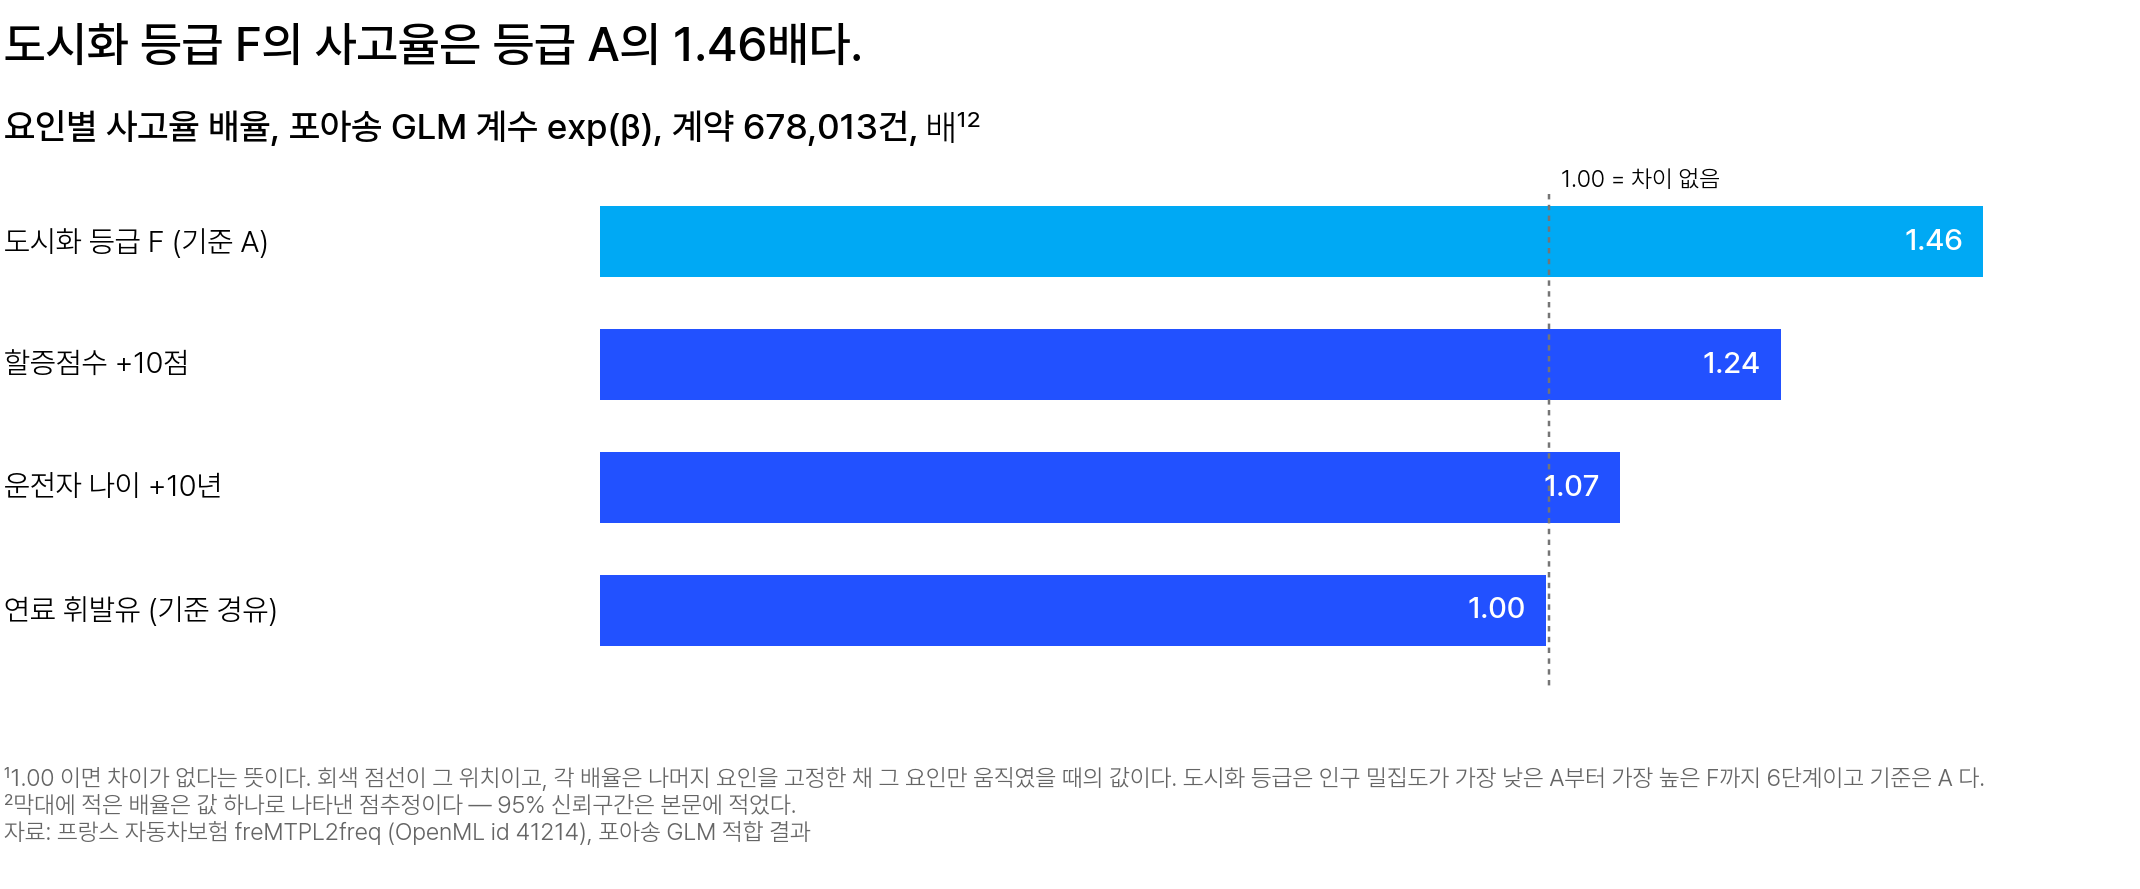

In [ ]:
# 도해 생성 코드는 LMS 에서만 실행됩니다

<p align="center"><em>▲ 요인별 사고율 배율 — 하늘색으로 강조한 도시화 등급 F가 1.46으로 가장 크고, 연료만 1.00으로 회색 점선과 일치한다</em></p>

#### 결과 해석

- **도시화 등급 F 1.46배** — 등급 A 보다 사고율이 45.7% 높다는 뜻이고, 요율표로는 「도시화 등급 F 할증 46%」 입니다.
- **할증점수 +10점 1.24배** — 1점당 1.0221 이라 $1.0221^{10} = 1.244$, 곧 24.4% 할증입니다.
- **연료 1.00배** — 신뢰구간 0.98～1.02 가 회색 점선 1.00 을 포함하는 유일한 막대라, 이 모형에서는 그 계수가 0 이 아니라고 말할 근거가 없습니다. 함께 적합한 변수가 달라지면 이 판정도 달라집니다 — 실습 과제의 차량 정보 모형에서는 같은 연료가 1.10배로 1 을 벗어납니다.
- **운전자 나이 +10년 1.07배** — 예측 질문의 답은 셋째인데, 이 하나는 곱해 쓰기 전에 확인할 것이 있어 뒤에서 다룹니다.

요율표에는 6개 수준이 모두 필요합니다. 같은 모형에서 등급 계수를 읽어 지수를 씌우면 그대로 배율이라, 아래 코드가 기준 A 를 뺀 등급 5개의 배율을 출력합니다.

In [ ]:
import numpy as np
import statsmodels.api as sm
import statsmodels.formula.api as smf

core = smf.glm("ClaimNb ~ DrivAge + BonusMalus + Area + VehGas", data=insurance,
               family=sm.families.Poisson(),
               offset=np.log(insurance["Exposure"])).fit()   # 핵심 모형

for c in "BCDEF":                                # 기준 A 를 뺀 등급 5개
    print(f"도시화 등급 {c} = {np.exp(core.params[f'Area[T.{c}]']):.4f}배")

<details class="lms-extra"><summary>자세히 — 등급 6개 수준을 요율표 한 행으로</summary>

코드가 출력한 5개 행을 소수점 아래 2자리로 반올림해 기준 A 와 함께 표로 옮깁니다.

| 도시화 등급 | A (기준) | B | C | D | E | F |
|---|---|---|---|---|---|---|
| 사고율 배율 | 1.00 | 1.07 | 1.13 | 1.24 | 1.34 | 1.46 |

밀집도가 한 단계 높아질수록 배율도 한 단계씩 증가하고, 감소하는 수준이 하나도 없습니다. 6개 수준을 이 순서 그대로 요율표에 옮겨 써도 된다는 뜻입니다. 배율은 등급이 한 단계 높아질 때마다 5.0～9.4% 증가하고, 5개 단계 평균 증가율은 7.8% 입니다(코드가 출력한 4자리 값으로 계산한 값입니다).

</details>

<details class="lms-extra"><summary>더 깊이 — 배율 4개의 95% 신뢰구간과 기준이 0 이 아니라 1.00 인 이유</summary>

막대에 적은 배율은 점추정 하나입니다. 계수마다 표준오차가 함께 나오니 $\exp(\hat{\beta} \pm 1.96\,\mathrm{SE})$ 로 배율의 95% 신뢰구간이 나옵니다.

| 요인 | 배율 | 95% 신뢰구간 |
|---|---|---|
| 도시화 등급 F (기준 A) | 1.46 | 1.37 ～ 1.55 |
| 할증점수 +10점 | 1.24 | 1.236 ～ 1.251 |
| 운전자 나이 +10년 | 1.07 | 1.066 ～ 1.083 |
| 연료 휘발유 (기준 경유) | 1.00 | 0.98 ～ 1.02 |

표의 둘째 행을 직접 계산해 보겠습니다. 대입할 값은 포아송 회귀를 적합한 코드가 출력한 할증점수 계수 $\hat{\beta} = 0.02182$ 와 그 표준오차 $\mathrm{SE} = 0.000306$ 입니다.

**⑴ 「+10점」에 대응하는 값으로 고칩니다.** 계수와 표준오차에 각각 10 을 곱해 $\hat{\beta} \times 10 = 0.2182$, $\mathrm{SE} \times 10 = 0.00306$ 입니다.

**⑵ 점수 스케일에서 구간을 계산하고 양 끝에 지수를 씌웁니다.** $0.2182 \pm 1.96 \times 0.00306$ 이 0.2122 부터 0.2242 까지이고, $e^{0.2122} = 1.236$ · $e^{0.2242} = 1.251$ 이라 표에 적은 값과 같습니다. 가운데 점추정 $e^{0.2182} = 1.244$ 가 막대에 적힌 1.24 입니다.

구간을 읽는 기준은 0 이 아니라 **1.00**, 곧 그림의 회색 점선입니다. 계수 그대로는 "효과 없음"이 $\beta = 0$ 인데, 지수를 씌워 배율로 역변환하면 $e^{0} = 1$ 이 그 기준이 되기 때문입니다.

</details>

## 범주 계수는 무엇과 비교한 값인가

등급 F 의 1.46배는 **기준 범주**인 등급 A 와 비교한 값입니다. 앞에서 정의한 대로 기준 범주는 더미 열을 따로 만들지 않는 수준이고, 나머지 수준의 계수는 전부 그 수준과의 차이입니다. 연료의 기준은 경유입니다.

**배율은 더해지지 않고 곱해집니다.** 도심(등급 F)에 살면서 할증점수가 기준보다 10점 높은 계약이면 기준 계약 대비 $1.46 \times 1.24 = 1.81$배입니다. 계약 한 건의 사고율을 요인별로 펼치면 다음 모양입니다.

$$
\underbrace{\hat{\lambda}}_{\text{연간 사고율}} = \underbrace{e^{\beta_0}}_{\text{기본 요율}} \times e^{\beta_1 x_1} \times e^{\beta_2 x_2} \times \cdots
$$

- $\hat{\lambda}$ : 그 계약의 연간 사고율(건/년) — 요율표에 올라가는 값입니다
- $e^{\beta_0}$ : 범주형은 기준 범주(등급 A · 경유), 연속형은 0 인 계약의 사고율 — 요율표의 **기본 요율**입니다
- $e^{\beta_j x_j}$ : 설명변수 하나가 부여하는 **배율**

말로 하면 "기본 요율에 요인마다 배율을 곱해 간다" 이고, 앞에서 본 그 곱셈 형태에 적합해 얻은 계수를 대입한 것입니다.

이 식이 산출하는 것은 1년당 몇 건이라, 계약 한 건의 기대 사고 건수는 여기에 노출 $E$ 를 한 번 더 곱한 $\hat{\mu} = \hat{\lambda} \times E$ 입니다 — 앞에서 오프셋을 넣어 둔 이유가 이 둘을 구분하기 위해서였습니다. 그리고 사고율 1.81배가 곧 보험료 1.81배는 아닙니다 — 실제 요율은 **사고율 × 건당 평균 보험금**인데 오늘 추정한 것은 앞쪽 항뿐입니다.

<details class="lms-extra"><summary>자세히 — 계약 한 건의 기본 요율부터의 계산</summary>

곱셈의 출처는 선형예측자에서의 덧셈입니다. 등급 F 의 계수 0.376 과 할증점수 10점어치 0.218 을 더한 0.594 에 지수를 씌우면 $e^{0.594} = 1.81$ 입니다. 계약 하나로 끝까지 계산해 보겠습니다. 계수표의 절편 −4.1017 과 나이 계수 0.00717 에 45세·할증점수 50점·등급 A·경유 계약의 값을 대입합니다.

$$
\hat{\lambda} = e^{-4.1017 + 0.00717 \times 45 + 0.02182 \times 50} = 0.068 \ \text{건/년}
$$

여기에 등급 F 의 1.46배와 할증점수 +10점의 1.24배를 곱하면 $0.068 \times 1.81 = 0.123$ 건/년입니다.

</details>

## 나이 계수의 부호가 왜 뒤집히나

앞에서 미뤄 둔 막대를 다시 봅니다. **운전자 나이 +10년 1.07배** — 나이가 **많을수록 사고율이 높다**는 결과라 상식과 반대입니다. 나이만 넣고 따로 적합하면 $e^{10\beta} = 0.954$, 곧 10년 많을수록 **사고율이 4.6% 낮다**고 나옵니다.

작은 예로 감을 먼저 잡아 보겠습니다. 계약 4건이 있고 젊은 2건의 할증점수가 100점·90점, 나이 든 2건이 60점·50점이라 합시다. 나이만 보면 젊은 쪽이 위험해 보이는데, 그 위험의 상당 부분은 이미 할증점수에 적혀 있습니다. 할증점수를 함께 적합하면 할증점수가 그 위험을 먼저 설명하고, 나이 계수에는 그러고도 남는 부분만 남습니다.

이 데이터에서도 같은 일이 일어납니다. 나이 1세 단위 구간마다 평균 할증점수(위)와 관측 사고율(아래)을 계산하면 그대로 드러납니다.

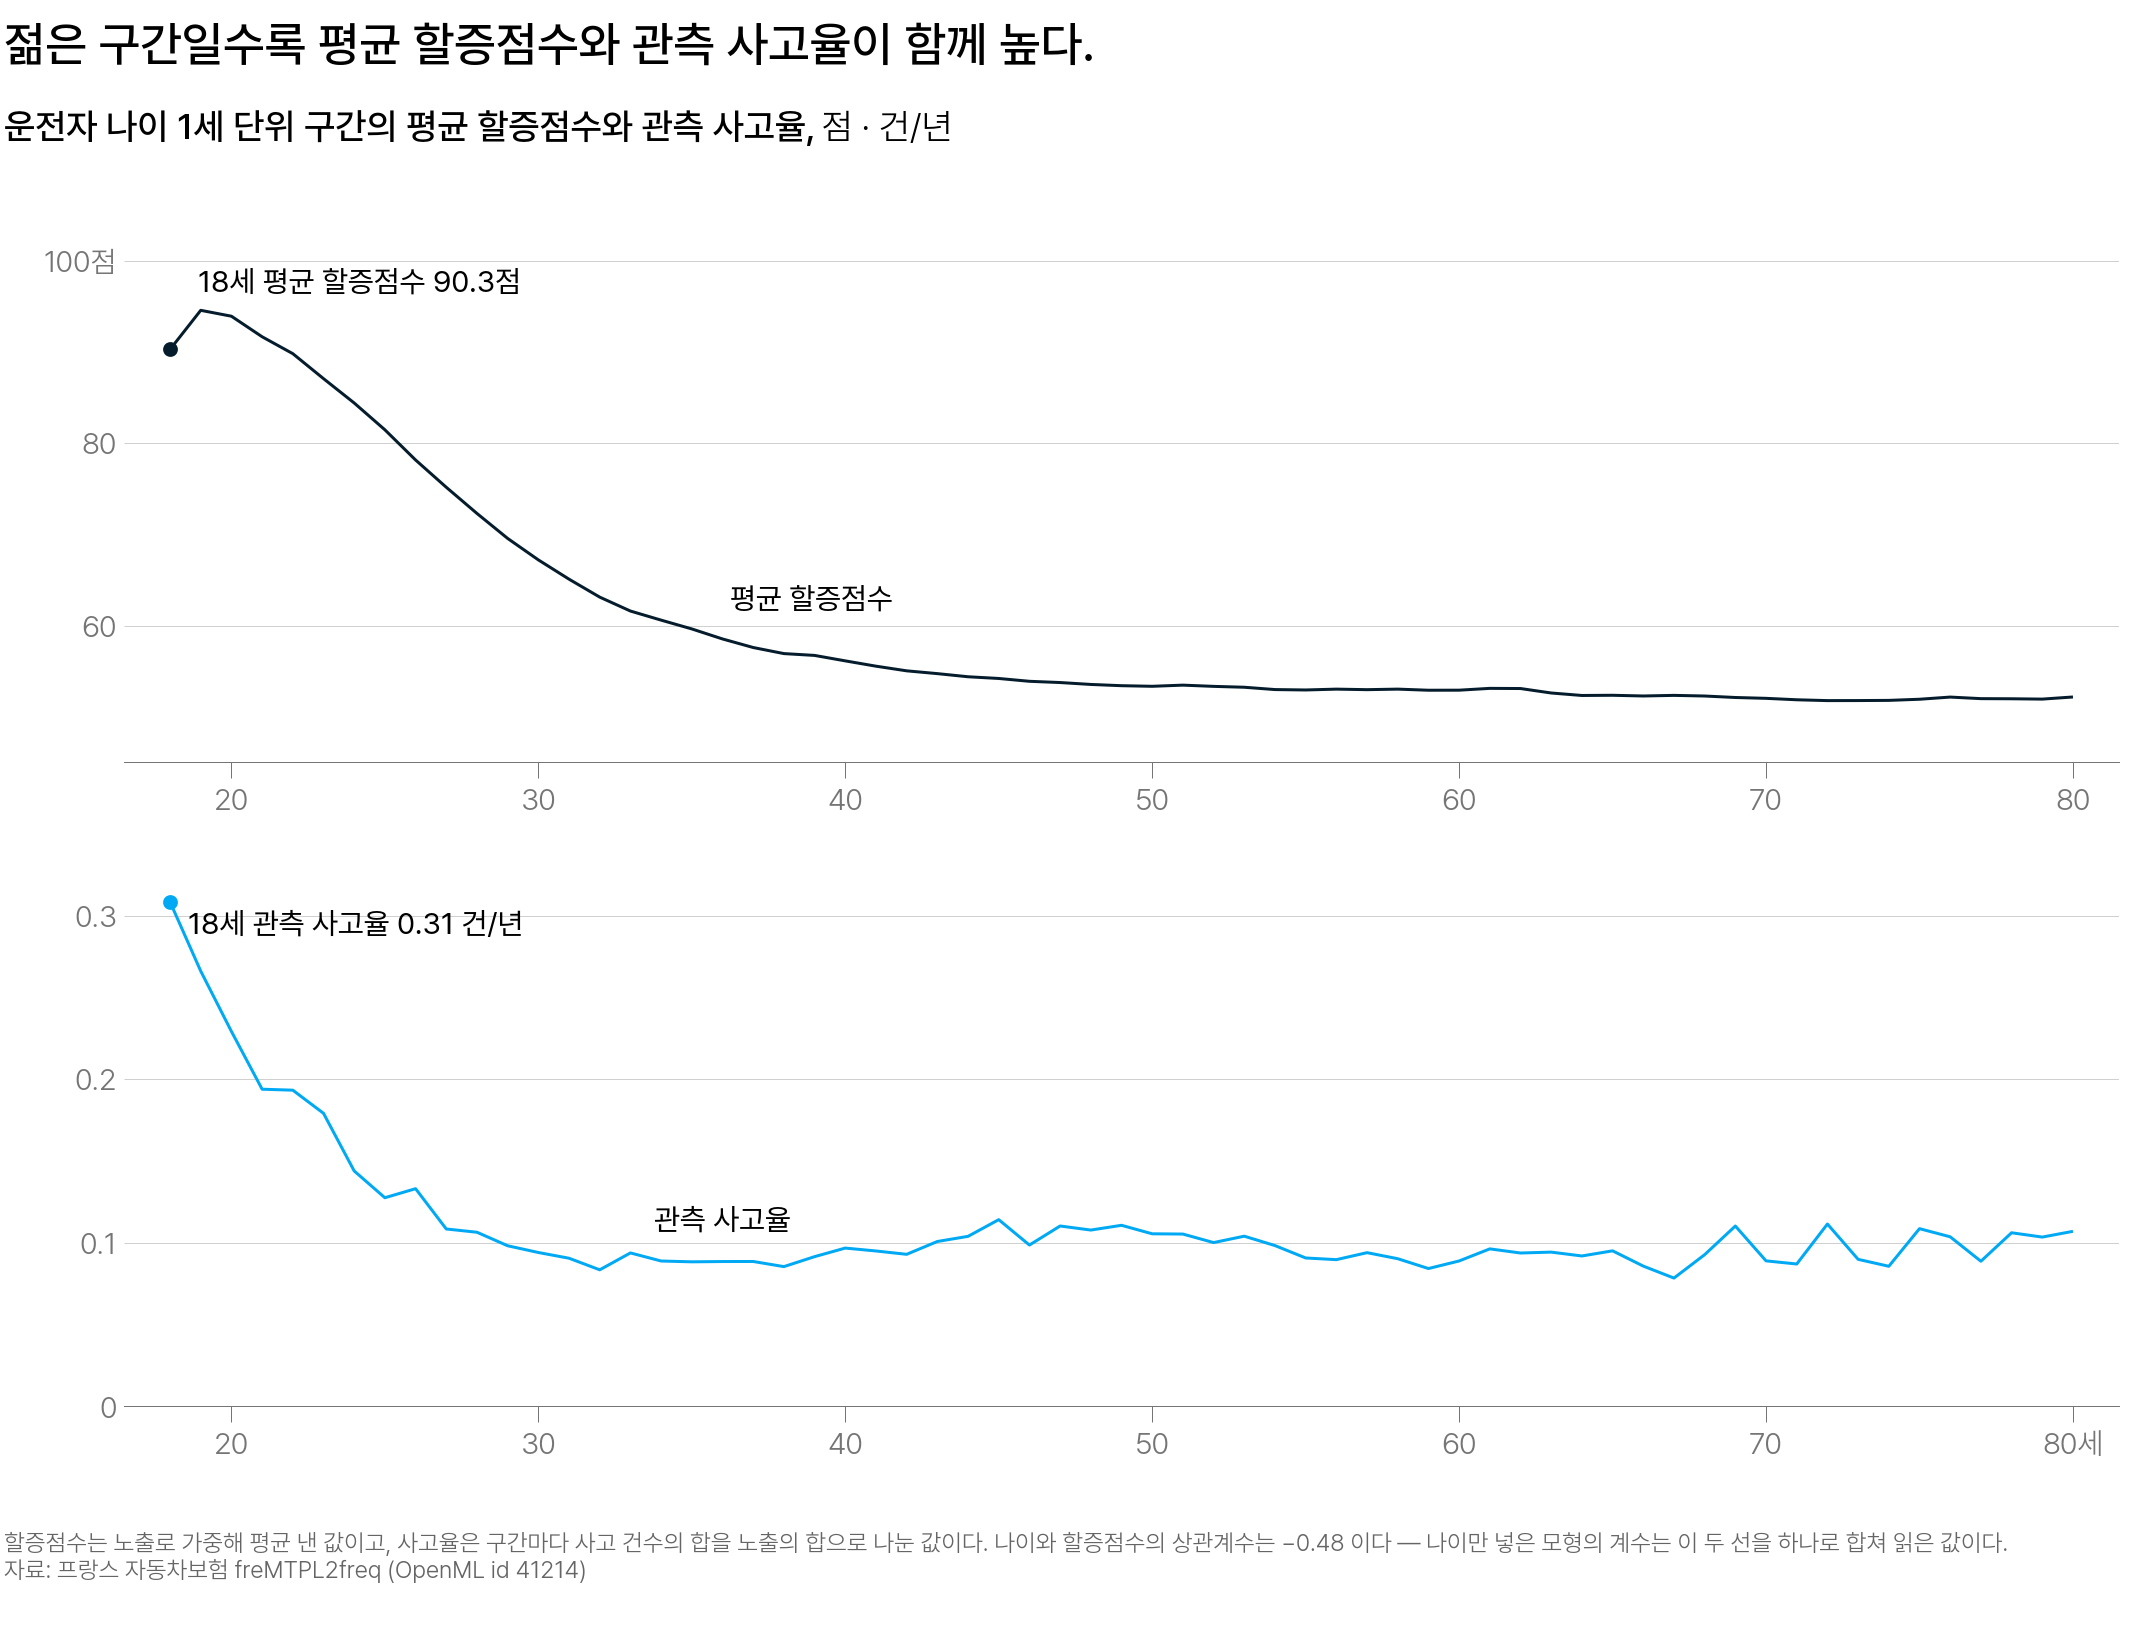

In [ ]:
# 도해 생성 코드는 LMS 에서만 실행됩니다

<p align="center"><em>▲ 나이 1세 구간의 평균 할증점수(남색)와 관측 사고율(하늘색) — 두 선이 왼쪽 끝에서 나란히 높고 오른쪽으로 가면서 나란히 감소한다</em></p>

두 선의 형태가 거의 같습니다. 평균 할증점수는 18세 구간 **90.3점**에서 40세 구간 **56.1점**으로, 같은 구간의 관측 사고율은 0.31에서 0.10으로 감소합니다. 나이와 할증점수의 상관계수가 **−0.48** 입니다 — 젊을수록 할증점수가 높습니다(사고 이력이 점수에 누적되기 때문입니다).

**보정된(adjusted) 효과** — 함께 넣은 다른 변수를 고정한 채 읽는 효과입니다. GLM 계수는 전부 이 보정된 효과라, 남은 나이 배율 1.074 를 정확히 쓰면 "**할증점수가 같은 두 계약을 비교하면** 나이 10년 많은 쪽의 사고율이 7% 높다" 가 됩니다.

같은 교란을 수치로도 확인해 둡니다. 아래는 실행 버튼이 없는 코드이고, 실습에서는 `insurance` 를 `df` 로만 바꾸면 됩니다(전처리 2개 행도 실습 쪽과 같습니다).

In [ ]:
# 나이만 넣은 모형과 할증점수를 함께 넣은 모형을 나란히 적합해 본다
import numpy as np
import statsmodels.api as sm
import statsmodels.formula.api as smf

off = np.log(insurance["Exposure"])                       # 로그 노출 = 오프셋
core = smf.glm("ClaimNb ~ DrivAge + BonusMalus + Area + VehGas", data=insurance,
               family=sm.families.Poisson(), offset=off).fit()      # 핵심 모형
age_only = smf.glm("ClaimNb ~ DrivAge", data=insurance,
                   family=sm.families.Poisson(), offset=off).fit()  # 나이만 넣은 모형

print(f"나이만 넣은 모형: exp(10b) = {np.exp(10 * age_only.params['DrivAge']):.3f}")
print(f"할증점수와 함께: exp(10b) = {np.exp(10 * core.params['DrivAge']):.3f}")
print(f"나이와 할증점수의 상관 = {insurance['DrivAge'].corr(insurance['BonusMalus']):.2f}")
for lo, hi in [(18, 21), (31, 40)]:
    seg = insurance[insurance["DrivAge"].between(lo, hi)]
    print(f"{lo}~{hi}세 관측 사고율 = {seg['ClaimNb'].sum() / seg['Exposure'].sum():.3f} 건/년")

for a in (18, 19, 20):                                    # 젊은 구간 3개의 할증점수 분포
    g = insurance[insurance["DrivAge"] == a]
    w, bm = g["Exposure"], g["BonusMalus"]
    print(f"{a}세 할증점수: 100점 정확히 {w[bm == 100].sum() / w.sum():.1%}, "
          f"100점 아래 {w[bm < 100].sum() / w.sum():.1%}"
          f"(평균 {(bm[bm < 100] * w[bm < 100]).sum() / w[bm < 100].sum():.1f}점), "
          f"하한 50점 {w[bm == 50].sum() / w.sum():.1%}, "
          f"100점 초과 {w[bm > 100].sum() / w.sum():.1%}")
# 나이만 넣은 모형: exp(10b) = 0.954      · 할증점수와 함께: exp(10b) = 1.074
# 나이와 할증점수의 상관 = -0.48
# 18~21세 관측 사고율 = 0.226 건/년       · 31~40세 관측 사고율 = 0.090 건/년
# 18세 할증점수: 100점 정확히 50.1%, 100점 아래 47.1%(평균 78.0점), 하한 50점 14.9%, 100점 초과 2.8%
# 19세 할증점수: 100점 정확히 39.0%, 100점 아래 54.5%(평균 87.3점), 하한 50점 6.2%, 100점 초과 6.5%
# 20세 할증점수: 100점 정확히 23.3%, 100점 아래 66.4%(평균 87.5점), 하한 50점 5.1%, 100점 초과 10.3%

#### 결과 해석

첫 행과 둘째 행이 같은 데이터에서 달라진 두 값 **0.954** 와 **1.074** 이고, 셋째 행의 **−0.48** 이 그 차이를 만든 교란입니다. 넷째·다섯째 행은 18～21세의 관측 사고율 0.226 건/년이 31～40세의 0.090 건/년보다 2배 넘게 높다는 뜻입니다. 마지막 3개 행은 18·19·20세 구간의 할증점수 분포입니다.

## 모형이 18세를 얼마나 못 맞히나

교란을 걷어 내도 남는 문제가 하나 더 있습니다. 같은 나이 구간에 핵심 모형의 예측을 겹쳐 그리면 왼쪽 끝이 벌어집니다.

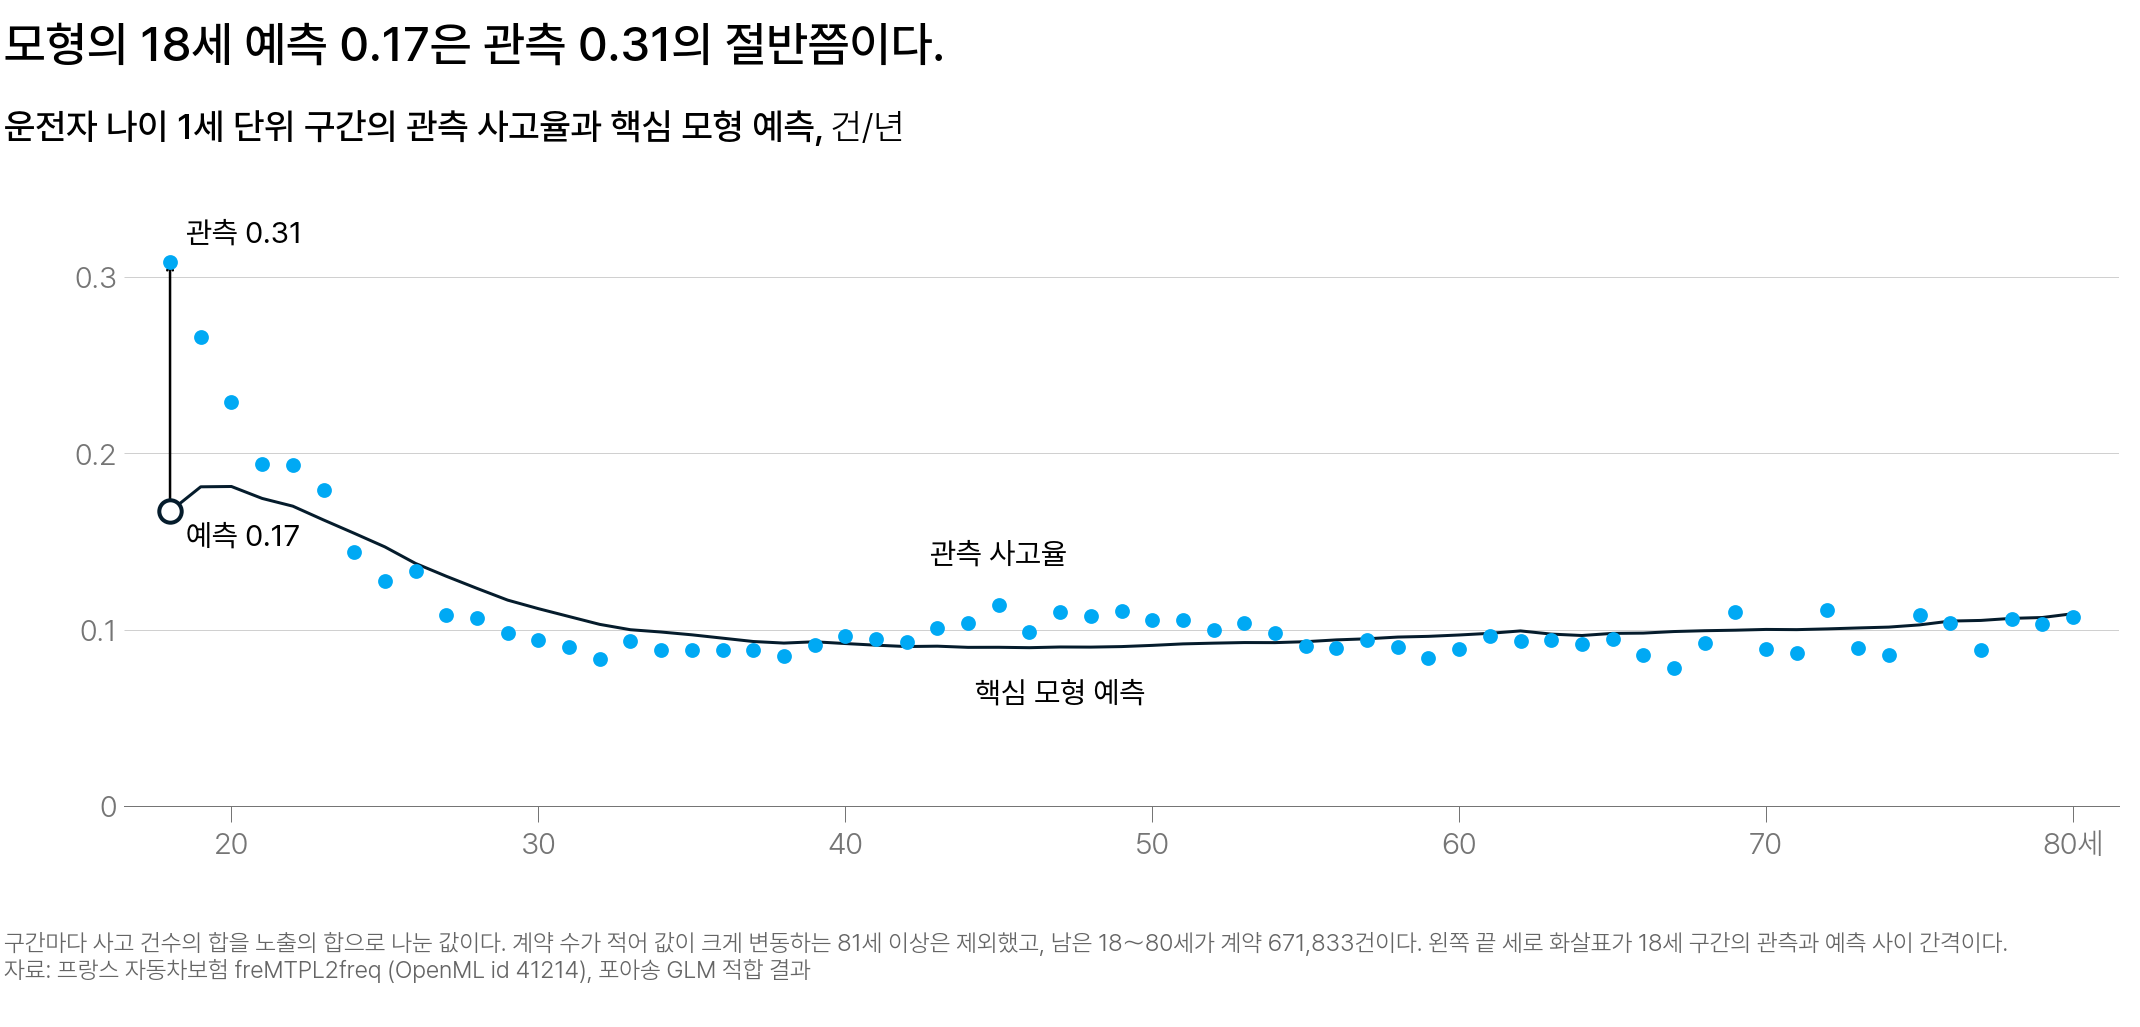

In [ ]:
# 도해 생성 코드는 LMS 에서만 실행됩니다

<p align="center"><em>▲ 운전자 나이 1세 단위 구간의 관측 사고율(하늘색 점)과 핵심 모형의 예측(남색 선) — 관측은 18세 0.31에서 30세 0.09로 급격히 감소한 뒤 평평해지는 L자 형태인데, 모형은 그 왼쪽 끝을 0.17로 추정해 화살표 길이만큼 낮게 잡는다</em></p>

관측이 가장 높은 18세 구간을 모형이 가장 낮게 잡습니다 — 관측 0.31 대 예측 0.17, 간격 $0.31 - 0.17 = 0.14$ 로 63개 구간 가운데 가장 큽니다. 직선 하나로는 이 급한 초반 감소를 표현할 수 없다는 뜻이고, 이것이 나이를 직선으로 넣은 **직선의 한계**입니다.

이상한 점이 하나 더 있습니다. 나이 배율은 10년당 1.074배로 커지는 값인데 남색 선은 18세에서 40세까지 0.17 에서 0.09 로 내려갑니다. 선이 그리는 것이 나이 항 하나가 아니라 그 구간에 실제로 속한 계약들의 평균이기 때문인데, 배율을 지수에 넣을 때는 **그 배율이 어떤 단위 하나에 대한 값인지**를 맞춥니다.

- 할증점수 — 1.0221 은 **1점당** 배율이라 점수 차 $90.3 - 56.1 = 34.2$ 가 그대로 들어가 $1.0221^{-34.2} = 0.47$배
- 나이 — 1.074 는 **10년당** 배율이라 22년을 $22 \div 10 = 2.2$ 로 바꿔 넣어 $1.074^{2.2} = 1.17$배

둘을 곱한 $0.47 \times 1.17 = 0.55$ 를 18세의 0.17건/년에 곱하면 0.09건/년, 곧 남색 선의 40세 높이입니다. 이 감소는 나이의 효과가 아니라 **젊은 구간에 할증점수 높은 계약이 몰려 있다는 사실**이 만든 선입니다.

그러니 나이 계수에는 2가지가 겹쳐 있습니다. **①** 할증점수와 교란되어 부호가 반대가 되었고, **②** L자 관계를 직선으로 표현해 젊은 층의 고위험을 반영하지 못합니다.

<details class="lms-extra"><summary>더 깊이 — 남색 선이 굽어 보이는 이유와 18세 구간의 할증점수 분포</summary>

남색 선이 직선이 아닌 것도 같은 이유입니다. 나이 항 자체는 로그 스케일에서 직선인데, 거기에 구간마다 다른 할증점수 항이 더해져 굽어 보입니다.

왼쪽 끝을 자세히 보면 남색 선이 18세 0.167에서 20세 0.181까지 잠깐 **증가했다가** 감소합니다. 앞 그림의 평균 할증점수도 18세 90.3점보다 19세 94.6점이 높았습니다. 할증점수는 100점에서 시작해 사고가 발생하면 올라가는 값인데, 18세 구간은 이제 막 면허를 취득한 계약이라 그 이력이 쌓일 시간이 없었습니다. 100점을 넘어선 계약이 18세 행에서는 노출 기준 2.8%뿐이고 19세 행은 6.5%, 20세 행은 10.3% 입니다.

18세 구간의 평균을 끌어내린 것은 하한 50점에 해당하는 14.9% 입니다. 할증점수는 운전자가 아니라 **계약**에 매겨지는 값이라, 점수가 이미 낮은 계약에 젊은 운전자가 추가된 경우로 봅니다.

</details>

②는 고칠 수 있습니다. 나이를 8개 구간(18～20 · 21～25 · … · 71세 이상)으로 나눠 한 구간에 든 계약을 모두 같은 값으로 보는 **구간 더미**로 넣는 방법입니다 — 앞에서 정의한 더미 변수를 나이 구간마다 만드는 것입니다. 그러면 18세 구간의 예측이 0.17 에서 **0.23** 으로 증가하고, AIC 도 핵심 모형의 288,149.8 에서 **287,793.3** 으로 356.5 감소합니다(둘 다 계약 678,013건 전체로 계산한 값). 적합 부족이 368.5 줄고, 계수가 9개에서 15개로 늘어 패널티 항이 12 커진 결과입니다.

반면 ①은 이렇게 고쳐도 그대로 남습니다. 나이를 어떤 형태로 넣든 할증점수를 함께 둔 이상 나이 구간의 계수는 "할증점수가 같은 계약끼리의 비교"입니다.

아래 코드가 그 값 2개를 직접 계산합니다.

In [ ]:
# 나이를 8개 구간으로 나눠 구간 더미로 다시 적합한다
import pandas as pd

bins = [0, 20, 25, 30, 40, 50, 60, 70, 200]       # 18~20 · 21~25 · 26~30 · 31~40 · 41~50 · 51~60 · 61~70 · 71세 이상
insurance["ageb"] = pd.cut(insurance["DrivAge"], bins=bins).astype(str)
binned = smf.glm("ClaimNb ~ ageb + BonusMalus + Area + VehGas", data=insurance,
                 family=sm.families.Poisson(), offset=off).fit()

print(f"구간 더미 모형: k = {int(binned.df_model + 1)}, AIC = {binned.aic:,.1f}")

b18 = insurance["DrivAge"] == 18                            # 18세 구간만 고른다
print(f"구간 더미의 18세 예측 = "
      f"{binned.fittedvalues[b18].sum() / insurance.loc[b18, 'Exposure'].sum():.3f} 건/년")

seg = insurance[insurance["DrivAge"].between(18, 20)]       # 한 구간으로 묶인 연령 3개
print(f"18~20세 관측 사고율 = {seg['ClaimNb'].sum() / seg['Exposure'].sum():.2f} 건/년")
# 구간 더미 모형: k = 15, AIC = 287,793.3
# 구간 더미의 18세 예측 = 0.233 건/년
# 18~20세 관측 사고율 = 0.25 건/년

#### 결과 해석

첫 행이 본문의 AIC 287,793.3 이고 계수는 15개, 둘째 행의 0.233 이 18세 구간 예측 0.23 입니다.

그래도 관측 0.31 에는 못 미칩니다 — 18～20세를 한 구간으로 묶었고, 셋째 행의 0.25 가 그 연령 3개를 합친 관측 사고율이라 한 구간을 한 값으로 보는 이상 예측은 그 값 부근에서 멈춥니다. 구간을 더 잘게 나눌수록 관측에 가까워지지만 그만큼 패널티 항이 커집니다.

#### 핵심 주의점

나이만 넣은 모형의 배율 0.954 를 요율표 나이 항목에 그대로 올리면 안 됩니다.

0.954 에는 "젊다" 에 섞여 있던 할증점수의 위험까지 들어 있어서, 그 값을 나이 항목에 올리면 할증점수 항목이 이미 청구한 위험을 한 번 더 청구하게 됩니다.

> **계수가 말하는 것은 "그 변수의 효과"가 아니라 "함께 넣은 변수를 고정했을 때 남는 효과"라, 나이의 효과라 부를 수 있는 값은 할증점수를 고정한 뒤 남는 1.074배다.**

다만 요율표 나이 항목에 실제로 적을 값은 이 직선 배율이 아니라 바로 위에서 계산한 구간별 배율입니다.

> **[문제] 요율표의 나이 항목 — 이중 청구를 피하는 배율 선택**
>
> 앞 그림에서 노출로 가중한 평균 할증점수는 18세 구간 90.3점, 40세 구간 56.1점이었고, 사고율비는 할증점수 1점당 1.0221 · 나이 10년당 1.074 였습니다. (1) 이 두 요인만으로 18세 계약이 40세 계약보다 사고율이 몇 배인지 구하고, (2) 그 배율을 할증점수 항과 나이 항으로 나눠 각각 몇 배인지 적은 뒤, (3) 요율표에 나이 항목과 할증점수 항목을 둘 다 두면서 같은 위험을 중복해서 청구하지 않으려면 나이 항목에 (2)의 어느 항을 올려야 하는지 한 문장으로 쓰세요.

## 7. 오늘의 정리와 수업에서 다룰 질문

## 오늘 정리 — 한 장으로

오늘 만든 모형은 전부 같은 체인 하나였습니다.

> **특성 $x$ → 점수 $\eta$ → 역링크 $g^{-1}$ → 평균 $\mu$ → 분포 → 관측 $y$**

체인에서 바꾼 것은 역링크와 분포 2개뿐이고, 나머지 단계는 모형 3개가 같습니다.

| | 선형회귀 | 로지스틱 회귀 | 포아송 회귀 |
|---|---|---|---|
| 분포 | 정규 | 이항 | 포아송 |
| 링크 $g(\mu)$ | 항등 | 로짓 | 로그 |
| 역링크 $g^{-1}(\eta)$ | $\eta$ | $\frac{1}{1+e^{-\eta}}$ | $e^{\eta}$ |
| 최종 예측 | 값 자체 | 사고를 겪을 확률 | 기대 사고 건수 |
| $e^{\beta}$ 의 뜻 | 쓰지 않는다 | 오즈비 1.018 | 사고율비 1.022 |

나머지를 5개 항목으로 줄이면 다음과 같습니다.

1. **최소제곱 직선이 맞지 않는 이유는 분산을 평균이 정하기 때문**입니다 — 이진은 $p(1-p)$, 건수 데이터는 $\mu$.
2. **로지스틱 회귀의 $e^{\beta}$ 는 오즈비**, **포아송 회귀의 $e^{\beta}$ 는 사고율비**이고, 그 곱셈 형태가 곧 요율표입니다.
3. **오프셋은 계수를 1로 고정한 항**이라 노출과 기대 건수의 비례를 유지합니다.
4. **AIC·BIC 는 적합 부족에 패널티 항을 더한 상대 점수**로, 같은 데이터 위의 후보끼리만 비교합니다.
5. **GLM 계수는 보정된 효과**라, 계수 하나를 인용할 때는 함께 고정한 변수를 밝혀 적습니다 — AIC 가 가장 작다는 것과 계수의 해석이 타당하다는 것은 다릅니다.

위 항목 가운데 2번의 두 배수가 구분되는 지점을 한 장으로 나타내면 아래 그림입니다.

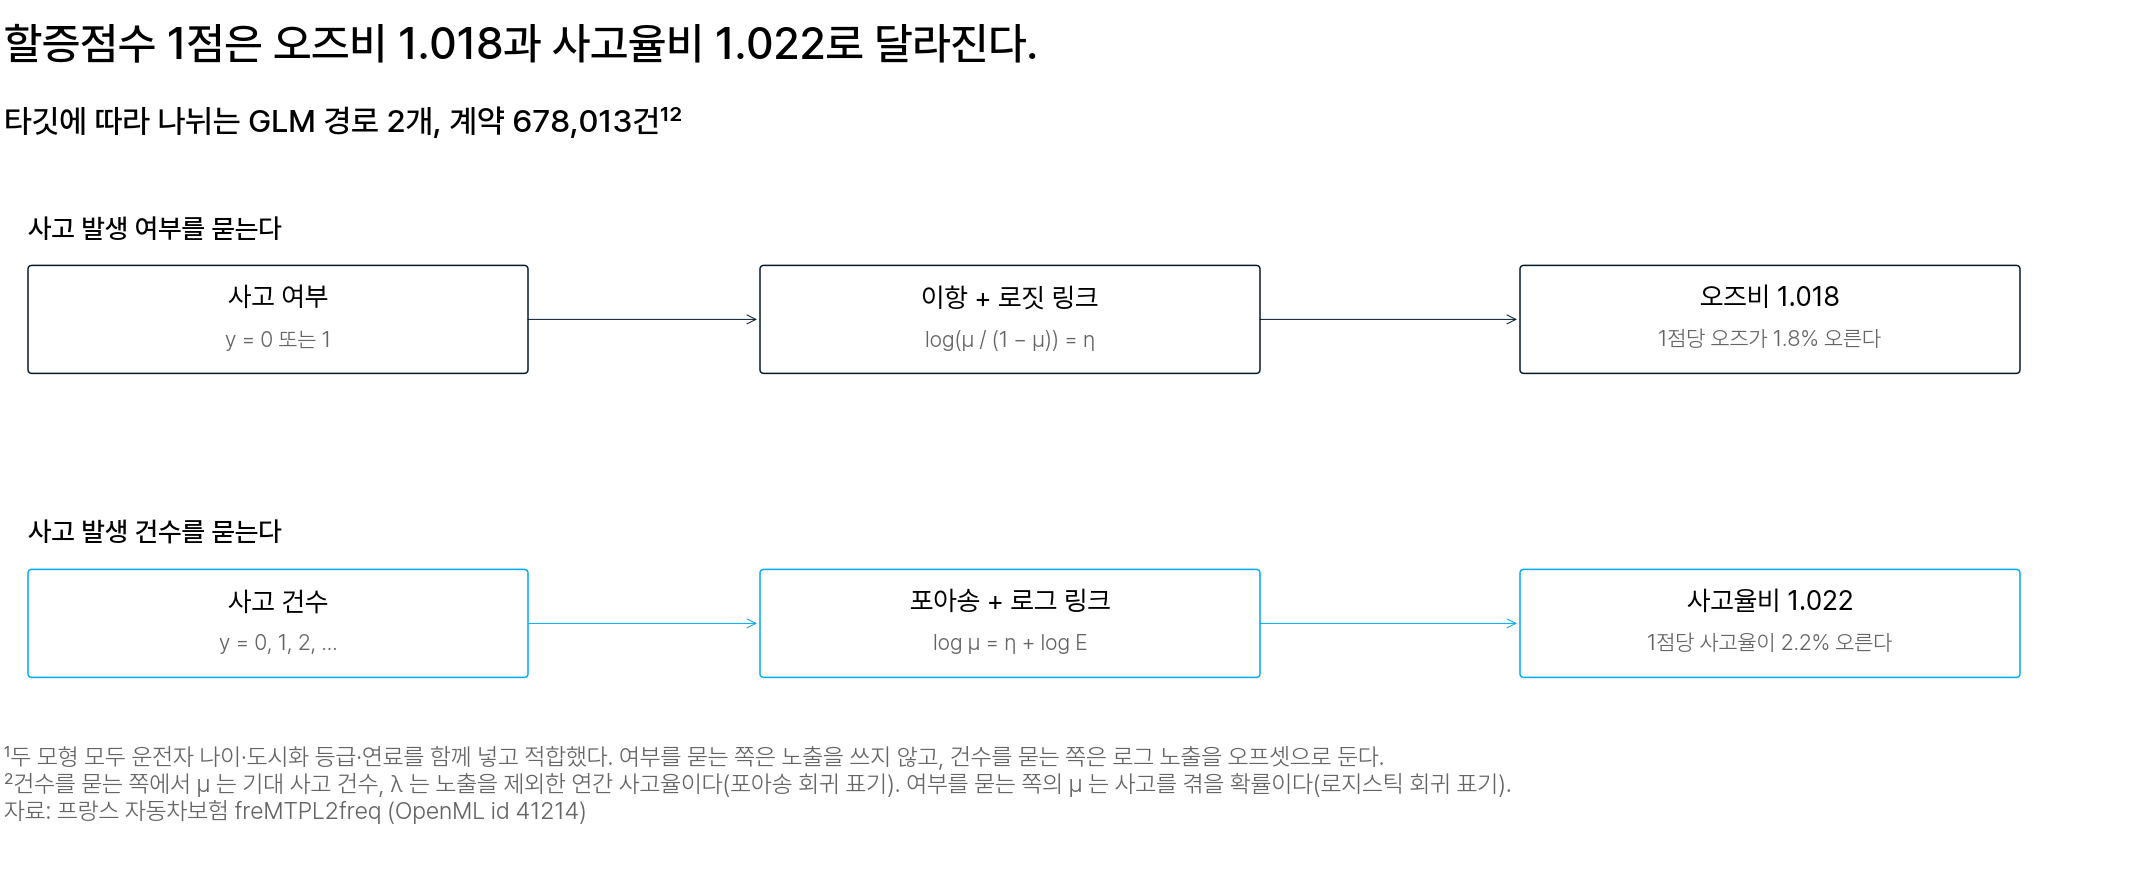

In [ ]:
# 도해 생성 코드는 LMS 에서만 실행됩니다

<p align="center"><em>▲ 타깃에 따라 나뉘는 모형 2개 — 위 남색은 이항 + 로짓으로 오즈비 1.018, 아래 하늘색은 포아송 + 로그로 사고율비 1.022. 처음 던진 질문 하나(사고 여부냐 건수냐)만 바꿨는데 분포도 링크도 계수의 뜻도 함께 달라졌다</em></p>

#### 결과 해석

같은 할증점수 1점인데 위는 **오즈**에, 아래는 **사고율**에 곱해지는 값입니다. 요율 산정이라면 아래쪽이 맞습니다 — 계약마다 다른 관찰 기간을 넣을 항이 아래에만 있기 때문입니다. 위쪽은 "1회라도 사고를 낼 고객을 선별하자" 같은 인수 심사 질문에 적합합니다.

같은 기호 $\mu$ 가 두 흐름에서 다른 것을 가리키니 함께 확인해 둡니다 — 아래는 기대 사고 **건수**, 위는 **사고를 겪을 확률** 입니다. 내일부터는 아래쪽 하나만 씁니다.

오늘의 핵심 질문이었던 「계약마다 특성에 맞춰 사고율을 따로 매길 수 있는가」의 답은 $\lambda_i = \exp(\beta_0 + \beta_1 \cdot \text{나이}_i + \cdots)$ 와 $\mu_i = E_i \lambda_i$ 이고, 도시화 등급 F면 A의 1.46배라는 그 배율들이 곧 요율표의 항목입니다.

더 읽을거리로는 Roback & Legler, *Beyond Multiple Linear Regression*(bookdown.org/roback/bookdown-BeyondMLR)의 포아송 회귀 장을 권합니다.

<div style="background:#F2F2F2;color:#000000;padding:28px;border-radius:12px;border:1px solid #E6E6E6;margin-top:18px;border-left:4px solid #051C2C">
<h2 style="color:#000000;margin:0 0 10px 0">오늘의 한 문장</h2>
<div style="font-size:1.05em">"분포와 링크를 바꾸면 같은 직선이 확률도 되고 사고율도 됩니다 — 그리고 exp(계수)는 더해지는 값이 아니라 곱해지는 배율입니다."</div>
</div>

내일은 앞에서 함께 적은 **신뢰구간**을 다시 계산합니다. 1.46배의 신뢰구간 1.37～1.55 는 "분산 = 평균" 이라는 포아송의 약속 위에서 나온 값이라, 실제 산포가 그보다 크면 구간이 더 넓어져야 하기 때문입니다.

## 수업에서 다룰 질문

정답이 정해져 있지 않은 문항을 하나 남겨 둡니다. 혼자 입장을 정한 뒤 수업에서 근거를 비교해 팀 답 하나로 모읍니다. 토론에 필요한 값 하나는 아래 코드가 계산합니다.

In [ ]:
vc = insurance["Region"].value_counts()      # 지역 22개 수준의 계약 수
thin = vc.index[-1]                          # 계약이 가장 적은 지역
hit = int((insurance.loc[insurance["Region"] == thin, "ClaimNb"] > 0).sum())
print(f"계약이 가장 적은 지역 {thin}: 계약 {vc.iloc[-1]:,}건, 사고가 난 계약 {hit}건")

확장 모형의 지역 더미 하나를 뒷받침하는 데이터가 R43 에서는 계약 1,326건, 사고가 난 계약 54건뿐입니다. 데이터 전체가 충분하다는 말이 지역마다 충분하다는 말은 아닙니다.

> **[문제] 팀 라운드 — 요율표에 어느 모형을 올릴 것인가**
>
> 앞에서 모형 3개를 비교했습니다. 계약 2,000건에서는 AIC 가 가장 작은 것이 핵심 모형 752.7 이었지만 null 753.0 과의 차이가 0.3 이라 둘은 구분되지 않았고, 확장 모형만 ΔAIC 11.1 로 후보에서 제외되었습니다. 그런데 계약 678,013건 전체에서는 그 확장 모형이 AIC 287,272.8 로 가장 작습니다. 확장 모형은 지역 22개와 차량 브랜드 11개를 전부 더미로 펼쳐 계수가 41개입니다. 그런데 앞에서 확인했듯 핵심 모형의 운전자 나이 계수는 할증점수와 교란되어 부호가 반대이고(나이만 넣으면 0.954배, 할증점수를 함께 넣으면 1.074배), L자 관계를 직선 하나로 표현해 젊은 운전자의 고위험도 반영하지 못합니다. 확장 모형도 나이와 할증점수를 같은 방식으로 넣었으니 그 결함은 그대로입니다. 다음 주 요율 회의에 표를 하나 들고 가야 하는데 팀 의견이 3가지로 나뉘었습니다.
> 
> - **관점 A — AIC가 고른 확장 모형을 쓰자.** 데이터가 678,013건이나 되니 계수 41개는 충분히 감당된다. 지역과 브랜드는 실제로 위험이 다른 요인이고, 그걸 빼면 그 정보가 전부 버려진다. 모형 선택의 기준을 정해 놓았으면 그 기준이 고른 것을 써야지, 결과가 마음에 들지 않는다고 번복하면 기준을 정한 의미가 없다.
> - **관점 B — 특성 4개만 둔 핵심 모형을 쓰자.** 요율표는 규제 당국과 고객에게 설명해야 하는 문서다. 계수 41개인 표는 "왜 이 지역이 저 지역보다 비싼가"에 답하기 어렵고, 방금 계산한 대로 지역 22개 중 계약이 가장 적은 지역은 1,326건뿐이라 계수가 표본에 따라 크게 달라진다. AIC 차이 877점은 큰 값이지만, 그건 예측 오차의 감소이지 설명 가능성이나 안정성을 측정한 값이 아니다.
> - **관점 C — 지금은 어느 쪽도 올리지 말고 나이 항부터 고치자.** 두 모형 모두 나이를 직선 하나로 넣어 20대 초반의 고위험을 반영하지 못하니, 그대로 올리면 젊은 층에 할인을 주는 표가 나온다. 나이를 8개 구간 더미로 나눠 계산하니 AIC 가 287,793.3 으로 356.5점 감소했지만, 그래도 확장 모형의 287,272.8 에는 520.5점 못 미쳤다. 그러니 구간을 더 잘게 나누든, 나이와 할증점수가 교란된 부분(상관 −0.48)을 요율표에서 어느 쪽 계수로 청구할지 정하든, 나이 항부터 고친 뒤에 AIC 를 다시 계산하는 것이 순서다. 그 사이에는 기존 요율표를 유지하면 된다.
> 
> 자기 입장 하나와 근거 3개, 그리고 확신도를 정해 오세요.